In [1]:
import sys
import ast
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd 
import matplotlib.pyplot as plt
import IPython
import numpy as np 
from dwarf_plotting import plot_lg_virgo, plot_lg_vd, plot_lg_virgo_some
# from Pradyumna_plot import plot_tng_subhalos #This is to plot the subhalos from TNG
import matplotlib
import illustris_python as il
from populating_stars import *
from subhalo_profiles import NFWProfile
from colossus.cosmology import cosmology
from colossus.halo import concentration
from plot_sachi import plot_sachi
from scipy.optimize import fsolve
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.collections as mc
from matplotlib.legend_handler import HandlerTuple
from testing_errani import get_rot_curve, get_rmxbyrmx0, get_vmxbyvmx0, get_mxbymx0, get_LbyL0, l10rbyrmx0_1by4_spl,l10rbyrmx0_1by2_spl, l10rbyrmx0_1by8_spl, l10rbyrmx0_1by16_spl, l10vbyvmx0_1by2_spl, l10vbyvmx0_1by4_spl, l10vbyvmx0_1by8_spl, l10vbyvmx0_1by16_spl, l10rbyrmx0_1by66_spl, l10rbyrmx0_1by250_spl, l10rbyrmx0_1by1000_spl, l10vbyvmx0_1by66_spl, l10vbyvmx0_1by250_spl, l10vbyvmx0_1by1000_spl
import matplotlib.ticker as ticker
from errani_plus_tng_subhalo import Subhalo
import re

/bigdata/saleslab/psadh003/tng50/dwarf_formation/dwarf_plotting.py:55: RuntimeWarning: invalid value encountered in sqrt
  rh_proj *= np.sqrt(1.-ell)


A new version of galpy (1.10.1) is available, please upgrade using pip/conda/... to get the latest features and bug fixes!


In [2]:
cosmology.setCosmology('planck18')

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size' : 14}

plt.figure()
plt.close()
matplotlib.rc('font', **font)

In [3]:
label_font = 20

In [4]:
import illustris_python as il

def convert_to_float(value):
    try:
        if isinstance(value, float) or isinstance(value, int):
            return value

        if value == '[inf, inf, inf]' or value == '[inf inf inf]':
            return np.array([np.inf, np.inf, np.inf])

        if value == '[inf]':
            return np.inf

        if value == '[-inf]':
            return -np.inf

        

        blah = ast.literal_eval(value)
        if isinstance(blah, list):
            if len(blah) == 1:
                blah2 = float(blah[0])   
            elif len(blah) == 3:
                blah2 = np.array([float(blah[0]), float(blah[1]), float(blah[2])])
        else:
            blah2 = float(blah)        
        return blah2
    except Exception as e:
        try:
            value_fixed = re.sub(r'(?<=\d)\s+(?=-?\d)', ', ', value)  # Handle spaces between numbers
            value_fixed = re.sub(r'(?<=\d)\s+(?=\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=-\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=\d)', ', ', value_fixed)
            # Now use ast.literal_eval
            # print(value_fixed)
            result = ast.literal_eval(value_fixed)
            return result
        except Exception as e:
            print(value)
            return value
    # except ValueError:
    #     return value


def get_med_values(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.median(np.reshape(arr, (cuts, -1)), axis = 0)

def get_quantiles(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.quantile(np.reshape(arr, (cuts, -1)), axis = 0, q = [0.05, 0.95])


basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'
outpath  = '/rhome/psadh003/bigdata/tng50/output_files/'
plotpath = '/bigdata/saleslab/psadh003/tng50/output_plots/'
misc_path = '/bigdata/saleslab/psadh003/misc_files/'
ferrarese_data_path = '/bigdata/saleslab/psadh003/misc_files/Ferrarese_virgo_smf.csv'
venhola_data_path = '/bigdata/saleslab/psadh003/misc_files/Venhola_fornax_smf.csv'

'''
This part is to plot the NGVS data of virgo core set of satellites
'''
fdata = pd.read_csv(ferrarese_data_path, delimiter = ',')
fmstar = fdata['mstar']
fngal = fdata['ngal']
fngal_cum = np.cumsum(fngal)

'''
This part is to plot the Fornax mass function (everything inside virial radius)
'''
vdata = pd.read_csv(venhola_data_path, delimiter = ',')
vmstar = vdata['mstar']
vngal = vdata['ngal']
vngal_cum = np.cumsum(vngal)



fof_no = 210
fof_str = 'fof210'

this_fof0 = il.groupcat.loadSingle(basePath, 99, haloID = 0)
central_sfid_99_0 = this_fof0['GroupFirstSub']
rvir_fof0 = this_fof0['Group_R_Crit200']/0.6744
mvir_fof0 = this_fof0['Group_M_Crit200']*1e10/0.6744

this_fof1 = il.groupcat.loadSingle(basePath, 99, haloID = 1)
central_sfid_99_1 = this_fof1['GroupFirstSub']
rvir_fof1 = this_fof1['Group_R_Crit200']/0.6744
mvir_fof1 = this_fof1['Group_M_Crit200']*1e10/0.6744

this_fof2 = il.groupcat.loadSingle(basePath, 99, haloID = 2)
central_sfid_99_2 = this_fof2['GroupFirstSub']
rvir_fof2 = this_fof2['Group_R_Crit200']/0.6744
mvir_fof2 = this_fof2['Group_M_Crit200']*1e10/0.6744

this_fof_plotppath = '/bigdata/saleslab/psadh003/tng50/final_plots/' + fof_str + '/'
if not os.path.exists(this_fof_plotppath): #If the directory does not exist, then just create it!
    os.makedirs(this_fof_plotppath)



'''
In the following lines, 
(i) ps stands for power law values of surviving subhalos
(ii) pm stands for power law values of merged subhalos
(iii) cs stands for cutoff values of surviving subhalos
(iv) cm stands for cutoff values of merged subhalos
'''

mcutoff = 1e2


if True: #This is a section for getting power law values of survived subhalos
    pdfs = pd.read_csv(outpath + fof_str + '_surviving_evolved_everything.csv', delimiter = ',', low_memory=False)
    pdfs = pdfs.applymap(convert_to_float)


    # subset1 = pdfs[(pdfs['dist_f_ar']<rvir_fof0) & (pdfs['fof'] == 0)]
    # subset2 = pdfs[(pdfs['dist_f_ar']<rvir_fof1) & (pdfs['fof'] == 1)]
    # subset3 = pdfs[(pdfs['dist_f_ar']<rvir_fof2) & (pdfs['fof'] == 2)]

    # pdfs = pd.concat([subset1, subset2, subset3], axis=0)
    pdfs1 = pdfs
    # if porc == 'p':
        # print(len(pdfs[pdfs['mstar_f_ar_tng'].values>5e6]))
    columns_to_max = ['mstar_max_ar', 'mstar_max_pl_ar']
    max_values = pdfs[columns_to_max].max(axis=1)
    pdfs = pdfs[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar_tng', 'mstar_f_pl_ar']
    max_values = pdfs[columns_to_max].max(axis=1)
    cutoff = 10

    pdfs = pdfs[(max_values > cutoff)]
    # pdfs = pdfs[pdfs[]]


    psdist_f_ar = pdfs['dist_f_ar'].values
    pspos_f_ar = np.stack(np.array(pdfs['pos_f_ar'].values))
    psvel_f_ar = np.stack(np.array(pdfs['vel_f_ar'].values))

    pspos_if_ar = np.stack(np.array(pdfs['pos_if_ar'].values))
    psdist_if_ar = np.linalg.norm(pspos_if_ar, axis = 1)
    psvel_if_ar = np.stack(np.array(pdfs['vel_if_ar'].values))
    # print(pspos_f_ar)
    # print(pspos_f_ar.shape)
    psxydist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, :2]), axis = 1))
    psyzdist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, 1:]), axis = 1))
    psxzdist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, [0, 2]]), axis = 1))


    psvd_f_ar_tng = pdfs['vd_f_ar_tng'].values
    psrh_f_ar_tng = pdfs['rh_f_ar_tng'].values
    psmstar_f_ar_tng = pdfs['mstar_f_ar_tng'].values
    psmmx_f_ar_tng = pdfs['mmx_f_ar_tng'].values
    psrmx_f_ar_tng = pdfs['rmx_f_ar_tng'].values
    psvmx_f_ar_tng = pdfs['vmx_f_ar_tng'].values

    pstinf_ar = pdfs['tinf_ar'].values
    pstorb_ar = pdfs['torb_ar'].values
    psrapo_ar = pdfs['rapo_ar'].values
    psrperi_ar = pdfs['rperi_ar'].values

    psvd_f_ar = pdfs['vd_f_ar'].values
    psrh_f_ar = pdfs['rh_f_ar'].values
    psmstar_f_ar = pdfs['mstar_f_ar'].values

    psvd_max_ar = pdfs['vd_max_ar'].values
    psrh_max_ar = pdfs['rh_max_ar'].values
    psmstar_max_ar = pdfs['mstar_max_ar'].values

    pssnap_if_ar = pdfs['snap_if_ar'].values
    pssf_id_if_ar = pdfs['sfid_if_ar'].values

    psmmx_f_ar = pdfs['mmx_f_ar'].values
    psrmx_f_ar = pdfs['rmx_f_ar'].values
    psvmx_f_ar = pdfs['vmx_f_ar'].values

    psmmx_if_ar = pdfs['mmx_if_ar'].values
    psrmx_if_ar = pdfs['rmx_if_ar'].values
    psvmx_if_ar = pdfs['vmx_if_ar'].values

    psvd_f_pl_ar = pdfs['vd_f_pl_ar'].values
    psrh_f_pl_ar = pdfs['rh_f_pl_ar'].values
    psmstar_f_pl_ar = pdfs['mstar_f_pl_ar'].values
    psvd_f_co_ar = pdfs['vd_f_co_ar'].values
    psrh_f_co_ar = pdfs['rh_f_co_ar'].values
    psmstar_f_co_ar = pdfs['mstar_f_co_ar'].values
    psrh_max_pl_ar = pdfs['rh_max_pl_ar'].values
    psrh_max_co_ar = pdfs['rh_max_co_ar'].values
    psmstar_max_pl_ar = pdfs['mstar_max_pl_ar'].values
    psmstar_max_co_ar = pdfs['mstar_max_co_ar'].values
    psfof = pdfs['fof'].values
    psmstar_if_ar = pdfs['mstar_if_ar'].values
    psvmax_if_ar = pdfs['vmax_if_ar'].values
    
    psmbp_pos_f_ar = pdfs['mbp_pos_f_ar'].values
    psmbp_vel_f_ar = pdfs['mbp_vel_f_ar'].values
    psmbp_dist_f_ar = pdfs['mbp_dist_f_ar'].values
    psgr_sat = pdfs['grp_status'].values

    pspot_f_ar = pdfs['pot_f_ar'].values
    pspot_if_ar = pdfs['pot_if_ar'].values
    psmpeak_ar = pdfs['mpeak_ar'].values
    psmdm_f_ar = pdfs['mdm_f_ar'].values
    

    

    psmstar_all = np.zeros(len(psmmx_f_ar))
    psrh_all = np.zeros(len(psmmx_f_ar))
    psvd_all = np.zeros(len(psmmx_f_ar))
    res_ixs = np.where(psmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(psmstar_max_ar < 5e6)[0] #These are the unresolved indices

    psmstar_max_all = np.zeros(len(psmmx_f_ar))
    psrh_max_all = np.zeros(len(psmmx_f_ar))

    psmstar_max_all[res_ixs] = psmstar_max_ar[res_ixs]
    psmstar_max_all[unres_ixs] = psmstar_max_pl_ar[unres_ixs]

    psrh_max_all[res_ixs] = psrh_max_ar[res_ixs]
    psrh_max_all[unres_ixs] = psrh_max_pl_ar[unres_ixs]

    psmstar_all[res_ixs] = psmstar_f_ar[res_ixs]
    psmstar_all[unres_ixs] = psmstar_f_pl_ar[unres_ixs]
    psrh_all[res_ixs] = psrh_f_ar[res_ixs]
    psrh_all[unres_ixs] = psrh_f_pl_ar[unres_ixs]
    psvd_all[res_ixs] = psvd_f_ar[res_ixs]
    psvd_all[unres_ixs] = psvd_f_pl_ar[unres_ixs]


    pssigma_all = 4.83 +21.57 -2.5 * np.log10(psmstar_all / (np.pi * (psrh_all*1e3) ** 2)) #This will be in mag/arcsec^2





if True: #This is a section for getting power law values of merged subhalos
    pdfm = pd.read_csv(outpath + fof_str + '_merged_evolved_wmbp_everything.csv', delimiter = ',')
    # print(pdfm.head(20))
    # print(f'Length before is: {len(pdfm)}')
    # pdfm = pdfm[pdfm['dist_f_ar'] != '']
    # print(f'Length after is: {len(pdfm)}')

    # pdfm = pdfm.dropna(subset = ['dist_f_ar'])
    # print(pdfm['pos_f_ar'])
    pdfm = pdfm.applymap(convert_to_float)
    # pdfm = pdfm[pdfm['dist_f_ar']<rvir_fof]

    # subset1 = pdfm[(pdfm['dist_f_ar']<rvir_fof0) & (pdfm['fof'] == 0)]
    # subset2 = pdfm[(pdfm['dist_f_ar']<rvir_fof1) & (pdfm['fof'] == 1)]
    # subset3 = pdfm[(pdfm['dist_f_ar']<rvir_fof2) & (pdfm['fof'] == 2)]

    # pdfm = pd.concat([subset1, subset2, subset3], axis=0)
    pdfm1 = pdfm 

    columns_to_max = ['mstar_max_ar', 'mstar_max_pl_ar']
    max_values = pdfm[columns_to_max].max(axis=1)
    pdfm = pdfm[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar', 'mstar_f_pl_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = pdfm[columns_to_max].max(axis=1)

    # Sample cutoff value
    cutoff = 10

    # print(len(pdfm))
    pdfm = pdfm[max_values > cutoff]
    # print(len(pdfm))

    pmdist_f_ar = pdfm['dist_f_ar'].values
    # print(pmpos_ar)
    # print(pdfm['pos_f_ar'].values)
    pmpos_list = pdfm['pos_f_ar'].values
    pmvel_list = pdfm['vel_f_ar'].values


    # pmpos_list = pdfm['pos_f_ar'].values
    # pmvel_list = pdfm['vel_f_ar'].values

    
    for idx, arr in enumerate(pmpos_list):
        if np.array(arr).size != 3:  # Check if the array is empty
            pmpos_list[idx] = [np.inf, np.inf, np.inf]
            pmvel_list[idx] = [np.inf, np.inf, np.inf]
            pmdist_f_ar[idx] = np.inf
    pmpos_ar = np.stack(np.array(pmpos_list))
    pmvel_f_ar = np.stack(np.array(pmvel_list))

    pmpos_if_ar = np.stack(np.array(pdfm['pos_if_ar'].values))
    pmdist_if_ar = np.linalg.norm(pmpos_if_ar, axis = 1)
    pmvel_if_ar = np.stack(np.array(pdfm['vel_if_ar'].values))
    # pmpos_ar
    # print(pmpos_ar)
    pmxydist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, :2]), axis = 1))
    pmyzdist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, 1:]), axis = 1))
    pmxzdist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, [0, 2]]), axis = 1))
    pmmbpid_ar = pdfm['mbpid_ar'].values

    pmtinf_ar = pdfm['tinf_ar'].values
    pmtorb_ar = pdfm['torb_ar'].values
    pmrapo_ar = pdfm['rapo_ar'].values
    pmrperi_ar = pdfm['rperi_ar'].values

    pmvd_f_ar = pdfm['vd_f_ar'].values
    pmrh_f_ar = pdfm['rh_f_ar'].values
    pmmstar_f_ar = pdfm['mstar_f_ar'].values

    pmvd_max_ar = pdfm['vd_max_ar'].values
    pmrh_max_ar = pdfm['rh_max_ar'].values
    pmmstar_max_ar = pdfm['mstar_max_ar'].values

    pmsnap_if_ar = pdfm['snap_if_ar'].values
    pmsfid_if_ar = pdfm['sfid_if_ar'].values

    pmmmx_f_ar = pdfm['mmx_f_ar'].values
    pmrmx_f_ar = pdfm['rmx_f_ar'].values
    pmvmx_f_ar = pdfm['vmx_f_ar'].values

    pmmmx_if_ar = pdfm['mmx_if_ar'].values
    pmrmx_if_ar = pdfm['rmx_if_ar'].values
    pmvmx_if_ar = pdfm['vmx_if_ar'].values

    pmvd_f_pl_ar = pdfm['vd_f_pl_ar'].values
    pmrh_f_pl_ar = pdfm['rh_f_pl_ar'].values
    pmmstar_f_pl_ar = pdfm['mstar_f_pl_ar'].values
    pmvd_f_co_ar = pdfm['vd_f_co_ar'].values
    pmrh_f_co_ar = pdfm['rh_f_co_ar'].values
    pmmstar_f_co_ar = pdfm['mstar_f_co_ar'].values
    pmrh_max_pl_ar = pdfm['rh_max_pl_ar'].values
    pmrh_max_co_ar = pdfm['rh_max_co_ar'].values
    pmmstar_max_pl_ar = pdfm['mstar_max_pl_ar'].values
    pmmstar_max_co_ar = pdfm['mstar_max_co_ar'].values
    pmpot_f_ar = pdfm['pot_f_ar'].values
    pmpot_if_ar = pdfm['pot_if_ar'].values
    pmmpeak_ar = pdfm['mpeak_ar'].values


    
    pmfof = pdfm['fof'].values

    pmgp_pos_f_ar = pdfm['gp_pos_f_ar'].values
    pmgp_vel_f_ar = pdfm['gp_vel_f_ar'].values
    pmgp_dist_f_ar = pdfm['gp_dist_f_ar'].values

    pmgr_sat = pdfm['grp_status'].values
    

    pmmstar_max_all = np.zeros(len(pmmmx_f_ar))
    pmrh_max_all = np.zeros(len(pmmmx_f_ar))

    pmmstar_all = np.zeros(len(pmmmx_f_ar))
    pmrh_all = np.zeros(len(pmmmx_f_ar))
    pmvd_all = np.zeros(len(pmmmx_f_ar))
    res_ixs = np.where(pmmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(pmmstar_max_ar < 5e6)[0] #These are the unresolved indices
    pmmstar_all[res_ixs] = pmmstar_f_ar[res_ixs]
    pmmstar_all[unres_ixs] = pmmstar_f_pl_ar[unres_ixs]

    pmmstar_max_all[res_ixs] = pmmstar_max_ar[res_ixs]
    pmmstar_max_all[unres_ixs] = pmmstar_max_pl_ar[unres_ixs]


    pmrh_max_all[res_ixs] = pmrh_max_ar[res_ixs]
    pmrh_max_all[unres_ixs] = pmrh_max_pl_ar[unres_ixs]



    pmrh_all[res_ixs] = pmrh_f_ar[res_ixs]
    pmrh_all[unres_ixs] = pmrh_f_pl_ar[unres_ixs]
    pmvd_all[res_ixs] = pmvd_f_ar[res_ixs]
    pmvd_all[unres_ixs] = pmvd_f_pl_ar[unres_ixs]

    pmsigma_all = 4.83 +21.57 -2.5 * np.log10(pmmstar_all / (np.pi * (pmrh_all*1e3) ** 2)) #This will be in mag/arcsec^2




#Once we have the power law data for surviving and merged subhalos, we should obtain their respective stellar masses etc checking if they are resolved




/tmp/ipykernel_699911/1008661612.py:238: RuntimeWarning: invalid value encountered in divide
  pssigma_all = 4.83 +21.57 -2.5 * np.log10(psmstar_all / (np.pi * (psrh_all*1e3) ** 2)) #This will be in mag/arcsec^2



In [5]:
filepath = '/rhome/psadh003/bigdata/tng50/tng_files/'
outpath  = '/rhome/psadh003/bigdata/tng50/output_files/'
baseUrl = 'https://www.tng-project.org/api/TNG50-1/'
headers = {"api-key":"894f4df036abe0cb9d83561e4b1efcf1"}
basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'
fof_path = '/bigdata/saleslab/psadh003/tng50/fof_partdata/'
misc_path = '/bigdata/saleslab/psadh003/misc_files/'\

G = 4.3e-6
h = 0.6744
this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)

central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200 = this_fof['Group_M_Crit200'] * 1e10 / h
r200 = this_fof['Group_R_Crit200'] / h
v200 = np.sqrt(G * m200 / r200)
cen['SubhaloVmax']

1093.4725

In [6]:

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 1)

central_sfid_991 = this_fof['GroupFirstSub']
cen1 = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_991)
m2001 = this_fof['Group_M_Crit200'] * 1e10 / h
r2001 = this_fof['Group_R_Crit200'] / h
v2001 = np.sqrt(G * m200 / r200)
cen1['SubhaloVmax']

903.2972

In [7]:
this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 2)

central_sfid_992 = this_fof['GroupFirstSub']
cen2 = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_992)
m2002 = this_fof['Group_M_Crit200'] * 1e10 / h
r2002 = this_fof['Group_R_Crit200'] / h
v2002 = np.sqrt(G * m200 / r200)
cen2['SubhaloVmax']

775.31226

In [8]:
pske_if_ar = 0.5*np.linalg.norm(psvel_if_ar, axis = 1)**2
pske_f_ar = 0.5*np.linalg.norm(psvel_f_ar, axis = 1)**2
pmke_f_ar = 0.5*np.linalg.norm(pmvel_f_ar, axis = 1)**2
pmke_if_ar = 0.5*np.linalg.norm(pmvel_if_ar, axis = 1)**2
pmte_f_ar = pmpot_f_ar + pmke_f_ar
pmte_if_ar = pmpot_if_ar + pmke_if_ar
pste_f_ar = pspot_f_ar + pske_f_ar
pste_if_ar = pspot_if_ar + pske_if_ar


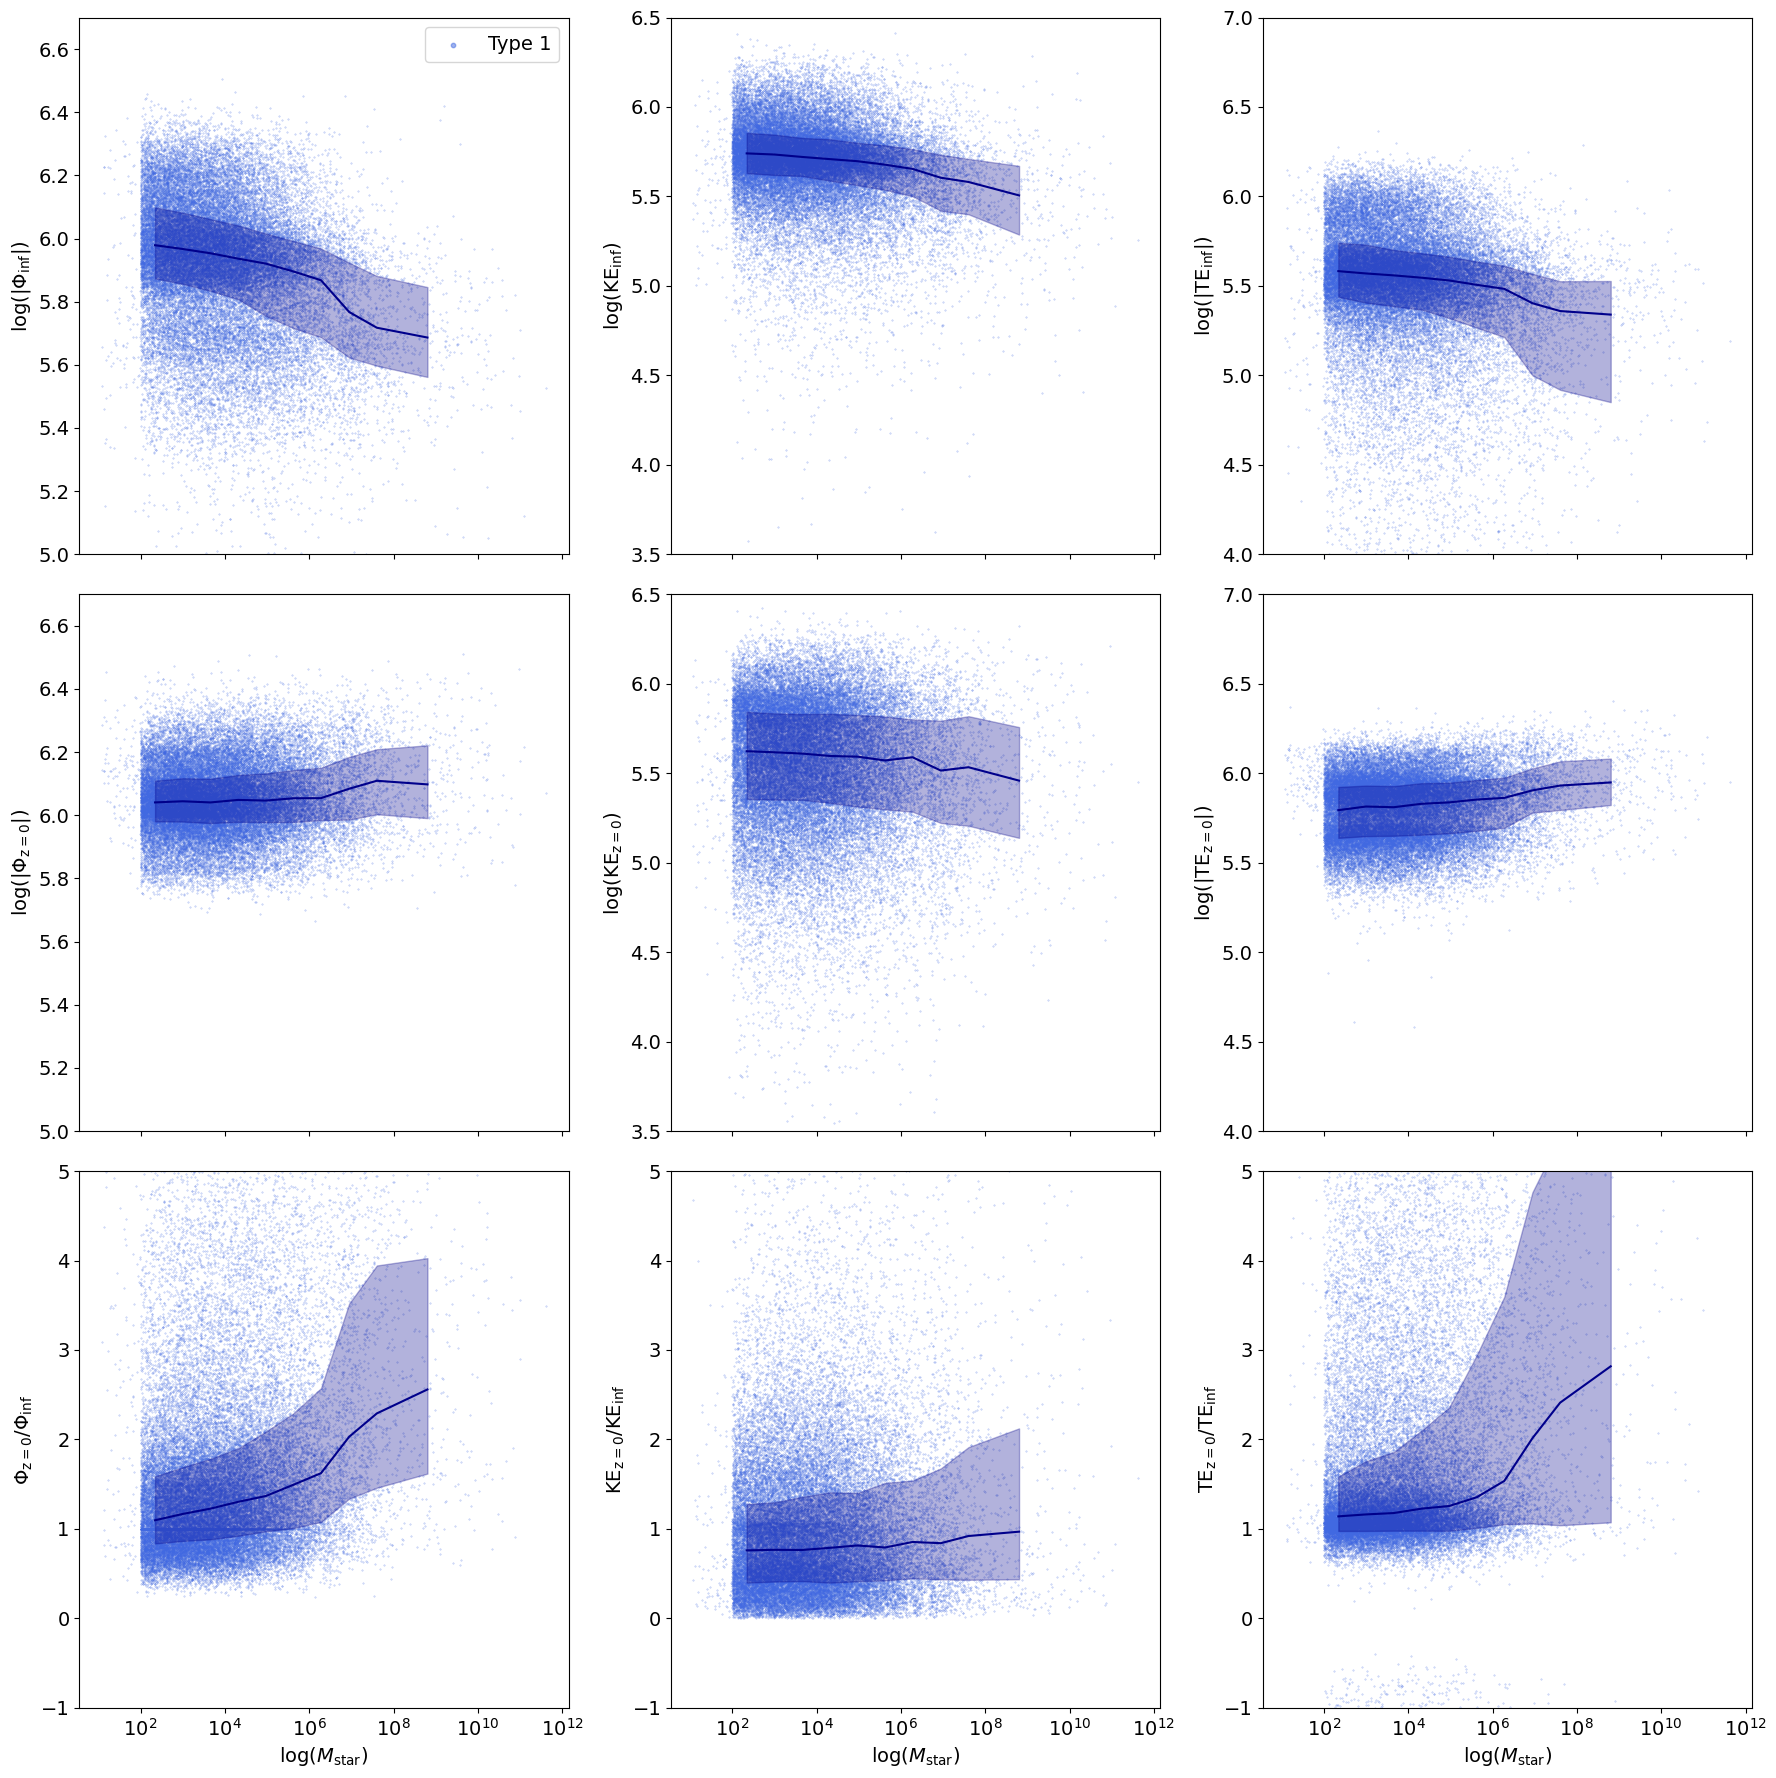

In [25]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows = 3, ncols = 3, figsize = (18, 18), sharex = True)

pske_if_ar = 0.5*np.linalg.norm(psvel_if_ar, axis = 1)**2
pske_f_ar = 0.5*np.linalg.norm(psvel_f_ar, axis = 1)**2
pmke_f_ar = 0.5*np.linalg.norm(pmvel_f_ar, axis = 1)**2
pmke_if_ar = 0.5*np.linalg.norm(pmvel_if_ar, axis = 1)**2
pste_f_ar = pspot_f_ar + pske_f_ar
pste_if_ar = pspot_if_ar + pske_if_ar


psix = (psfof == 0)
pmix = (pmfof == 0)

alpha = 0.5
s = 0.1

nbins = 10
mstar_bins = np.append(np.logspace(2, 8, nbins), 1e12)

pspot_if_ar_med = np.zeros(0)
pspot_f_ar_med = np.zeros(0)

pspot_frac_ar_med = np.zeros(0)
pspot_frac_ar_25 = np.zeros(0)
pspot_frac_ar_75 = np.zeros(0)


pspot_if_ar_25 = np.zeros(0)
pspot_if_ar_75 = np.zeros(0)

pspot_f_ar_25 = np.zeros(0)
pspot_f_ar_75 = np.zeros(0)

pske_if_ar_med = np.zeros(0)
pske_f_ar_med = np.zeros(0)

pske_frac_ar_med = np.zeros(0)
pske_frac_ar_25 = np.zeros(0)
pske_frac_ar_75 = np.zeros(0)


pske_if_ar_25 = np.zeros(0)
pske_if_ar_75 = np.zeros(0)

pske_f_ar_25 = np.zeros(0)
pske_f_ar_75 = np.zeros(0)


# Following is for Total energy
pste_if_ar_med = np.zeros(0)
pste_f_ar_med = np.zeros(0)

pste_frac_ar_med = np.zeros(0)
pste_frac_ar_25 = np.zeros(0)
pste_frac_ar_75 = np.zeros(0)


pste_if_ar_25 = np.zeros(0)
pste_if_ar_75 = np.zeros(0)

pste_f_ar_25 = np.zeros(0)
pste_f_ar_75 = np.zeros(0)

mstar_ar_med = np.zeros(0)

for ix in range(nbins):
    mstar_ar_med = np.append(mstar_ar_med, np.nanquantile(psmstar_all[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pspot_if_ar_med = np.append(pspot_if_ar_med, np.nanquantile(pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pspot_f_ar_med = np.append(pspot_f_ar_med, np.nanquantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pspot_if_ar_25 = np.append(pspot_if_ar_25, np.nanquantile(pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pspot_if_ar_75 = np.append(pspot_if_ar_75, np.nanquantile(pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pspot_f_ar_25 = np.append(pspot_f_ar_25, np.nanquantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pspot_f_ar_75 = np.append(pspot_f_ar_75, np.nanquantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pspot_frac_ar_med = np.append(pspot_frac_ar_med, np.quantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pspot_frac_ar_25 = np.append(pspot_frac_ar_25, np.quantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pspot_frac_ar_75 = np.append(pspot_frac_ar_75, np.quantile(pspot_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pspot_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    
    #Following part is for KE energy
    pske_if_ar_med = np.append(pske_if_ar_med, np.nanquantile(pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pske_f_ar_med = np.append(pske_f_ar_med, np.nanquantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pske_if_ar_25 = np.append(pske_if_ar_25, np.nanquantile(pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pske_if_ar_75 = np.append(pske_if_ar_75, np.nanquantile(pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pske_f_ar_25 = np.append(pske_f_ar_25, np.nanquantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pske_f_ar_75 = np.append(pske_f_ar_75, np.nanquantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pske_frac_ar_med = np.append(pske_frac_ar_med, np.quantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pske_frac_ar_25 = np.append(pske_frac_ar_25, np.quantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pske_frac_ar_75 = np.append(pske_frac_ar_75, np.quantile(pske_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pske_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))

    # fOLLOWING part is for total energy
    pste_if_ar_med = np.append(pste_if_ar_med, np.nanquantile(pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pste_f_ar_med = np.append(pste_f_ar_med, np.nanquantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pste_if_ar_25 = np.append(pste_if_ar_25, np.nanquantile(pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pste_if_ar_75 = np.append(pste_if_ar_75, np.nanquantile(pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pste_f_ar_25 = np.append(pste_f_ar_25, np.nanquantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pste_f_ar_75 = np.append(pste_f_ar_75, np.nanquantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pste_frac_ar_med = np.append(pste_frac_ar_med, np.quantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.5))
    pste_frac_ar_25 = np.append(pste_frac_ar_25, np.quantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.25))
    pste_frac_ar_75 = np.append(pste_frac_ar_75, np.quantile(pste_f_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])]/pste_if_ar[psix & (mstar_bins[ix] < psmstar_all) & (psmstar_all < mstar_bins[ix + 1])], 0.75))




ax1.scatter(psmstar_all[psix], np.log10(np.abs(pspot_if_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax1.plot(mstar_ar_med, np.log10(np.abs(pspot_if_ar_med)), color = 'darkblue')
ax1.fill_between(mstar_ar_med, np.log10(np.abs(pspot_if_ar_25)), np.log10(np.abs(pspot_if_ar_75)), color = 'darkblue', alpha = 0.3)
# ax1.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax1.scatter(psmstar_all[0], np.log10(np.abs(pspot_if_ar[0])) + 10, alpha = 0.5, color = 'royalblue', s = 10, label = 'Type 1')
# ax1.scatter(pmmstar_all[0], np.log10(np.abs(pmpot_if_ar[0])) + 10, alpha = 0.5, color = 'orange', s = 10, label = 'Type 2')
ax1.set_ylabel(r'$\rm{log(|\Phi_{inf}|)}$')
ax1.legend(loc = 'upper right')

ax4.scatter(psmstar_all[psix], np.log10(np.abs(pspot_f_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax4.plot(mstar_ar_med, np.log10(np.abs(pspot_f_ar_med)), color = 'darkblue')
ax4.fill_between(mstar_ar_med, np.log10(np.abs(pspot_f_ar_25)), np.log10(np.abs(pspot_f_ar_75)), color = 'darkblue', alpha = 0.3)
# ax4.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax4.set_ylabel(r'$\rm{log(|\Phi_{z= 0}|)}$')

ax2.scatter(psmstar_all[psix], np.log10(np.abs(pske_if_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax2.plot(mstar_ar_med, np.log10(np.abs(pske_if_ar_med)), color = 'darkblue')
ax2.fill_between(mstar_ar_med, np.log10(np.abs(pske_if_ar_25)), np.log10(np.abs(pske_if_ar_75)), color = 'darkblue', alpha = 0.3)
# ax2.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax2.set_ylabel(r'$\rm{log(KE_{inf})}$')

ax5.scatter(psmstar_all[psix], np.log10(np.abs(pske_f_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax5.plot(mstar_ar_med, np.log10(np.abs(pske_f_ar_med)), color = 'darkblue')
ax5.fill_between(mstar_ar_med, np.log10(np.abs(pske_f_ar_25)), np.log10(np.abs(pske_f_ar_75)), color = 'darkblue', alpha = 0.3)
# ax5.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax5.set_ylabel(r'$\rm{log(KE_{z = 0})}$')

ax3.scatter(psmstar_all[psix], np.log10(np.abs(pspot_if_ar[psix] + pske_if_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax3.plot(mstar_ar_med, np.log10(np.abs(pste_if_ar_med)), color = 'darkblue')
ax3.fill_between(mstar_ar_med, np.log10(np.abs(pste_if_ar_25)), np.log10(np.abs(pste_if_ar_75)), color = 'darkblue', alpha = 0.3)
# ax3.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix] + pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax3.set_ylabel(r'$\rm{log(|TE_{inf}|)}$')


ax6.scatter(psmstar_all[psix], np.log10(np.abs(pspot_f_ar[psix] + pske_f_ar[psix])), alpha = alpha, color = 'royalblue', s = s)
ax6.plot(mstar_ar_med, np.log10(np.abs(pste_f_ar_med)), color = 'darkblue')
ax6.fill_between(mstar_ar_med, np.log10(np.abs(pste_f_ar_25)), np.log10(np.abs(pste_f_ar_75)), color = 'darkblue', alpha = 0.3)
# ax6.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix] + pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax6.set_ylabel(r'$\rm{log(|TE_{z= 0}|)}$')

ax7.scatter(psmstar_all[psix], pspot_f_ar[psix]/pspot_if_ar[psix],  alpha = alpha, color = 'royalblue', s = s)
ax7.plot(mstar_ar_med, pspot_frac_ar_med, color = 'darkblue')
ax7.fill_between(mstar_ar_med, pspot_frac_ar_25, pspot_frac_ar_75, color = 'darkblue', alpha = 0.3)
# ax7.scatter(pmmstar_all[pmix], pmpot_f_ar[pmix]/pmpot_if_ar[pmix],  alpha = alpha, color = 'orange', s = s)
ax7.set_ylabel(r'$\rm{\Phi_{z = 0} / \Phi_{inf}}$')
ax7.set_ylim(-1,  5)

ax8.scatter(psmstar_all[psix], pske_f_ar[psix]/pske_if_ar[psix],  alpha =alpha, color = 'royalblue', s = s)
ax8.plot(mstar_ar_med, pske_frac_ar_med, color = 'darkblue')
ax8.fill_between(mstar_ar_med, pske_frac_ar_25, pske_frac_ar_75, color = 'darkblue', alpha = 0.3)
# ax8.scatter(pmmstar_all[pmix], pmke_f_ar[pmix]/pmke_if_ar[pmix],  alpha =alpha, color = 'orange', s = s)
ax8.set_ylabel(r'$\rm{KE_{z = 0} / KE_{inf}}$')
ax8.set_ylim(-1,  5)


ax9.scatter(psmstar_all[psix], (pspot_f_ar[psix] + pske_f_ar[psix])/(pspot_if_ar[psix] + pske_if_ar[psix]),  alpha = alpha, s = s, c='royalblue')
ax9.plot(mstar_ar_med, pste_frac_ar_med, color = 'darkblue')
ax9.fill_between(mstar_ar_med, pste_frac_ar_25, pste_frac_ar_75, color = 'darkblue', alpha = 0.3)
# ax9.scatter(pmmstar_all[pmix], (pmpot_f_ar[pmix] + pmke_f_ar[pmix])/(pmpot_if_ar[pmix] + pmke_if_ar[pmix]),  alpha = alpha, s = s, c='orange')
ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
ax9.set_ylim(-1,  5)
# cmap = 'turbo_r'
# col_ar = pmtinf_ar
# col_label = r'$t_{\rm{inf}}$'
# sc = ax9.scatter(psmstar_all, (pspot_f_ar + pske_f_ar)/(pspot_if_ar + pske_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.scatter(pmmstar_all, (pmpot_f_ar + pmke_f_ar)/(pmpot_if_ar + pmke_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
# ax9.set_ylim(-1,  5)

# cbar = plt.colorbar(sc, ax = ax9)
# cbar.set_label(col_label)

ax7.set_xlabel(r'$\log(M_{\rm{star}})$')
ax8.set_xlabel(r'$\log(M_{\rm{star}})$')
ax9.set_xlabel(r'$\log(M_{\rm{star}})$')

ax1.set_ylim(5, 6.7)
ax4.set_ylim(5, 6.7)
ax2.set_ylim(3.5, 6.5)
ax5.set_ylim(3.5, 6.5)
ax3.set_ylim(4, 7)
ax6.set_ylim(4, 7)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax4.set_xscale('log')
ax5.set_xscale('log')
ax6.set_xscale('log')
ax7.set_xscale('log')
ax8.set_xscale('log')
ax9.set_xscale('log')
plt.tight_layout()
plt.show()

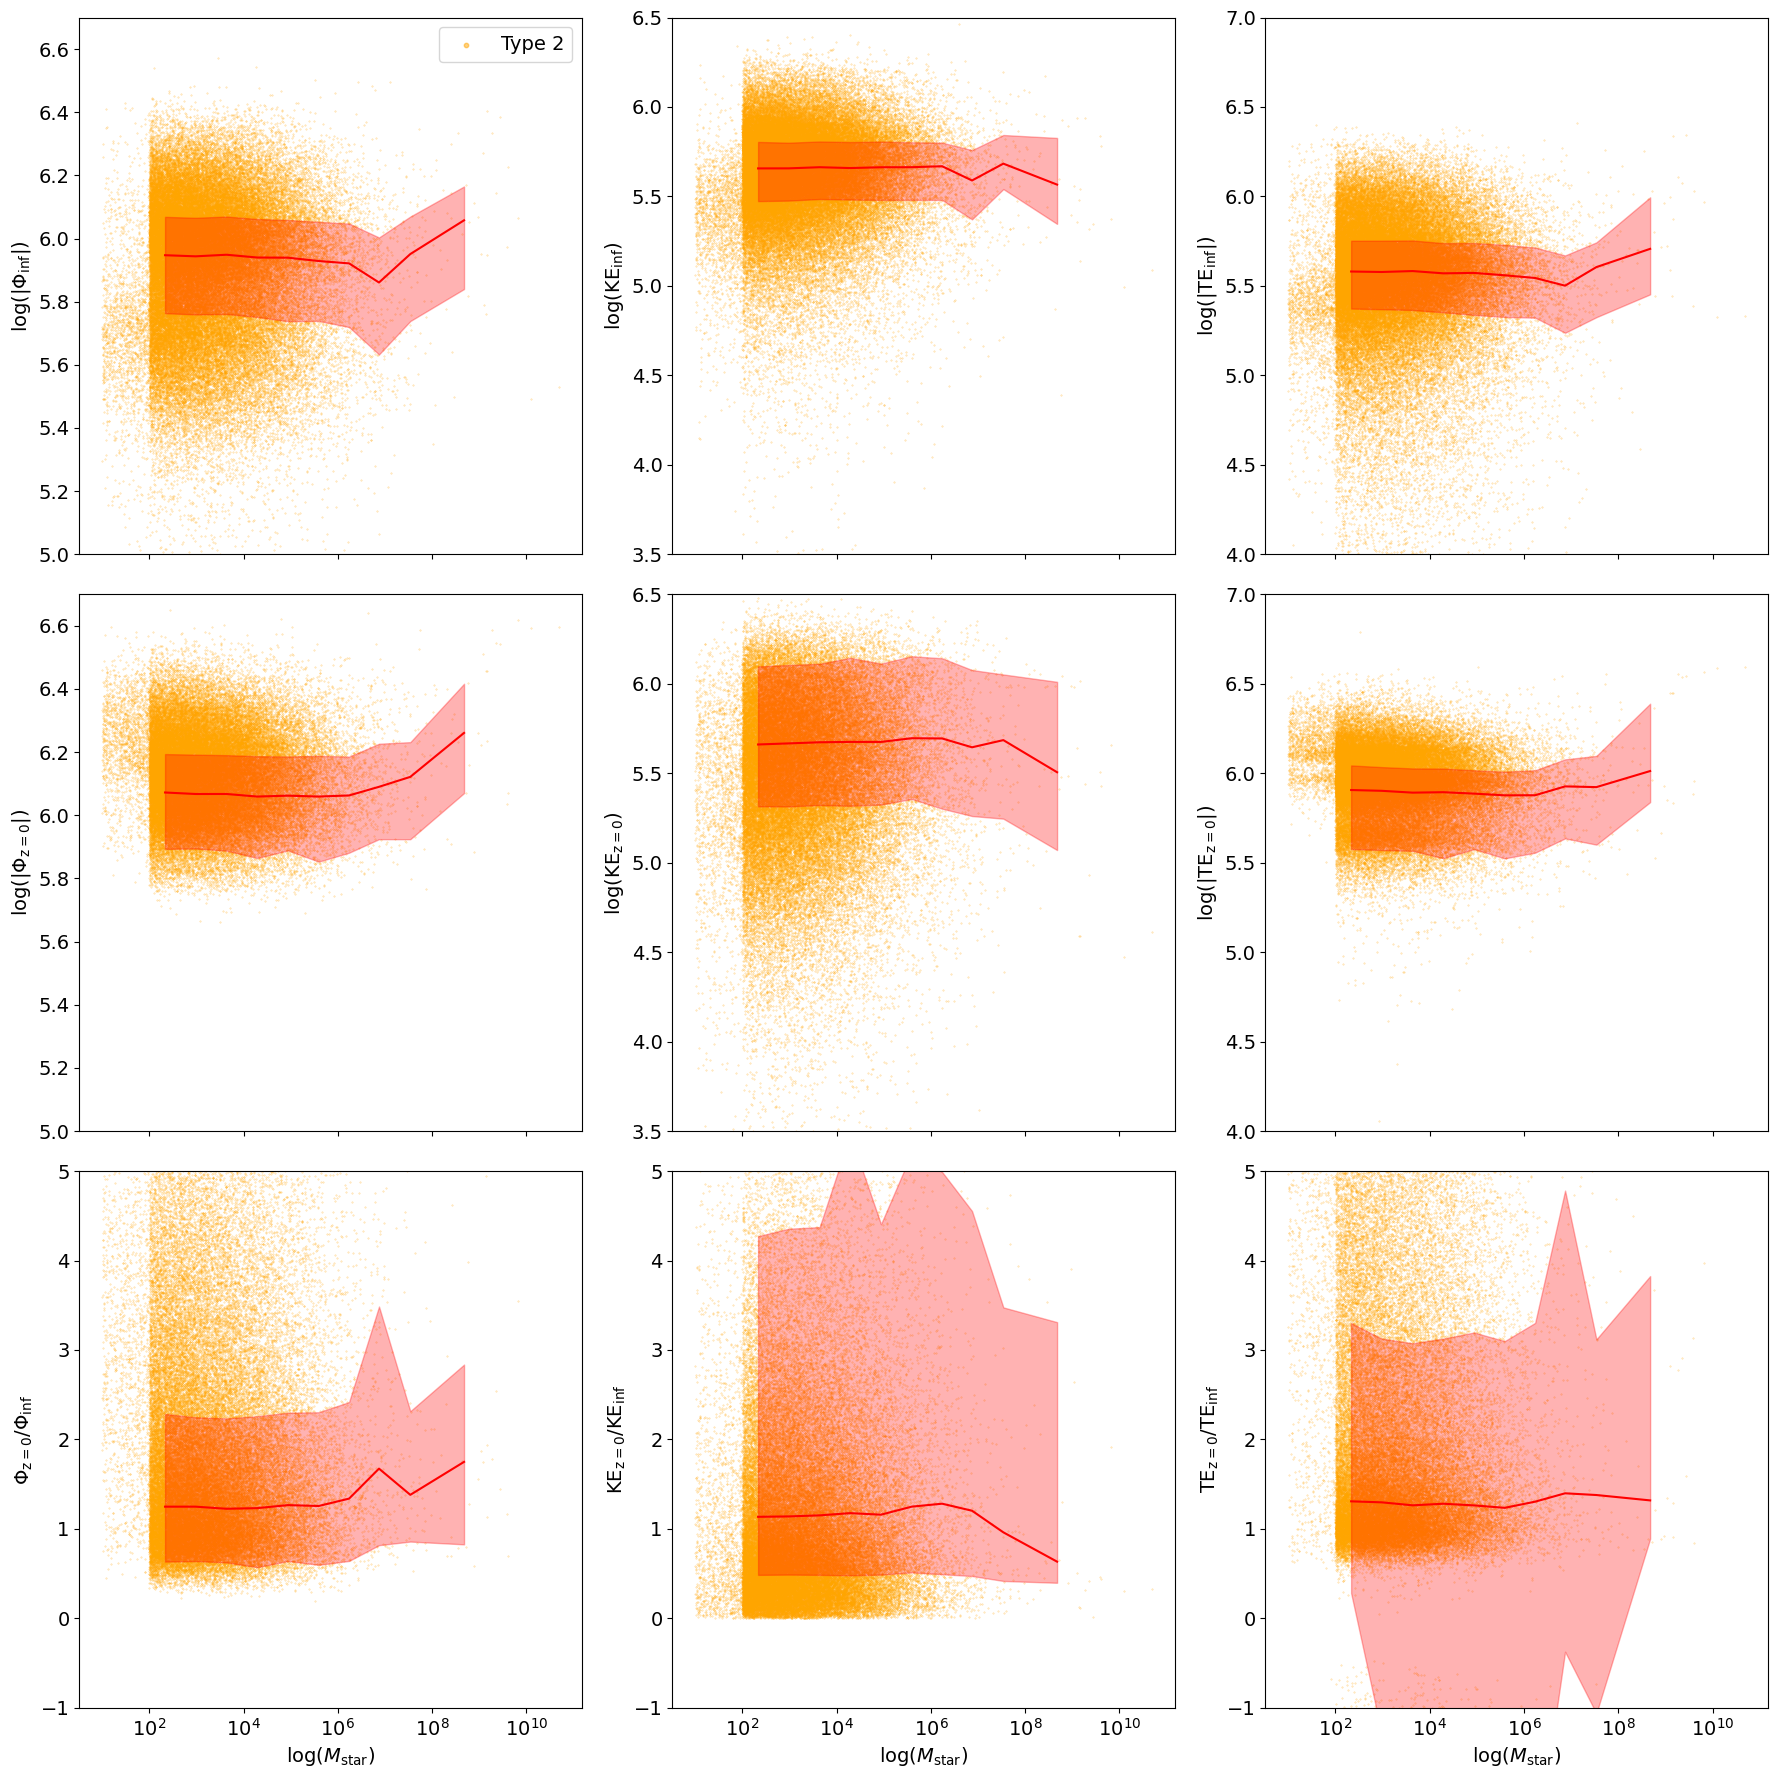

In [34]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows = 3, ncols = 3, figsize = (18, 18), sharex = True)

pmke_if_ar = 0.5*np.linalg.norm(pmvel_if_ar, axis = 1)**2
pmke_f_ar = 0.5*np.linalg.norm(pmvel_f_ar, axis = 1)**2
pmke_f_ar = 0.5*np.linalg.norm(pmvel_f_ar, axis = 1)**2
pmke_if_ar = 0.5*np.linalg.norm(pmvel_if_ar, axis = 1)**2
pmte_f_ar = pmpot_f_ar + pmke_f_ar
pmte_if_ar = pmpot_if_ar + pmke_if_ar


psix = (psfof == 0)
pmix = (pmfof == 0)

alpha = 0.5
s = 0.1

nbins = 10
mstar_bins = np.append(np.logspace(2, 8, nbins), 1e12)

pmpot_if_ar_med = np.zeros(0)
pmpot_f_ar_med = np.zeros(0)

pmpot_frac_ar_med = np.zeros(0)
pmpot_frac_ar_25 = np.zeros(0)
pmpot_frac_ar_75 = np.zeros(0)


pmpot_if_ar_25 = np.zeros(0)
pmpot_if_ar_75 = np.zeros(0)

pmpot_f_ar_25 = np.zeros(0)
pmpot_f_ar_75 = np.zeros(0)

pmke_if_ar_med = np.zeros(0)
pmke_f_ar_med = np.zeros(0)

pmke_frac_ar_med = np.zeros(0)
pmke_frac_ar_25 = np.zeros(0)
pmke_frac_ar_75 = np.zeros(0)


pmke_if_ar_25 = np.zeros(0)
pmke_if_ar_75 = np.zeros(0)

pmke_f_ar_25 = np.zeros(0)
pmke_f_ar_75 = np.zeros(0)


# Following is for Total energy
pmte_if_ar_med = np.zeros(0)
pmte_f_ar_med = np.zeros(0)

pmte_frac_ar_med = np.zeros(0)
pmte_frac_ar_25 = np.zeros(0)
pmte_frac_ar_75 = np.zeros(0)


pmte_if_ar_25 = np.zeros(0)
pmte_if_ar_75 = np.zeros(0)

pmte_f_ar_25 = np.zeros(0)
pmte_f_ar_75 = np.zeros(0)

mstar_ar_med = np.zeros(0)

for ix in range(nbins):
    mstar_ar_med = np.append(mstar_ar_med, np.nanquantile(pmmstar_all[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmpot_if_ar_med = np.append(pmpot_if_ar_med, np.nanquantile(pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmpot_f_ar_med = np.append(pmpot_f_ar_med, np.nanquantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pmpot_if_ar_25 = np.append(pmpot_if_ar_25, np.nanquantile(pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmpot_if_ar_75 = np.append(pmpot_if_ar_75, np.nanquantile(pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmpot_f_ar_25 = np.append(pmpot_f_ar_25, np.nanquantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmpot_f_ar_75 = np.append(pmpot_f_ar_75, np.nanquantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmpot_frac_ar_med = np.append(pmpot_frac_ar_med, np.quantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmpot_frac_ar_25 = np.append(pmpot_frac_ar_25, np.quantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmpot_frac_ar_75 = np.append(pmpot_frac_ar_75, np.quantile(pmpot_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmpot_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    
    #Following part is for KE energy
    pmke_if_ar_med = np.append(pmke_if_ar_med, np.nanquantile(pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmke_f_ar_med = np.append(pmke_f_ar_med, np.nanquantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pmke_if_ar_25 = np.append(pmke_if_ar_25, np.nanquantile(pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmke_if_ar_75 = np.append(pmke_if_ar_75, np.nanquantile(pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmke_f_ar_25 = np.append(pmke_f_ar_25, np.nanquantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmke_f_ar_75 = np.append(pmke_f_ar_75, np.nanquantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmke_frac_ar_med = np.append(pmke_frac_ar_med, np.quantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmke_frac_ar_25 = np.append(pmke_frac_ar_25, np.quantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmke_frac_ar_75 = np.append(pmke_frac_ar_75, np.quantile(pmke_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmke_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))

    # fOLLOWING part is for total energy
    pmte_if_ar_med = np.append(pmte_if_ar_med, np.nanquantile(pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmte_f_ar_med = np.append(pmte_f_ar_med, np.nanquantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pmte_if_ar_25 = np.append(pmte_if_ar_25, np.nanquantile(pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmte_if_ar_75 = np.append(pmte_if_ar_75, np.nanquantile(pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmte_f_ar_25 = np.append(pmte_f_ar_25, np.nanquantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmte_f_ar_75 = np.append(pmte_f_ar_75, np.nanquantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pmte_frac_ar_med = np.append(pmte_frac_ar_med, np.quantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.5))
    pmte_frac_ar_25 = np.append(pmte_frac_ar_25, np.quantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.25))
    pmte_frac_ar_75 = np.append(pmte_frac_ar_75, np.quantile(pmte_f_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])]/pmte_if_ar[pmix & (mstar_bins[ix] < pmmstar_all) & (pmmstar_all < mstar_bins[ix + 1])], 0.75))



ax1.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax1.plot(mstar_ar_med, np.log10(np.abs(pmpot_if_ar_med)), color = 'red')
ax1.fill_between(mstar_ar_med, np.log10(np.abs(pmpot_if_ar_25)), np.log10(np.abs(pmpot_if_ar_75)), color = 'red', alpha = 0.3)
# ax1.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
# ax1.scatter(pmmstar_all[0], np.log10(np.abs(pmpot_if_ar[0])) + 10, alpha = 0.5, color = 'royalblue', s = 10, label = 'Type 1')
ax1.scatter(pmmstar_all[0], np.log10(np.abs(pmpot_if_ar[0])) + 10, alpha = 0.5, color = 'orange', s = 10, label = 'Type 2')
ax1.set_ylabel(r'$\rm{log(|\Phi_{inf}|)}$')
ax1.legend(loc = 'upper right')

ax4.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax4.plot(mstar_ar_med, np.log10(np.abs(pmpot_f_ar_med)), color = 'red')
ax4.fill_between(mstar_ar_med, np.log10(np.abs(pmpot_f_ar_25)), np.log10(np.abs(pmpot_f_ar_75)), color = 'red', alpha = 0.3)
# ax4.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax4.set_ylabel(r'$\rm{log(|\Phi_{z= 0}|)}$')

ax2.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax2.plot(mstar_ar_med, np.log10(np.abs(pmke_if_ar_med)), color = 'red')
ax2.fill_between(mstar_ar_med, np.log10(np.abs(pmke_if_ar_25)), np.log10(np.abs(pmke_if_ar_75)), color = 'red', alpha = 0.3)
# ax2.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax2.set_ylabel(r'$\rm{log(KE_{inf})}$')

ax5.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax5.plot(mstar_ar_med, np.log10(np.abs(pmke_f_ar_med)), color = 'red')
ax5.fill_between(mstar_ar_med, np.log10(np.abs(pmke_f_ar_25)), np.log10(np.abs(pmke_f_ar_75)), color = 'red', alpha = 0.3)
# ax5.scatter(pmmstar_all[pmix], np.log10(np.abs(pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax5.set_ylabel(r'$\rm{log(KE_{z = 0})}$')

ax3.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix] + pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax3.plot(mstar_ar_med, np.log10(np.abs(pmte_if_ar_med)), color = 'red')
ax3.fill_between(mstar_ar_med, np.log10(np.abs(pmte_if_ar_25)), np.log10(np.abs(pmte_if_ar_75)), color = 'red', alpha = 0.3)
# ax3.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_if_ar[pmix] + pmke_if_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax3.set_ylabel(r'$\rm{log(|TE_{inf}|)}$')


ax6.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix] + pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax6.plot(mstar_ar_med, np.log10(np.abs(pmte_f_ar_med)), color = 'red')
ax6.fill_between(mstar_ar_med, np.log10(np.abs(pmte_f_ar_25)), np.log10(np.abs(pmte_f_ar_75)), color = 'red', alpha = 0.3)
# ax6.scatter(pmmstar_all[pmix], np.log10(np.abs(pmpot_f_ar[pmix] + pmke_f_ar[pmix])), alpha = alpha, color = 'orange', s = s)
ax6.set_ylabel(r'$\rm{log(|TE_{z= 0}|)}$')

ax7.scatter(pmmstar_all[pmix], pmpot_f_ar[pmix]/pmpot_if_ar[pmix],  alpha = alpha, color = 'orange', s = s)
ax7.plot(mstar_ar_med, pmpot_frac_ar_med, color = 'red')
ax7.fill_between(mstar_ar_med, pmpot_frac_ar_25, pmpot_frac_ar_75, color = 'red', alpha = 0.3)
# ax7.scatter(pmmstar_all[pmix], pmpot_f_ar[pmix]/pmpot_if_ar[pmix],  alpha = alpha, color = 'orange', s = s)
ax7.set_ylabel(r'$\rm{\Phi_{z = 0} / \Phi_{inf}}$')
ax7.set_ylim(-1,  5)

ax8.scatter(pmmstar_all[pmix], pmke_f_ar[pmix]/pmke_if_ar[pmix],  alpha =alpha, color = 'orange', s = s)
ax8.plot(mstar_ar_med, pmke_frac_ar_med, color = 'red')
ax8.fill_between(mstar_ar_med, pmke_frac_ar_25, pmke_frac_ar_75, color = 'red', alpha = 0.3)
# ax8.scatter(pmmstar_all[pmix], pmke_f_ar[pmix]/pmke_if_ar[pmix],  alpha =alpha, color = 'orange', s = s)
ax8.set_ylabel(r'$\rm{KE_{z = 0} / KE_{inf}}$')
ax8.set_ylim(-1,  5)


ax9.scatter(pmmstar_all[pmix], (pmpot_f_ar[pmix] + pmke_f_ar[pmix])/(pmpot_if_ar[pmix] + pmke_if_ar[pmix]),  alpha = alpha, s = s, c='orange')
ax9.plot(mstar_ar_med, pmte_frac_ar_med, color = 'red')
ax9.fill_between(mstar_ar_med, pmte_frac_ar_25, pmte_frac_ar_75, color = 'red', alpha = 0.3)
# ax9.scatter(pmmstar_all[pmix], (pmpot_f_ar[pmix] + pmke_f_ar[pmix])/(pmpot_if_ar[pmix] + pmke_if_ar[pmix]),  alpha = alpha, s = s, c='orange')
ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
ax9.set_ylim(-1,  5)
# cmap = 'turbo_r'
# col_ar = pmtinf_ar
# col_label = r'$t_{\rm{inf}}$'
# sc = ax9.scatter(pmmstar_all, (pmpot_f_ar + pmke_f_ar)/(pmpot_if_ar + pmke_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.scatter(pmmstar_all, (pmpot_f_ar + pmke_f_ar)/(pmpot_if_ar + pmke_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
# ax9.set_ylim(-1,  5)

# cbar = plt.colorbar(sc, ax = ax9)
# cbar.set_label(col_label)

ax7.set_xlabel(r'$\log(M_{\rm{star}})$')
ax8.set_xlabel(r'$\log(M_{\rm{star}})$')
ax9.set_xlabel(r'$\log(M_{\rm{star}})$')

ax1.set_ylim(5, 6.7)
ax4.set_ylim(5, 6.7)
ax2.set_ylim(3.5, 6.5)
ax5.set_ylim(3.5, 6.5)
ax3.set_ylim(4, 7)
ax6.set_ylim(4, 7)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax4.set_xscale('log')
ax5.set_xscale('log')
ax6.set_xscale('log')
ax7.set_xscale('log')
ax8.set_xscale('log')
ax9.set_xscale('log')
plt.tight_layout()
plt.show()


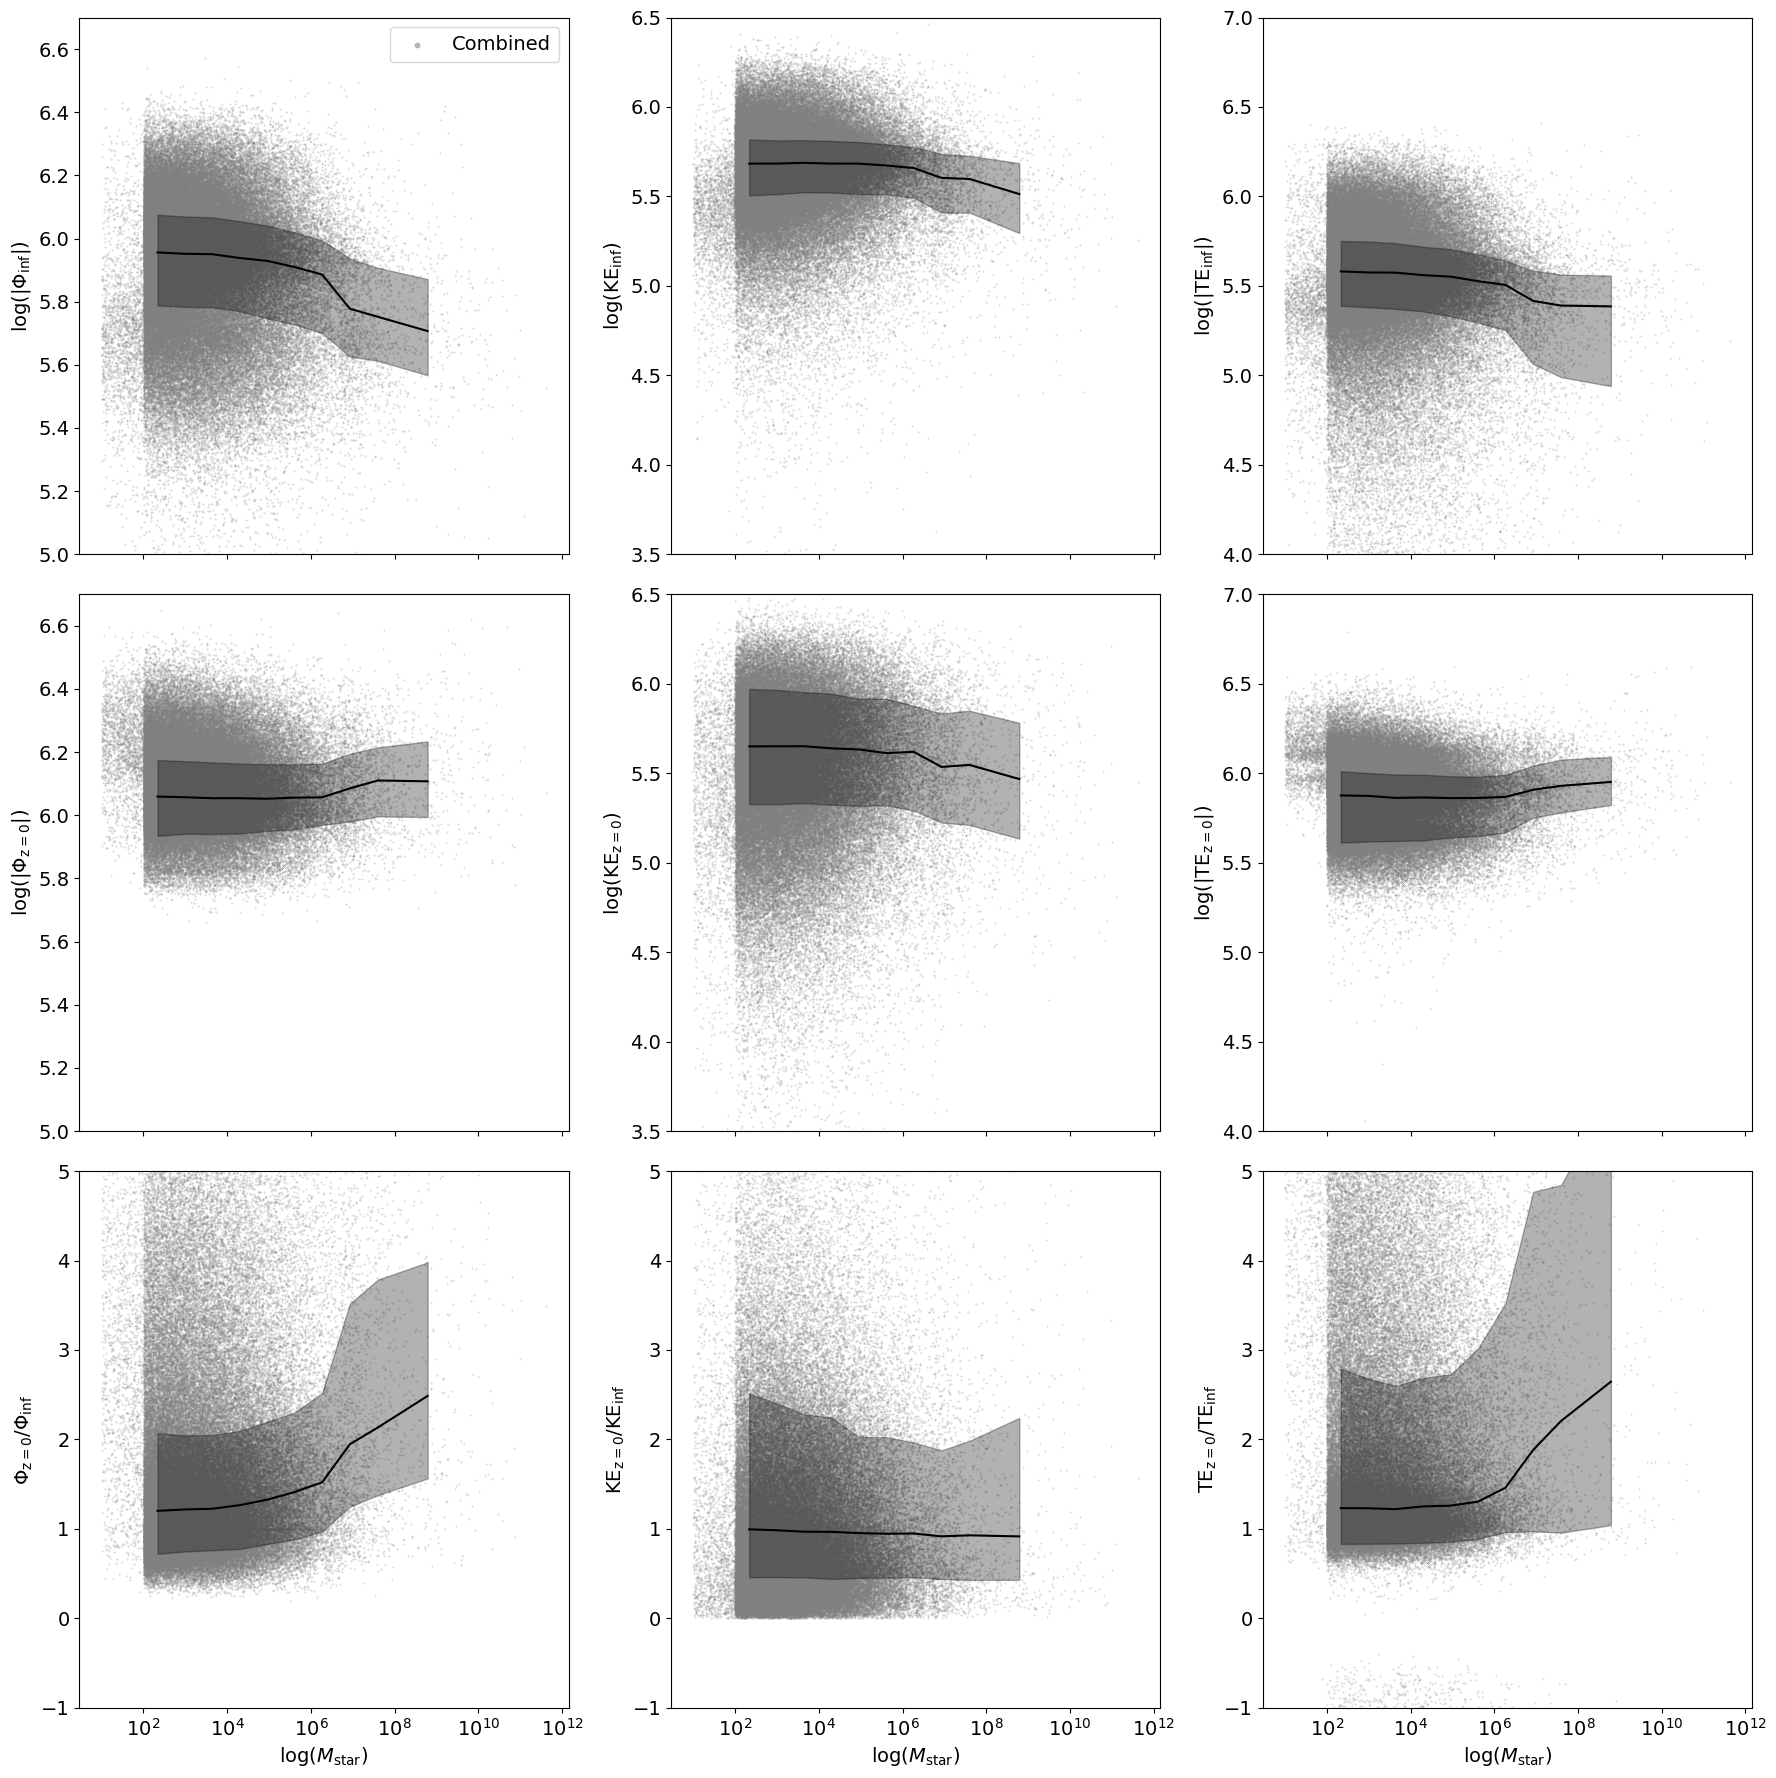

In [41]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows = 3, ncols = 3, figsize = (18, 18), sharex = True)

pske_if_ar = 0.5*np.linalg.norm(psvel_if_ar, axis = 1)**2
pske_f_ar = 0.5*np.linalg.norm(psvel_f_ar, axis = 1)**2
pmke_f_ar = 0.5*np.linalg.norm(pmvel_f_ar, axis = 1)**2
pmke_if_ar = 0.5*np.linalg.norm(pmvel_if_ar, axis = 1)**2
pmte_f_ar = pmpot_f_ar + pmke_f_ar
pmte_if_ar = pmpot_if_ar + pmke_if_ar

pste_f_ar = pspot_f_ar + pske_f_ar
pste_if_ar = pspot_if_ar + pske_if_ar


psix = (psfof == 0)
pmix = (pmfof == 0)

pix = np.append(psix, pmix)
pke_if_ar = np.append(pske_if_ar, pmke_if_ar)
pke_f_ar = np.append(pske_f_ar, pmke_f_ar)
pte_if_ar = np.append(pste_if_ar, pmte_if_ar)
pte_f_ar = np.append(pste_f_ar, pmte_f_ar)
ppot_if_ar = np.append(pspot_if_ar, pmpot_if_ar)
ppot_f_ar = np.append(pspot_f_ar, pmpot_f_ar)


pmstar_all = np.append(psmstar_all, pmmstar_all,)

alpha = 0.5
s = 0.1

nbins = 10
mstar_bins = np.append(np.logspace(2, 8, nbins), 1e12)

ppot_if_ar_med = np.zeros(0)
ppot_f_ar_med = np.zeros(0)

ppot_frac_ar_med = np.zeros(0)
ppot_frac_ar_25 = np.zeros(0)
ppot_frac_ar_75 = np.zeros(0)


ppot_if_ar_25 = np.zeros(0)
ppot_if_ar_75 = np.zeros(0)

ppot_f_ar_25 = np.zeros(0)
ppot_f_ar_75 = np.zeros(0)

pke_if_ar_med = np.zeros(0)
pke_f_ar_med = np.zeros(0)

pke_frac_ar_med = np.zeros(0)
pke_frac_ar_25 = np.zeros(0)
pke_frac_ar_75 = np.zeros(0)


pke_if_ar_25 = np.zeros(0)
pke_if_ar_75 = np.zeros(0)

pke_f_ar_25 = np.zeros(0)
pke_f_ar_75 = np.zeros(0)


# Following is for Total energy
pte_if_ar_med = np.zeros(0)
pte_f_ar_med = np.zeros(0)

pte_frac_ar_med = np.zeros(0)
pte_frac_ar_25 = np.zeros(0)
pte_frac_ar_75 = np.zeros(0)


pte_if_ar_25 = np.zeros(0)
pte_if_ar_75 = np.zeros(0)

pte_f_ar_25 = np.zeros(0)
pte_f_ar_75 = np.zeros(0)

mstar_ar_med = np.zeros(0)

for ix in range(nbins):
    mstar_ar_med = np.append(mstar_ar_med, np.nanquantile(pmstar_all[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    ppot_if_ar_med = np.append(ppot_if_ar_med, np.nanquantile(ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    ppot_f_ar_med = np.append(ppot_f_ar_med, np.nanquantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    
    ppot_if_ar_25 = np.append(ppot_if_ar_25, np.nanquantile(ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    ppot_if_ar_75 = np.append(ppot_if_ar_75, np.nanquantile(ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    ppot_f_ar_25 = np.append(ppot_f_ar_25, np.nanquantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    ppot_f_ar_75 = np.append(ppot_f_ar_75, np.nanquantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    ppot_frac_ar_med = np.append(ppot_frac_ar_med, np.quantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    ppot_frac_ar_25 = np.append(ppot_frac_ar_25, np.quantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    ppot_frac_ar_75 = np.append(ppot_frac_ar_75, np.quantile(ppot_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/ppot_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    
    #Following part is for KE energy
    pke_if_ar_med = np.append(pke_if_ar_med, np.nanquantile(pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    pke_f_ar_med = np.append(pke_f_ar_med, np.nanquantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pke_if_ar_25 = np.append(pke_if_ar_25, np.nanquantile(pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pke_if_ar_75 = np.append(pke_if_ar_75, np.nanquantile(pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pke_f_ar_25 = np.append(pke_f_ar_25, np.nanquantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pke_f_ar_75 = np.append(pke_f_ar_75, np.nanquantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pke_frac_ar_med = np.append(pke_frac_ar_med, np.quantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    pke_frac_ar_25 = np.append(pke_frac_ar_25, np.quantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pke_frac_ar_75 = np.append(pke_frac_ar_75, np.quantile(pke_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pke_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))

    # fOLLOWING part is for total energy
    pte_if_ar_med = np.append(pte_if_ar_med, np.nanquantile(pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    pte_f_ar_med = np.append(pte_f_ar_med, np.nanquantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    
    pte_if_ar_25 = np.append(pte_if_ar_25, np.nanquantile(pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pte_if_ar_75 = np.append(pte_if_ar_75, np.nanquantile(pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pte_f_ar_25 = np.append(pte_f_ar_25, np.nanquantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pte_f_ar_75 = np.append(pte_f_ar_75, np.nanquantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))
    
    pte_frac_ar_med = np.append(pte_frac_ar_med, np.quantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.5))
    pte_frac_ar_25 = np.append(pte_frac_ar_25, np.quantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.25))
    pte_frac_ar_75 = np.append(pte_frac_ar_75, np.quantile(pte_f_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])]/pte_if_ar[pix & (mstar_bins[ix] < pmstar_all) & (pmstar_all < mstar_bins[ix + 1])], 0.75))



ax1.scatter(pmstar_all[pix], np.log10(np.abs(ppot_if_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax1.plot(mstar_ar_med, np.log10(np.abs(ppot_if_ar_med)), color = 'black')
ax1.fill_between(mstar_ar_med, np.log10(np.abs(ppot_if_ar_25)), np.log10(np.abs(ppot_if_ar_75)), color = 'black', alpha = 0.3)
# ax1.scatter(pmstar_all[pix], np.log10(np.abs(ppot_if_ar[pix])), alpha = alpha, color = 'orange', s = s)
# ax1.scatter(pmstar_all[0], np.log10(np.abs(ppot_if_ar[0])) + 10, alpha = 0.5, color = 'royalblue', s = 10, label = 'Type 1')
ax1.scatter(pmstar_all[0], np.log10(np.abs(ppot_if_ar[0])) + 10, alpha = 0.5, color = 'gray', s = 10, label = 'Combined')

ax1.legend(loc = 'upper right')

ax4.scatter(pmstar_all[pix], np.log10(np.abs(ppot_f_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax4.plot(mstar_ar_med, np.log10(np.abs(ppot_f_ar_med)), color = 'black')
ax4.fill_between(mstar_ar_med, np.log10(np.abs(ppot_f_ar_25)), np.log10(np.abs(ppot_f_ar_75)), color = 'black', alpha = 0.3)
# ax4.scatter(pmstar_all[pix], np.log10(np.abs(ppot_f_ar[pix])), alpha = alpha, color = 'orange', s = s)
ax4.set_ylabel(r'$\rm{log(|\Phi_{z= 0}|)}$')

ax2.scatter(pmstar_all[pix], np.log10(np.abs(pke_if_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax2.plot(mstar_ar_med, np.log10(np.abs(pke_if_ar_med)), color = 'black')
ax2.fill_between(mstar_ar_med, np.log10(np.abs(pke_if_ar_25)), np.log10(np.abs(pke_if_ar_75)), color = 'black', alpha = 0.3)
# ax2.scatter(pmstar_all[pix], np.log10(np.abs(pke_if_ar[pix])), alpha = alpha, color = 'orange', s = s)
ax2.set_ylabel(r'$\rm{log(KE_{inf})}$')

ax5.scatter(pmstar_all[pix], np.log10(np.abs(pke_f_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax5.plot(mstar_ar_med, np.log10(np.abs(pke_f_ar_med)), color = 'black')
ax5.fill_between(mstar_ar_med, np.log10(np.abs(pke_f_ar_25)), np.log10(np.abs(pke_f_ar_75)), color = 'black', alpha = 0.3)
# ax5.scatter(pmstar_all[pix], np.log10(np.abs(pke_f_ar[pix])), alpha = alpha, color = 'orange', s = s)
ax5.set_ylabel(r'$\rm{log(KE_{z = 0})}$')

ax3.scatter(pmstar_all[pix], np.log10(np.abs(ppot_if_ar[pix] + pke_if_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax3.plot(mstar_ar_med, np.log10(np.abs(pte_if_ar_med)), color = 'black')
ax3.fill_between(mstar_ar_med, np.log10(np.abs(pte_if_ar_25)), np.log10(np.abs(pte_if_ar_75)), color = 'black', alpha = 0.3)
# ax3.scatter(pmstar_all[pix], np.log10(np.abs(ppot_if_ar[pix] + pke_if_ar[pix])), alpha = alpha, color = 'orange', s = s)
ax3.set_ylabel(r'$\rm{log(|TE_{inf}|)}$')


ax6.scatter(pmstar_all[pix], np.log10(np.abs(ppot_f_ar[pix] + pke_f_ar[pix])), alpha = alpha, color = 'gray', s = s)
ax6.plot(mstar_ar_med, np.log10(np.abs(pte_f_ar_med)), color = 'black')
ax6.fill_between(mstar_ar_med, np.log10(np.abs(pte_f_ar_25)), np.log10(np.abs(pte_f_ar_75)), color = 'black', alpha = 0.3)
# ax6.scatter(pmstar_all[pix], np.log10(np.abs(ppot_f_ar[pix] + pke_f_ar[pix])), alpha = alpha, color = 'orange', s = s)
ax6.set_ylabel(r'$\rm{log(|TE_{z= 0}|)}$')

ax7.scatter(pmstar_all[pix], ppot_f_ar[pix]/ppot_if_ar[pix],  alpha = alpha, color = 'gray', s = s)
ax7.plot(mstar_ar_med, ppot_frac_ar_med, color = 'black')
ax7.fill_between(mstar_ar_med, ppot_frac_ar_25, ppot_frac_ar_75, color = 'black', alpha = 0.3)
# ax7.scatter(pmstar_all[pix], ppot_f_ar[pix]/ppot_if_ar[pix],  alpha = alpha, color = 'orange', s = s)
ax7.set_ylabel(r'$\rm{\Phi_{z = 0} / \Phi_{inf}}$')
ax7.set_ylim(-1,  5)

ax8.scatter(pmstar_all[pix], pke_f_ar[pix]/pke_if_ar[pix],  alpha =alpha, color = 'gray', s = s)
ax8.plot(mstar_ar_med, pke_frac_ar_med, color = 'black')
ax8.fill_between(mstar_ar_med, pke_frac_ar_25, pke_frac_ar_75, color = 'black', alpha = 0.3)
# ax8.scatter(pmstar_all[pix], pke_f_ar[pix]/pke_if_ar[pix],  alpha =alpha, color = 'orange', s = s)
ax8.set_ylabel(r'$\rm{KE_{z = 0} / KE_{inf}}$')
ax8.set_ylim(-1,  5)


ax9.scatter(pmstar_all[pix], (ppot_f_ar[pix] + pke_f_ar[pix])/(ppot_if_ar[pix] + pke_if_ar[pix]),  alpha = alpha, s = s, c='gray')
ax9.plot(mstar_ar_med, pte_frac_ar_med, color = 'black')
ax9.fill_between(mstar_ar_med, pte_frac_ar_25, pte_frac_ar_75, color = 'black', alpha = 0.3)
# ax9.scatter(pmstar_all[pix], (ppot_f_ar[pix] + pke_f_ar[pix])/(ppot_if_ar[pix] + pke_if_ar[pix]),  alpha = alpha, s = s, c='orange')
ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
ax9.set_ylim(-1,  5)

# cmap = 'turbo_r'
# col_ar = pmtinf_ar
# col_label = r'$t_{\rm{inf}}$'
# sc = ax9.scatter(pmmstar_all, (pmpot_f_ar + pmke_f_ar)/(pmpot_if_ar + pmke_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.scatter(pmmstar_all, (pmpot_f_ar + pmke_f_ar)/(pmpot_if_ar + pmke_if_ar),  alpha = 0.75, s = 0.2, c=col_ar, cmap=cmap)
# ax9.set_ylabel(r'$\rm{TE_{z = 0} / TE_{inf}}$')
# ax9.set_ylim(-1,  5)

# cbar = plt.colorbar(sc, ax = ax9)
# cbar.set_label(col_label)

ax7.set_xlabel(r'$\log(M_{\rm{star}})$')
ax8.set_xlabel(r'$\log(M_{\rm{star}})$')
ax9.set_xlabel(r'$\log(M_{\rm{star}})$')

ax1.set_ylim(5, 6.7)
ax4.set_ylim(5, 6.7)
ax2.set_ylim(3.5, 6.5)
ax5.set_ylim(3.5, 6.5)
ax3.set_ylim(4, 7)
ax6.set_ylim(4, 7)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax4.set_xscale('log')
ax5.set_xscale('log')
ax6.set_xscale('log')
ax7.set_xscale('log')
ax8.set_xscale('log')
ax9.set_xscale('log')
plt.tight_layout()
plt.show()


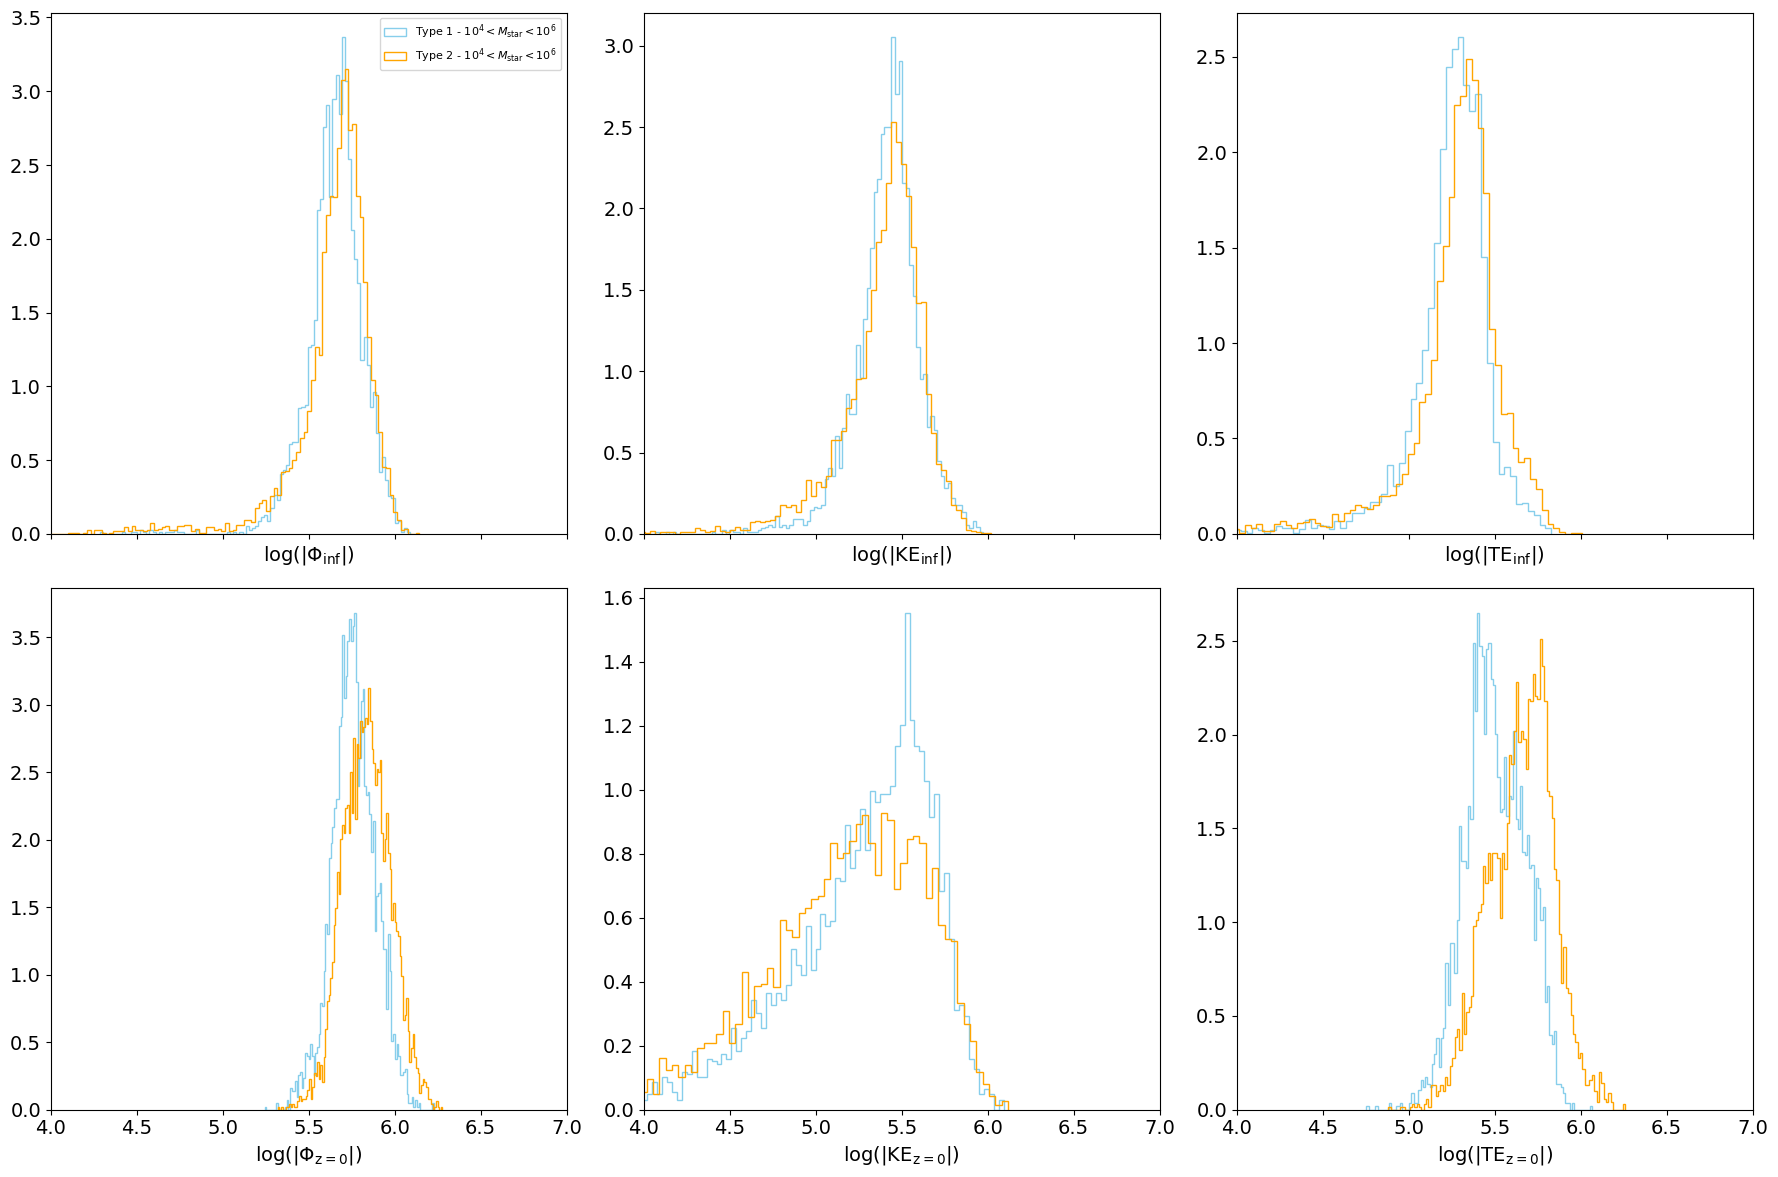

In [73]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(nrows = 2, ncols = 3, figsize = (18, 12), sharex = True)

pscond = np.isfinite(pspot_if_ar) & (psfof == 2) & (1e4 < psmstar_all) & (psmstar_all < 1e6)
pmcond = np.isfinite(pmpot_if_ar) & np.isfinite(pmpot_f_ar) & (pmfof == 2) & (1e4 < pmmstar_all) & (pmmstar_all < 1e6)

# pcond2 = np.isfinite(ppot_if_ar) & pix & (1e9 < pmstar_all) & np.isfinite(ppot_f_ar)
# pmcond2 = np.isfinite(pmpot_if_ar) & np.isfinite(pmpot_f_ar) & (pmfof == 0) & (1e9 < pmmstar_all) 

nbinny = 100
nbinny2 = 15

ax1.hist(np.log10(np.abs(pspot_if_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True, label = r'Type 1 - $10^4 < M_{\rm{star}} < 10^6$')
ax1.hist(np.log10(np.abs(pmpot_if_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True, label = r'Type 2 - $10^4 < M_{\rm{star}} < 10^6$')
# ax1.hist(np.log10(np.abs(ppot_if_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True, label = r'Combined - $ M_{\rm{star}} > 10^9$')
ax1.set_xlabel(r'$\rm{log(|\Phi_{inf}|)}$')
ax1.legend(fontsize = 8)


ax2.hist(np.log10(np.abs(pske_if_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True)
ax2.hist(np.log10(np.abs(pmke_if_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True)
# ax2.hist(np.log10(np.abs(pke_if_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True)
ax2.set_xlabel(r'$\rm{log(|KE_{inf}|)}$')


ax3.hist(np.log10(np.abs(pste_if_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True)
ax3.hist(np.log10(np.abs(pmte_if_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True)
# ax3.hist(np.log10(np.abs(pte_if_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True)
ax3.set_xlabel(r'$\rm{log(|TE_{inf}|)}$')


ax4.hist(np.log10(np.abs(pspot_f_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True)
ax4.hist(np.log10(np.abs(pmpot_f_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True)
# ax4.hist(np.log10(np.abs(ppot_f_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True)
ax4.set_xlabel(r'$\rm{log(|\Phi_{z = 0}|)}$')


ax5.hist(np.log10(np.abs(pske_f_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True)
ax5.hist(np.log10(np.abs(pmke_f_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True)
# ax5.hist(np.log10(np.abs(pke_f_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True)
ax5.set_xlabel(r'$\rm{log(|KE_{z = 0}|)}$')


ax6.hist(np.log10(np.abs(pste_f_ar[pscond])), bins = nbinny, histtype = 'step', color = 'skyblue', density = True)
ax6.hist(np.log10(np.abs(pmte_f_ar[pmcond])), bins = nbinny, histtype = 'step', color = 'orange', density = True)
# ax6.hist(np.log10(np.abs(pte_f_ar[pcond2])), bins = nbinny2, histtype = 'step', color = 'green', density = True)
ax6.set_xlabel(r'$\rm{log(|TE_{z = 0}|)}$')

ax1.set_xlim(5, 6.7)
ax4.set_xlim(5, 6.7)
ax2.set_xlim(3.5, 6.5)
ax5.set_xlim(3.5, 6.5)
ax3.set_xlim(4, 7)
ax6.set_xlim(4, 7)

plt.tight_layout()
plt.show()
plt.close()

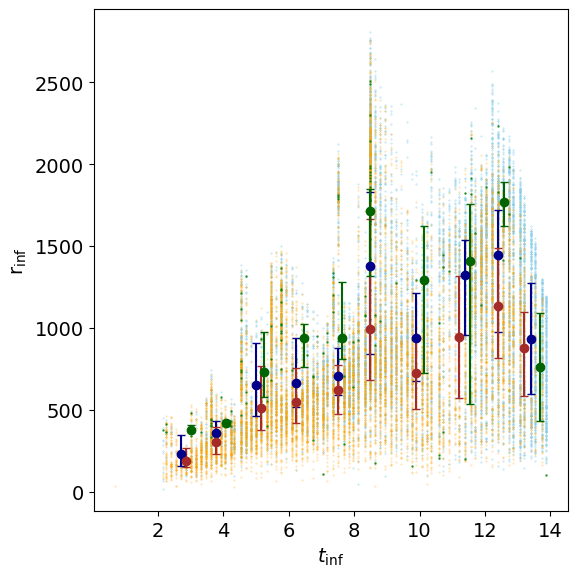

In [130]:
# This is to make scatter plot for infall time vs distance from cluster

fig, ax = plt.subplots(figsize = (6, 6))

pdist_if_ar = np.append(psdist_if_ar, pmdist_if_ar)
ptinf_ar = np.append(pstinf_ar, pmtinf_ar)

nbins = 10
tinf_bins = np.append(np.linspace(2, 13, nbins), 14)

pstinf_ar_med = np.zeros(0)
pmtinf_ar_med = np.zeros(0)
ptinf_ar_med = np.zeros(0)

psdist_if_med = np.zeros(0)
psdist_if_25 = np.zeros(0)
psdist_if_75 = np.zeros(0)

pmdist_if_med = np.zeros(0)
pmdist_if_25 = np.zeros(0)
pmdist_if_75 = np.zeros(0)

pdist_if_med = np.zeros(0)
pdist_if_25 = np.zeros(0)
pdist_if_75 = np.zeros(0)

for ix in range(nbins):
    pstinf_ar_med = np.append(pstinf_ar_med, np.nanquantile(pstinf_ar[pscond & (tinf_bins[ix] < pstinf_ar) & (pstinf_ar < tinf_bins[ix + 1])], 0.5))
    pmtinf_ar_med = np.append(pmtinf_ar_med, np.nanquantile(pmtinf_ar[pmcond & (tinf_bins[ix] < pmtinf_ar) & (pmtinf_ar < tinf_bins[ix + 1])], 0.5))
    
    psdist_if_med = np.append(psdist_if_med, np.nanquantile(psdist_if_ar[pscond & (tinf_bins[ix] < pstinf_ar) & (pstinf_ar < tinf_bins[ix + 1])], 0.5))
    psdist_if_25 = np.append(psdist_if_25, np.nanquantile(psdist_if_ar[pscond & (tinf_bins[ix] < pstinf_ar) & (pstinf_ar < tinf_bins[ix + 1])], 0.25))
    psdist_if_75 = np.append(psdist_if_75, np.nanquantile(psdist_if_ar[pscond & (tinf_bins[ix] < pstinf_ar) & (pstinf_ar < tinf_bins[ix + 1])], 0.75))
    
    pmdist_if_med = np.append(pmdist_if_med, np.nanquantile(pmdist_if_ar[pmcond & (tinf_bins[ix] < pmtinf_ar) & (pmtinf_ar < tinf_bins[ix + 1])], 0.5))
    pmdist_if_25 = np.append(pmdist_if_25, np.nanquantile(pmdist_if_ar[pmcond & (tinf_bins[ix] < pmtinf_ar) & (pmtinf_ar < tinf_bins[ix + 1])], 0.25))
    pmdist_if_75 = np.append(pmdist_if_75, np.nanquantile(pmdist_if_ar[pmcond & (tinf_bins[ix] < pmtinf_ar) & (pmtinf_ar < tinf_bins[ix + 1])], 0.75))

    pdist_if_med = np.append(pdist_if_med, np.nanquantile(pdist_if_ar[pcond2 & (tinf_bins[ix] < ptinf_ar) & (ptinf_ar < tinf_bins[ix + 1])], 0.5))
    pdist_if_25 = np.append(pdist_if_25, np.nanquantile(pdist_if_ar[pcond2 & (tinf_bins[ix] < ptinf_ar) & (ptinf_ar < tinf_bins[ix + 1])], 0.25))
    pdist_if_75 = np.append(pdist_if_75, np.nanquantile(pdist_if_ar[pcond2 & (tinf_bins[ix] < ptinf_ar) & (ptinf_ar < tinf_bins[ix + 1])], 0.75))
    ptinf_ar_med = np.append(ptinf_ar_med, np.nanquantile(ptinf_ar[pcond2 & (tinf_bins[ix] < ptinf_ar) & (ptinf_ar < tinf_bins[ix + 1])], 0.75))
    


ax.scatter(pstinf_ar[pscond], psdist_if_ar[pscond], s = 0.1, color = 'skyblue', alpha = 0.8)
ax.errorbar(pstinf_ar_med, psdist_if_med, yerr = [psdist_if_med - psdist_if_25, psdist_if_75 - psdist_if_med],  color = 'darkblue', zorder =100, fmt= 'o', capsize = 3)
ax.scatter(pmtinf_ar[pmcond], pmdist_if_ar[pmcond], s = 0.1, color = 'orange', alpha = 0.5)
ax.errorbar(pmtinf_ar_med, pmdist_if_med, yerr = [pmdist_if_med - pmdist_if_25, pmdist_if_75 - pmdist_if_med],  color = 'brown', zorder =100, fmt= 'o', capsize = 3)
ax.scatter(np.append(pstinf_ar, pmtinf_ar)[pcond2], np.append(psdist_if_ar, pmdist_if_ar)[pcond2], s = 0.5, color = 'green', alpha = 0.8)
ax.errorbar(ptinf_ar_med, pdist_if_med, yerr = [pdist_if_med - pdist_if_25, pdist_if_75 - pdist_if_med],  color = 'darkgreen', zorder =100, fmt= 'o', capsize = 3)
ax.set_xlabel(r'$t_{\rm{inf}}$')
ax.set_ylabel(r'$\rm{r_{inf}}$')
plt.tight_layout()
plt.show()
plt.close()

NameError: name 'pscond' is not defined

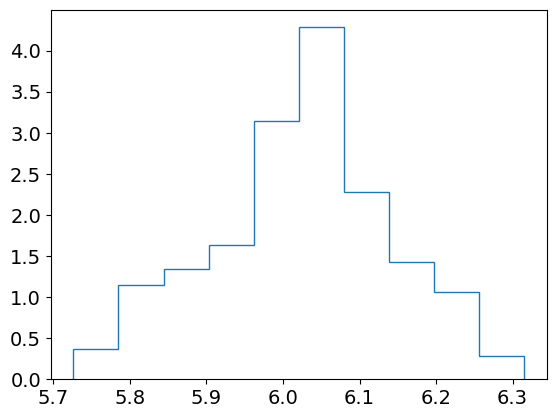

In [11]:
# This cell is to analyze what is happening with the second peak in the Total energy plot of subhalos between stellar mass 1e4 and 1e6
pscond_peak2 =  (5.60 < np.log10(np.abs(pste_f_ar))) & (np.log10(np.abs(pste_f_ar)) < 5.62) & np.isfinite(pspot_if_ar) & (psfof == 0) & (1e4 < psmstar_all) & (psmstar_all < 1e6)


# plt.hist(np.log10(psmstar_all[pscond_peak2]))

plt.hist(np.log10(np.abs(pspot_f_ar[pscond_peak2])), histtype = 'step', density = True, label = 'Near peak')
plt.hist(np.log10(np.abs(pspot_f_ar[pscond])), histtype = 'step', density = True, label = 'Full sample')
plt.legend()
# plt.hist(pske_if_ar[pscond_peak2], histtype = 'step')
plt.xlabel(r'$\log(PE_{\rm{z = 0}})$')

1 1 1
/bigdata/saleslab/psadh003/tng50/dwarf_formation/errani_plus_tng_subhalo.py:1326: RuntimeWarning: divide by zero encountered in log10
  subh_max_mstar = round(np.log10(max(subh_mstar)), 2)

/bigdata/saleslab/psadh003/tng50/dwarf_formation/errani_plus_tng_subhalo.py:1326: RuntimeWarning: invalid value encountered in rint
  subh_max_mstar = round(np.log10(max(subh_mstar)), 2)

/bigdata/saleslab/psadh003/tng50/dwarf_formation/errani_plus_tng_subhalo.py:1446: RuntimeWarning: divide by zero encountered in log10
  ax_sub2.plot(np.flip(subh_ages), np.flip(np.log10(totMstar)), 'b--', label = r'Stars in total')

/bigdata/saleslab/psadh003/tng50/dwarf_formation/errani_plus_tng_subhalo.py:1454: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax_sub3.set_yscale('log')



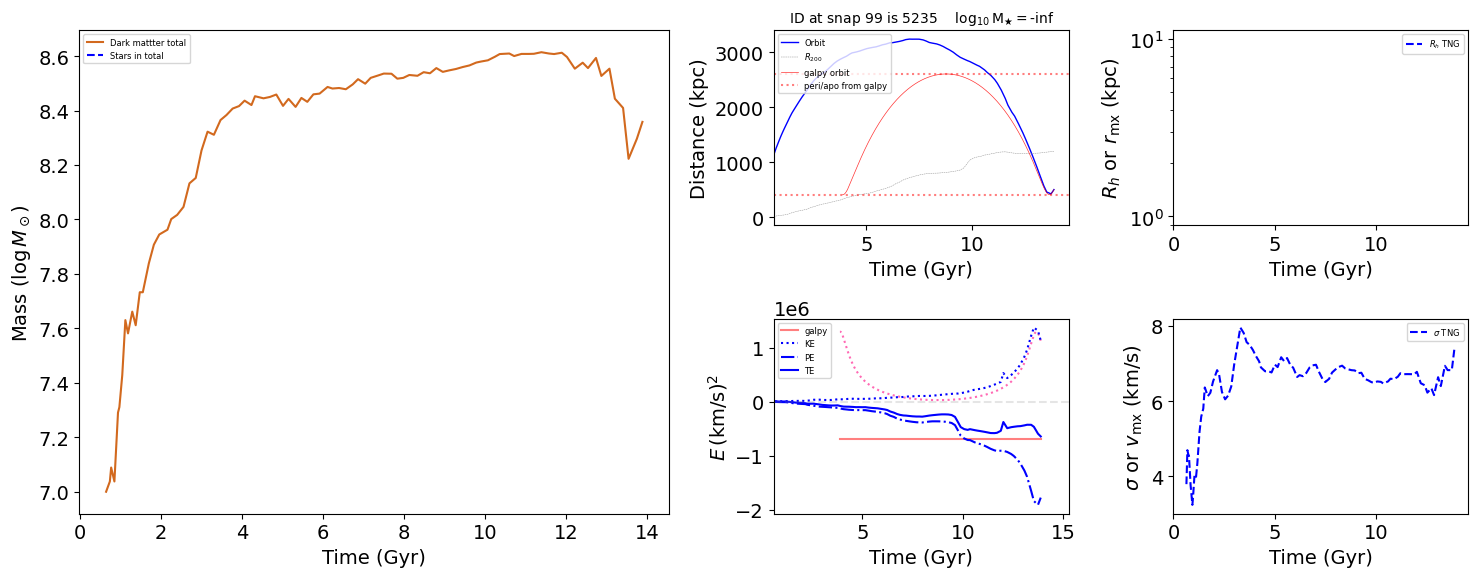

In [28]:
ix = 101
sh = Subhalo(snap = pssnap_if_ar[pscond_peak2][ix], sfid = pssf_id_if_ar[pscond_peak2][ix], last_snap = 99, central_sfid_99 = 0)
sh.plot_orbit_comprehensive(show = True)

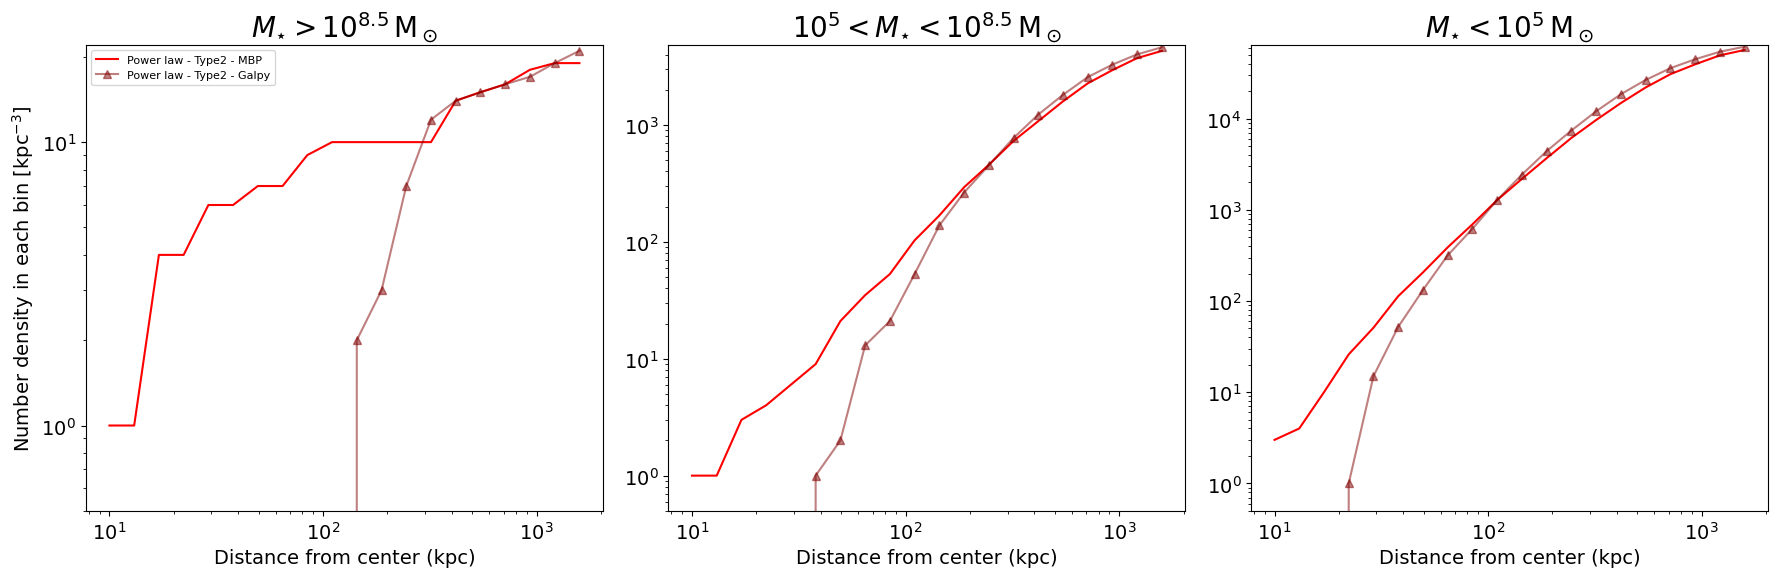

In [43]:
def plot_type2s():
    
    # fig, (axs, ax2) = plt.subplots(2, 3, figsize = (18, 12))
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        # pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar = np.zeros(0) #shmf for surviving subhalos 
        pNm_ar_gp = np.zeros(0)

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN2_ar = (pNm_ar ) / (pNm_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        pN2_ar_gp = (pNm_ar_gp ) / (pNm_ar_gp[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # pN2_ar = (pNm_ar ) / (pNm_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # pN_ar = (pNs_ar + pNm_ar ) / (pNs_ar[-1] + pNm_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pNm_ar, color = 'red', label = r'Power law - Type2 - MBP', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl2, pNm_ar_gp, '^-', color = 'maroon', label = r'Power law - Type2 - Galpy', lw  = 1.5, alpha = 0.5)
        # axs[jx].plot(rpl2, pN2_ar, color = 'red', label = r'Power law - Type2', lw  = 1.5, ls = '--')
        # axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        # axs[jx].plot(rpl2, cN_ar, color = 'darkgreen', label = r'Cutoff', lw = 1.5)

        # axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')

        #This part is for the 
        # if jx == 0:
        #     mstar_bins = np.linspace(8.5, 11, 5) #These are the bins into which we will bin the subhalos
        # elif jx == 1:
        #     mstar_bins = np.linspace(5, 8.5, 10)
        # elif jx == 2:
        #     mstar_bins = np.linspace(2, 5, 10)
        # mstar_pl = np.zeros(0) #This will be the midpoint of bin edges defined above
        # nsurv_bin = np.zeros(0)
        # nmerg_bin = np.zeros(0)
        # for i in range(len(mstar_bins) - 1):
        #     mstar_pl = np.append(mstar_pl, (mstar_bins[i] + mstar_bins[i + 1]) / 2)
        #     nsurv_bin = np.append(nsurv_bin, len(psmstar_all[(psmstar_all < 10**mstar_bins[i + 1]) & (psmstar_all >= 10**mstar_bins[i])]))
        #     nmerg_bin = np.append(nmerg_bin, len(pmmstar_all[(pmmstar_all < 10**mstar_bins[i + 1]) & (pmmstar_all >= 10**mstar_bins[i])]))
    
        # ax2[jx].plot(mstar_pl, nmerg_bin / (nsurv_bin + nmerg_bin), color = 'red', ls = '--')
        # # ax.plot(mstar_pl, nmerg_bin / nsurv_bin , color = 'gray')
        # ax2[jx].set_xlabel(r'$\log M_{\rm{star}}(M_\odot)$', fontsize = label_font)
        # # ax.set_ylabel(r'$f_{\rm{type2}}/f_{\rm{type1}}$', fontsize = label_font)
        # ax2[jx].set_ylabel(r'$f_{\rm{type2}}/(f_{\rm{type1}} + f_{\rm{type1}})$', fontsize = label_font)
        # ax2[jx].set_yscale('log')
        # ax2[jx].set_ylim(bottom = 0.04, top = 1)
        # ax2[jx].set_yticks([0.05, 0.1, 0.5, 1])
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
    return None

plot_type2s()

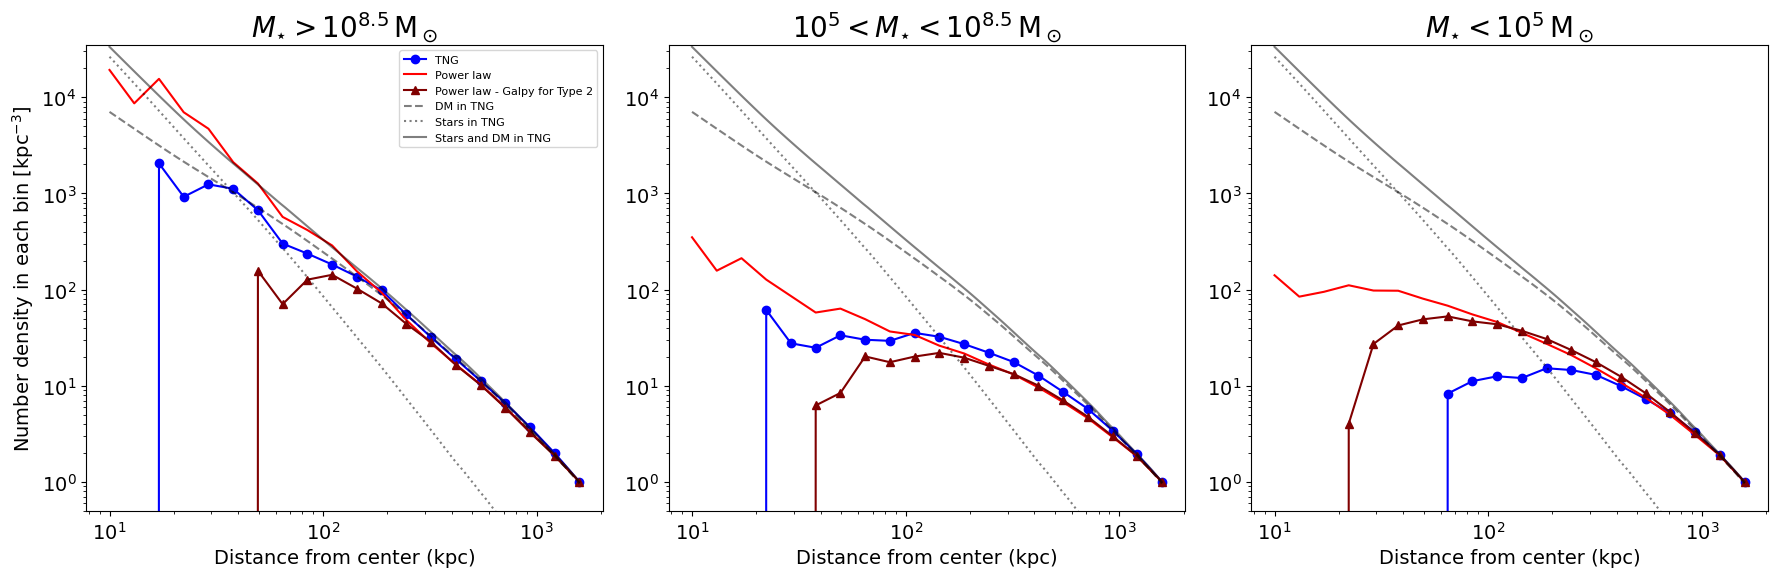

In [39]:

def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



This is normal


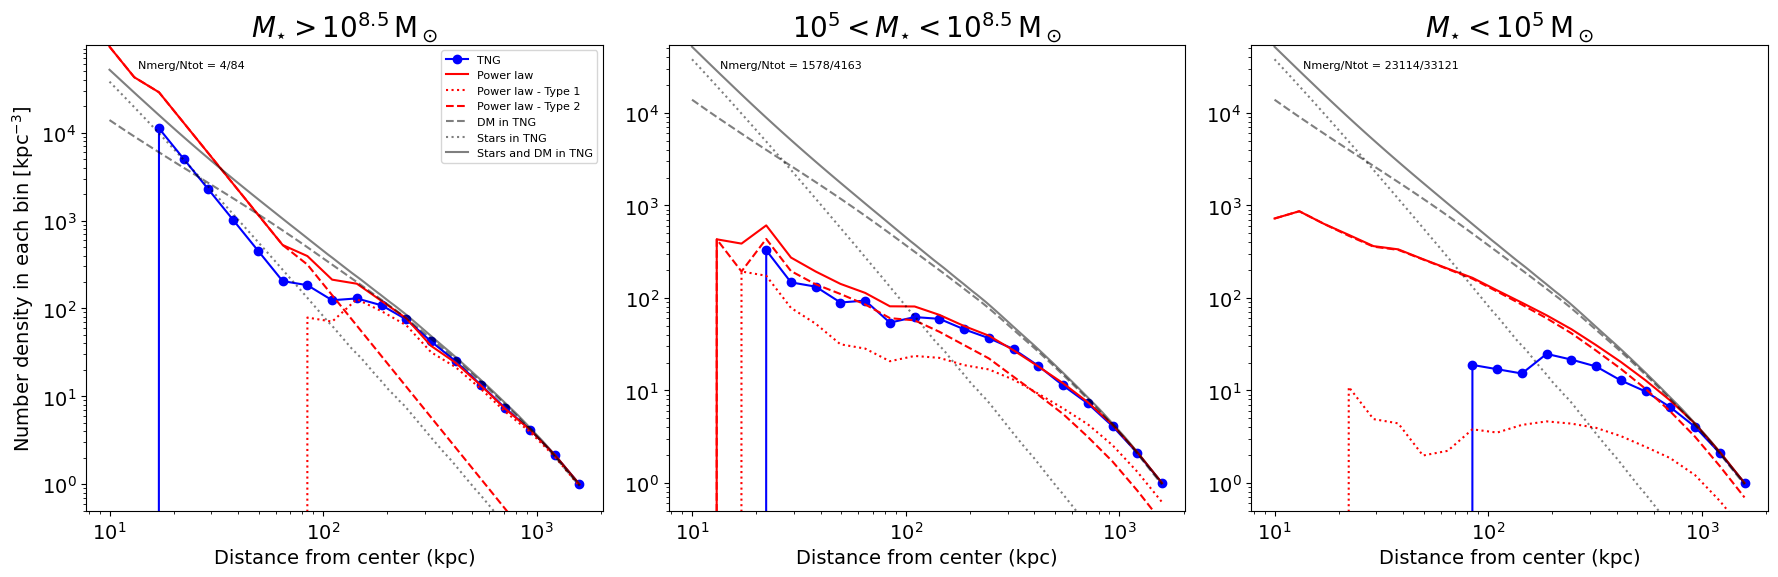

In [16]:
print('This is normal')
def plot_radial_density_dist_3panel(fofno = 0):
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    if fofno == 0:
        Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
        Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]
    elif fofno == 1:
        # elif fofno == 1:
        Ndm_ar =  [786023, 841839, 902134, 966380, 1035837, 1110113, 1189602, 1274186, 1364366, 1460423, 1562817, 1672316, 1788483, 1913425, 2046885, 2190148, 2343775, 2511901, 2690528, 2878121, 3078467, 3294791, 3528395, 3780942, 4053436, 4350232, 4685298, 5050150, 5416132, 5796879, 6199598, 6623522, 7072307, 7546453, 8050591, 8585909, 9153650, 9756524, 10397233, 11074877, 11795747, 12560524, 13376455, 14255740, 15217979, 16289952, 17349673, 18430107, 19555220, 20756630, 22010268, 23314416, 24673283, 26107659, 27631468, 29312494, 31108073, 32886889, 34739969, 36734573, 38844189, 41049934, 43382025, 45812785, 48395953, 51173751, 54141628, 57270029, 60739449, 64360174, 68074798, 71803090, 75817335, 80041042, 84373691, 89111485, 94087743, 99601105, 104804935, 109994769, 115260983, 121202017, 127487242, 133053679, 138547841, 144456102, 151341815, 158789550, 164815392, 169912646, 174986366, 179518933, 183635753, 187442091, 191210434, 194512610, 197453028, 199783883, 201489573, 202770641]
        Mstar_ar = [735365200000.0, 752437950000.0, 769758000000.0, 786811060000.0, 803612500000.0, 819888000000.0, 835624570000.0, 850837800000.0, 865607700000.0, 879804150000.0, 893492400000.0, 906636800000.0, 919314960000.0, 931422670000.0, 942965800000.0, 953885000000.0, 964442060000.0, 978516050000.0, 990955000000.0, 999915700000.0, 1008391160000.0, 1016919560000.0, 1025774060000.0, 1036594640000.0, 1047105040000.0, 1059257000000.0, 1096440500000.0, 1151949900000.0, 1165945200000.0, 1177803400000.0, 1188600200000.0, 1198653700000.0, 1208132700000.0, 1217186100000.0, 1225809000000.0, 1234269200000.0, 1242689600000.0, 1251252200000.0, 1259951800000.0, 1268457100000.0, 1279594100000.0, 1288064300000.0, 1296732400000.0, 1306350800000.0, 1320749400000.0, 1368368600000.0, 1382908300000.0, 1394449200000.0, 1403701300000.0, 1421870400000.0, 1442400400000.0, 1459726700000.0, 1469102700000.0, 1477989500000.0, 1487951800000.0, 1513011500000.0, 1560199000000.0, 1570833800000.0, 1579861900000.0, 1589710300000.0, 1600094000000.0, 1609801100000.0, 1621373700000.0, 1629216000000.0, 1637721200000.0, 1656113300000.0, 1669808800000.0, 1678819000000.0, 1717836000000.0, 1776533500000.0, 1813434300000.0, 1823228400000.0, 1850019700000.0, 1866819000000.0, 1877642600000.0, 1930809000000.0, 1948741300000.0, 2024119300000.0, 2043187400000.0, 2065576000000.0, 2079388200000.0, 2136806900000.0, 2310955000000.0, 2327082700000.0, 2336245700000.0, 2360786300000.0, 2592580000000.0, 2962172000000.0, 3038592400000.0, 3052858500000.0, 3091299600000.0, 3104512700000.0, 3113781600000.0, 3118984300000.0, 3128386000000.0, 3134713000000.0, 3149529400000.0, 3163836000000.0, 3166528300000.0, 3167405700000.0]
    elif fofno == 2:
        Ndm_ar =  [506233, 543093, 582765, 625491, 671876, 722219, 777025, 836818, 901297, 970418, 1045227, 1126104, 1213949, 1309191, 1412584, 1524440, 1646551, 1777799, 1919728, 2072632, 2238248, 2417271, 2609800, 2817277, 3040510, 3281139, 3539926, 3817121, 4114546, 4432843, 4774753, 5139467, 5529198, 5945510, 6389364, 6861022, 7362273, 7896148, 8464347, 9073994, 9720932, 10401647, 11120919, 11885151, 12702569, 13567823, 14490623, 15490151, 16538923, 17659839, 18860064, 20139640, 21539654, 23004408, 24521251, 26118857, 27830425, 29690401, 31594495, 33583623, 35826373, 38084587, 40355477, 42603051, 44893225, 47240038, 49634641, 52131364, 54785123, 57566214, 60516069, 63630213, 66872280, 70032466, 73281595, 76559042, 79927775, 83271713, 86831349, 90335048, 93936908, 97529383, 101157411, 104732133, 108474590, 112510285, 116254382, 119352925, 122309945, 125330731, 128093855, 130971259, 133082588, 134592107, 135760830, 136423222, 136980286, 137712615, 138772681, 139954151]
        Mstar_ar = [622662400000.0, 639497900000.0, 656542900000.0, 673426200000.0, 690282760000.0, 707070850000.0, 723851700000.0, 741311400000.0, 758308100000.0, 774903000000.0, 791605700000.0, 808453400000.0, 825326700000.0, 842186600000.0, 858899000000.0, 875651200000.0, 892487200000.0, 909312900000.0, 925979840000.0, 942497300000.0, 959143700000.0, 975685350000.0, 992122900000.0, 1008428060000.0, 1024638000000.0, 1040602400000.0, 1056423740000.0, 1072317700000.0, 1088107640000.0, 1103894700000.0, 1119753900000.0, 1135668600000.0, 1151600600000.0, 1167671600000.0, 1184450500000.0, 1200219200000.0, 1215191000000.0, 1229984400000.0, 1244911900000.0, 1262749500000.0, 1279555500000.0, 1293580600000.0, 1306877000000.0, 1320081200000.0, 1332942500000.0, 1345256000000.0, 1357349500000.0, 1396579400000.0, 1409477200000.0, 1421382400000.0, 1434160100000.0, 1447370200000.0, 1486111800000.0, 1535126900000.0, 1546642500000.0, 1557432000000.0, 1571283800000.0, 1603248600000.0, 1616894800000.0, 1629796600000.0, 1693108300000.0, 1717380700000.0, 1780294600000.0, 1798316800000.0, 1806969000000.0, 1815239100000.0, 1824022600000.0, 1831566700000.0, 1840028700000.0, 1857419100000.0, 1873263900000.0, 1902653300000.0, 1939510400000.0, 1945850900000.0, 1952548900000.0, 1957783400000.0, 1971799000000.0, 1977263200000.0, 2014859800000.0, 2021033200000.0, 2033235000000.0, 2037815700000.0, 2059557500000.0, 2070316000000.0, 2093917300000.0, 2134067600000.0, 2198085600000.0, 2203074200000.0, 2214773400000.0, 2232973800000.0, 2254086000000.0, 2357980800000.0, 2370230600000.0, 2373513600000.0, 2384293500000.0, 2384670800000.0, 2385031500000.0, 2385912800000.0, 2392934600000.0, 2395122400000.0]


    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        # fofno = 1
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == fofno)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == fofno)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == fofno)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs) & (psfof == fofno)]))

        
        axs[jx].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(pNm_ar[-1])) + '/' + str(int(pNs_ar[-1] + pNm_ar[-1])), transform=axs[jx].transAxes, fontsize = 8)
        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel(2)



This is with application of a cut in the total energy such that log(TE) > 5.75


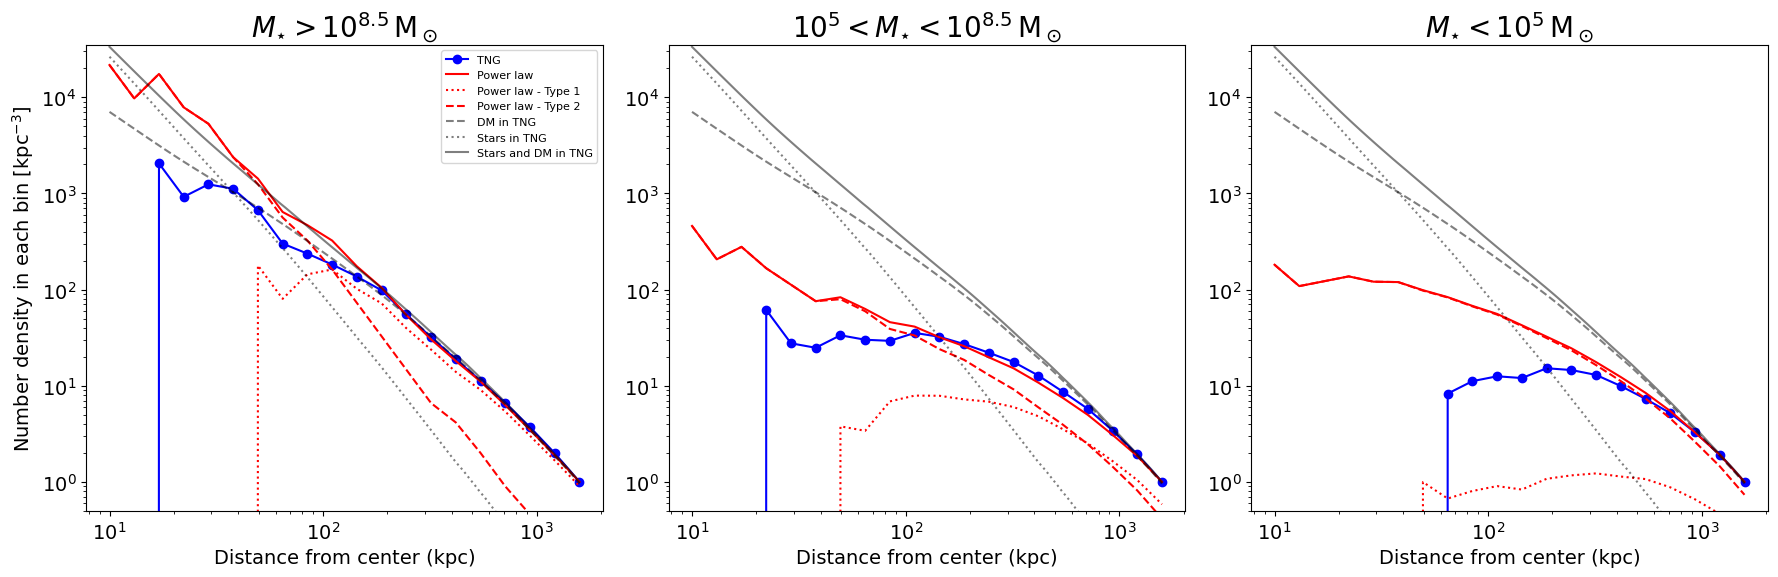

In [64]:
print('This is with application of a cut in the total energy such that log(TE) > 5.75')


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0) & (np.log10(np.abs(pmte_f_ar)) > 5.75)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0) & (np.log10(np.abs(pste_f_ar)) > 5.75)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



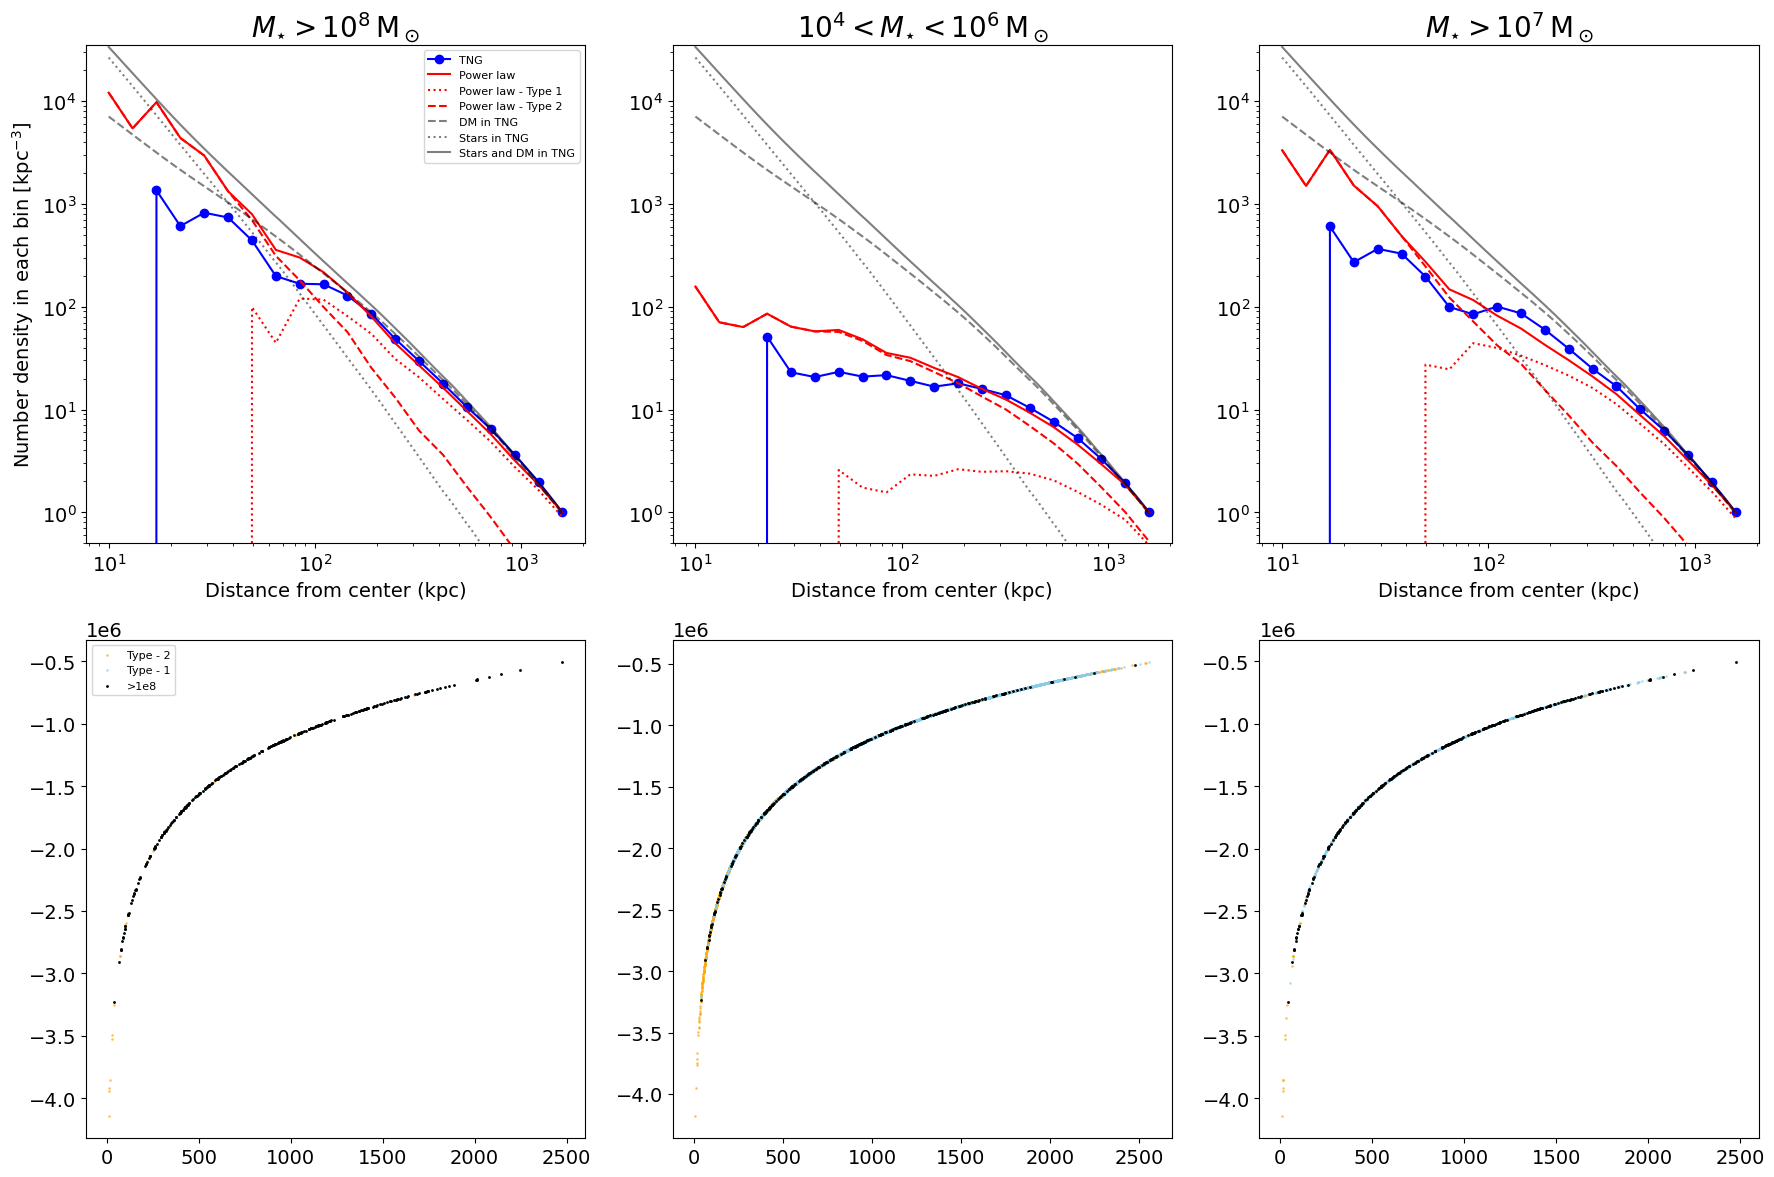

In [48]:
# This is to check when we have ruining


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, (axs, ax2) = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    

    

    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        

        if jx == 0:
            mplcutoff = 10**8
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**4
            mmaxcutoff = 10**6
            axs[jx].set_title(r'$10^{4} < M_{\star} < 10^{6}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**7
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{7}\,\rm{M_\odot}$', fontsize = label_font)
        s = 1
        alpha = 0.5
        ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0) ]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



This is to print in bins


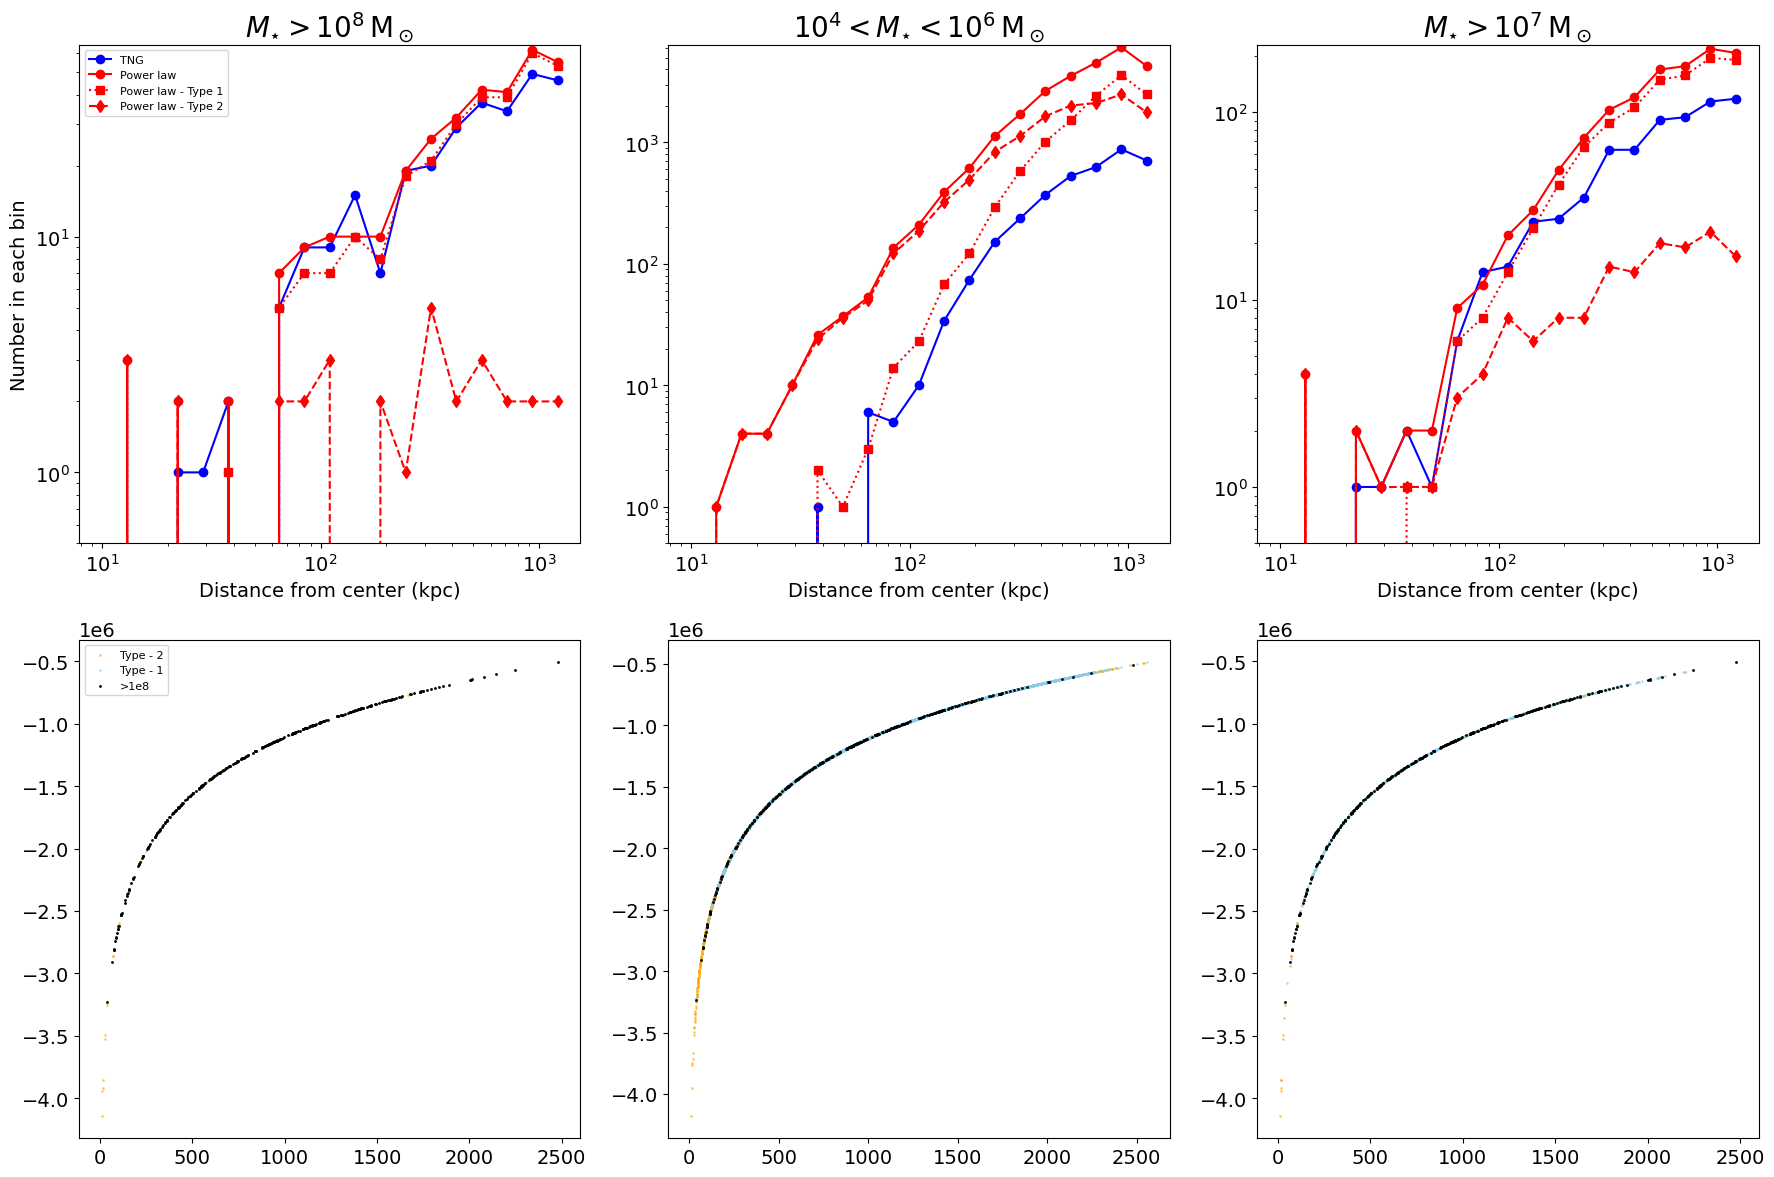

In [56]:
print('This is to print in bins')


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, (axs, ax2) = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    

    

    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        

        if jx == 0:
            mplcutoff = 10**8
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**4
            mmaxcutoff = 10**6
            axs[jx].set_title(r'$10^{4} < M_{\star} < 10^{6}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**7
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{7}\,\rm{M_\odot}$', fontsize = label_font)
        s = 1
        alpha = 0.5
        ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2[:-1]): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar > rs) & (pmdist_f_ar < rpl2[ix + 1]) & (pmfof == 0)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar > rs) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar > rs) & (psdist_f_ar < rpl2[ix + 1]) & (psfof == 0)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar > rs) & (psdist_f_ar < rpl2[ix + 1])& (psfof == 0)]))

        

        
        Ntng_ar = Ntng_ar
        pN_ar = (pNs_ar + pNm_ar) 
        pN_ar_gp = (pNs_ar + pNm_ar_gp) 
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2[:-1], Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2[:-1], pN_ar, 'ro-', label = r'Power law')
        axs[jx].plot(rpl2[:-1], pNs_ar, 'rs:', label = r'Power law - Type 1')
        axs[jx].plot(rpl2[:-1], pNm_ar, 'rd--', label = r'Power law - Type 2')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        # axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number in each bin')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



This is for plotting in bins of infall time


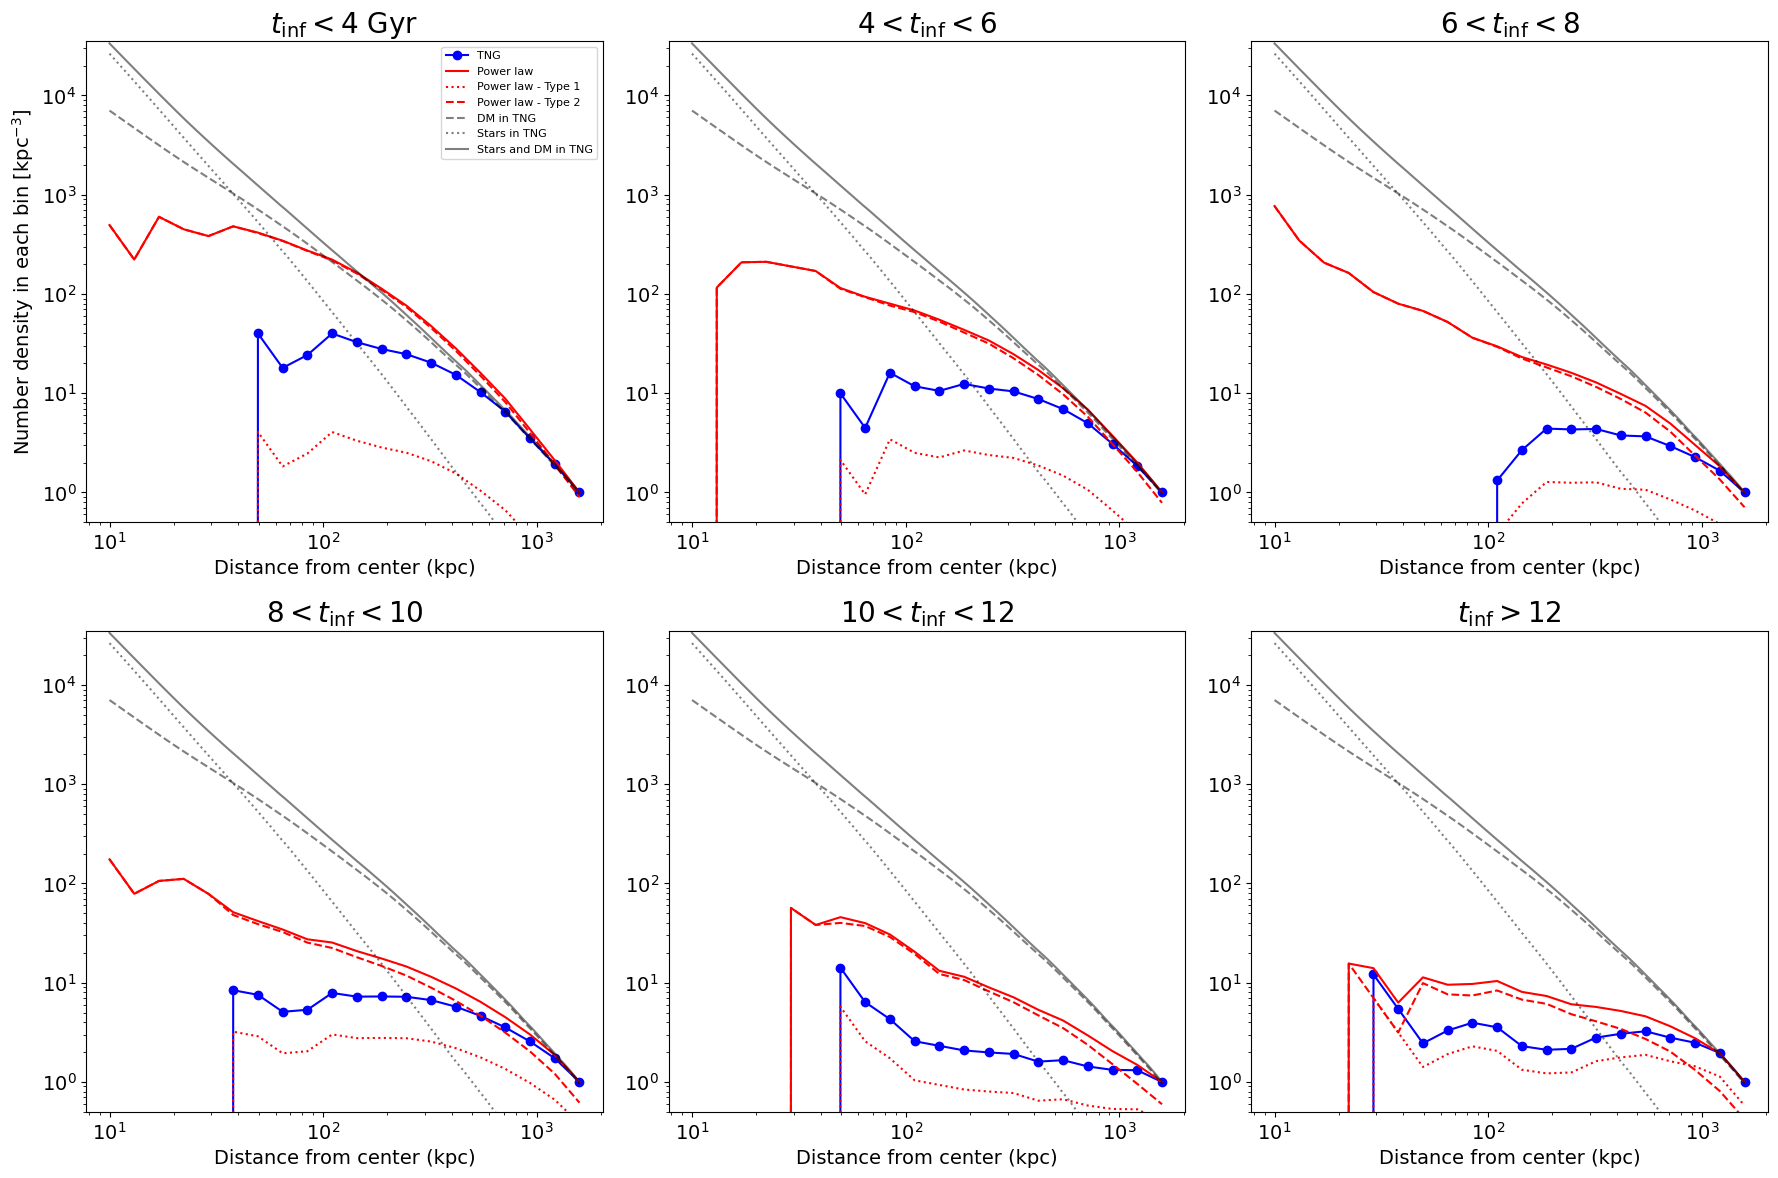

In [63]:
print('This is for plotting in bins of infall time')


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    

    

    for jx in range(6):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        i = int(jx/3)
        j = jx % 3

        if jx == 0:
            tinfcutoff = 0
            tinfmaxcutoff = 4
            axs[i][j].set_title(r'$ t_{\rm{inf}} < 4$ Gyr', fontsize = label_font)
        elif jx == 1:
            tinfcutoff = 4
            tinfmaxcutoff = 6
            axs[i][j].set_title(r'$4 < t_{\rm{inf}} < 6$', fontsize = label_font)
        elif jx ==2:
            tinfcutoff = 6
            tinfmaxcutoff = 8
            axs[i][j].set_title(r'$6 < t_{\rm{inf}} < 8$', fontsize = label_font)
        elif jx ==3:
            tinfcutoff = 8
            tinfmaxcutoff = 10
            axs[i][j].set_title(r'$8 < t_{\rm{inf}} < 10$', fontsize = label_font)
        elif jx ==4:
            tinfcutoff = 10
            tinfmaxcutoff = 12
            axs[i][j].set_title(r'$10 < t_{\rm{inf}} < 12$', fontsize = label_font)
        elif jx ==5:
            tinfcutoff = 12
            tinfmaxcutoff = 14
            axs[i][j].set_title(r'$t_{\rm{inf}} > 12$', fontsize = label_font)
        # s = 1
        # alpha = 0.5
        # ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        # if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmtinf_ar > tinfcutoff) & (pmtinf_ar < tinfmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            # pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(pstinf_ar > tinfcutoff) & (pstinf_ar < tinfmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0) ]))
            # print(pNm_ar, pNs_ar)
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(pstinf_ar > tinfcutoff) & (pstinf_ar < tinfmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[i][j].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[i][j].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[i][j].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[i][j].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[i][j].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[i][j].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[i][j].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[i][j].legend(fontsize = 8)
            axs[i][j].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[i][j].set_xlabel('Distance from center (kpc)')
        axs[i][j].set_ylim(bottom = 0.5)
        
        axs[i][j].set_xscale('log')
        axs[i][j].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



In [10]:
# pmmpeak_ar

array([1.11929243e+10, 2.26691845e+10, 1.70266026e+10, ...,
                  nan,            nan,            nan])

This is for checking in bins of Mpeak


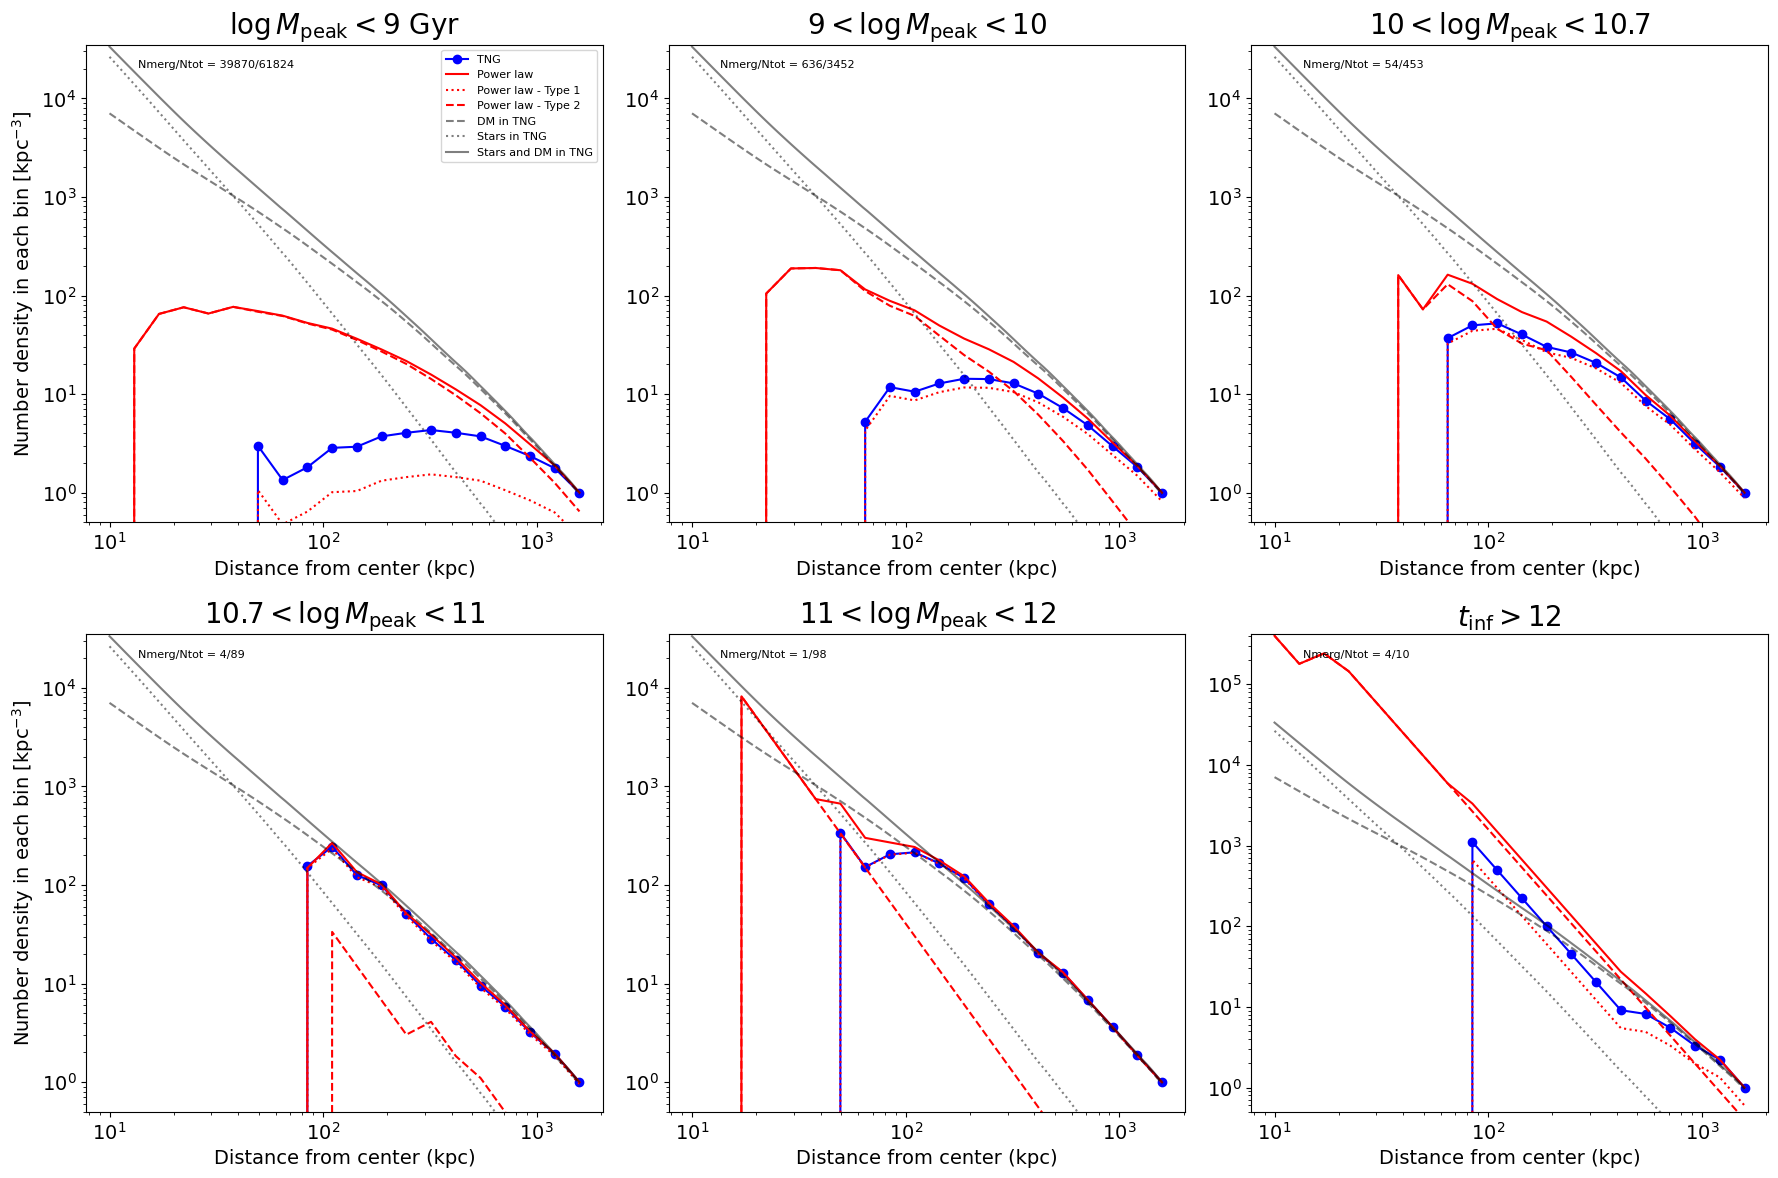

In [15]:
print('This is for checking in bins of Mpeak')

def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    

    

    for jx in range(6):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        i = int(jx/3)
        j = jx % 3

        if jx == 0:
            mpeakcutoff = 1e0
            mpeakmaxcutoff = 1e9
            axs[i][j].set_title(r'$ \log M_{\rm{peak}} < 9$ Gyr', fontsize = label_font)
        elif jx == 1:
            mpeakcutoff = 1e9
            mpeakmaxcutoff = 1e10
            axs[i][j].set_title(r'$9 < \log M_{\rm{peak}} < 10$', fontsize = label_font)
        elif jx ==2:
            mpeakcutoff = 1e10
            mpeakmaxcutoff = 5e10
            axs[i][j].set_title(r'$10 < \log M_{\rm{peak}} < 10.7$', fontsize = label_font)
        elif jx ==3:
            mpeakcutoff = 5e10
            mpeakmaxcutoff = 1e11
            axs[i][j].set_title(r'$10.7 < \log M_{\rm{peak}} < 11$', fontsize = label_font)
        elif jx ==4:
            mpeakcutoff = 1e11
            mpeakmaxcutoff = 1e12
            axs[i][j].set_title(r'$11 < \log M_{\rm{peak}} < 12$', fontsize = label_font)
        elif jx ==5:
            mpeakcutoff = 1e12
            mpeakmaxcutoff = 1e20
            axs[i][j].set_title(r'$t_{\rm{inf}} > 12$', fontsize = label_font)
        # s = 1
        # alpha = 0.5
        # ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        # if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmpeak_ar > mpeakcutoff) & (pmmpeak_ar < mpeakmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            # pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmpeak_ar > mpeakcutoff) & (psmpeak_ar < mpeakmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0) ]))
            # print(pNm_ar, pNs_ar)
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmpeak_ar > mpeakcutoff) & (psmpeak_ar < mpeakmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))

        
        # print(pNs_ar[-1] + pNm_ar[-1])
        # print(pNs_ar[-1])
        # print(pNm_ar[-1])
        axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(pNm_ar[-1])) + '/' + str(int(pNs_ar[-1] + pNm_ar[-1])), transform=axs[i][j].transAxes, fontsize = 8)
        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[i][j].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[i][j].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[i][j].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[i][j].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[i][j].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[i][j].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[i][j].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx % 3 == 0:
            if jx == 0: axs[i][j].legend(fontsize = 8)
            axs[i][j].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[i][j].set_xlabel('Distance from center (kpc)')
        axs[i][j].set_ylim(bottom = 0.5)
        
        axs[i][j].set_xscale('log')
        axs[i][j].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



In [22]:
frem = pmmmx_f_ar/pmmmx_if_ar
fcond = (frem < 0.1) & (pmmstar_f_ar > 1e8)
pmmstar_f_ar[fcond]/pmmstar_max_all[fcond]

/tmp/ipykernel_2885673/1583339865.py:1: RuntimeWarning: invalid value encountered in divide
  frem = pmmmx_f_ar/pmmmx_if_ar



array([0.35669105, 0.15774783, 0.33477396, 0.13165659, 0.39752558,
       0.04786817, 0.33002953, 0.38852209, 0.14651573, 0.58814343,
       0.62274816])

This is checking in bins of Mmx jff


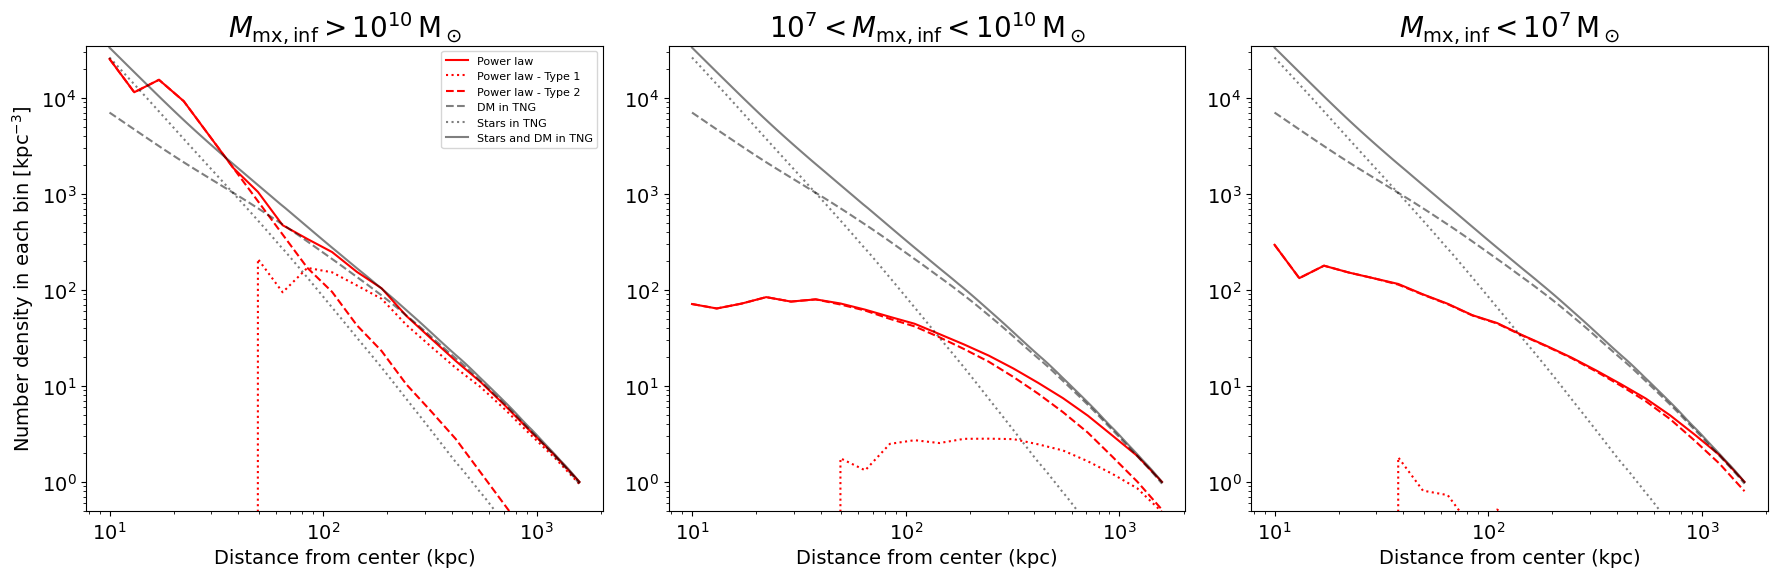

In [70]:
print('This is checking in bins of Mmx jff')

def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**10
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\rm{mx, inf}} > 10^{10}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**7
            mmaxcutoff = 10**10
            axs[jx].set_title(r'$10^{7} < M_{\rm{mx, inf}} < 10^{10}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**7
            axs[jx].set_title(r'$M_{\rm{mx, inf}} < 10^{7}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmmx_if_ar > mplcutoff) & (pmmmx_if_ar < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            # pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmmx_f_ar > mplcutoff) & (pmmmx_f_ar < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmmx_if_ar > mplcutoff) & (psmmx_if_ar < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmmx_if_ar > mplcutoff) & (psmmx_if_ar < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pNs_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



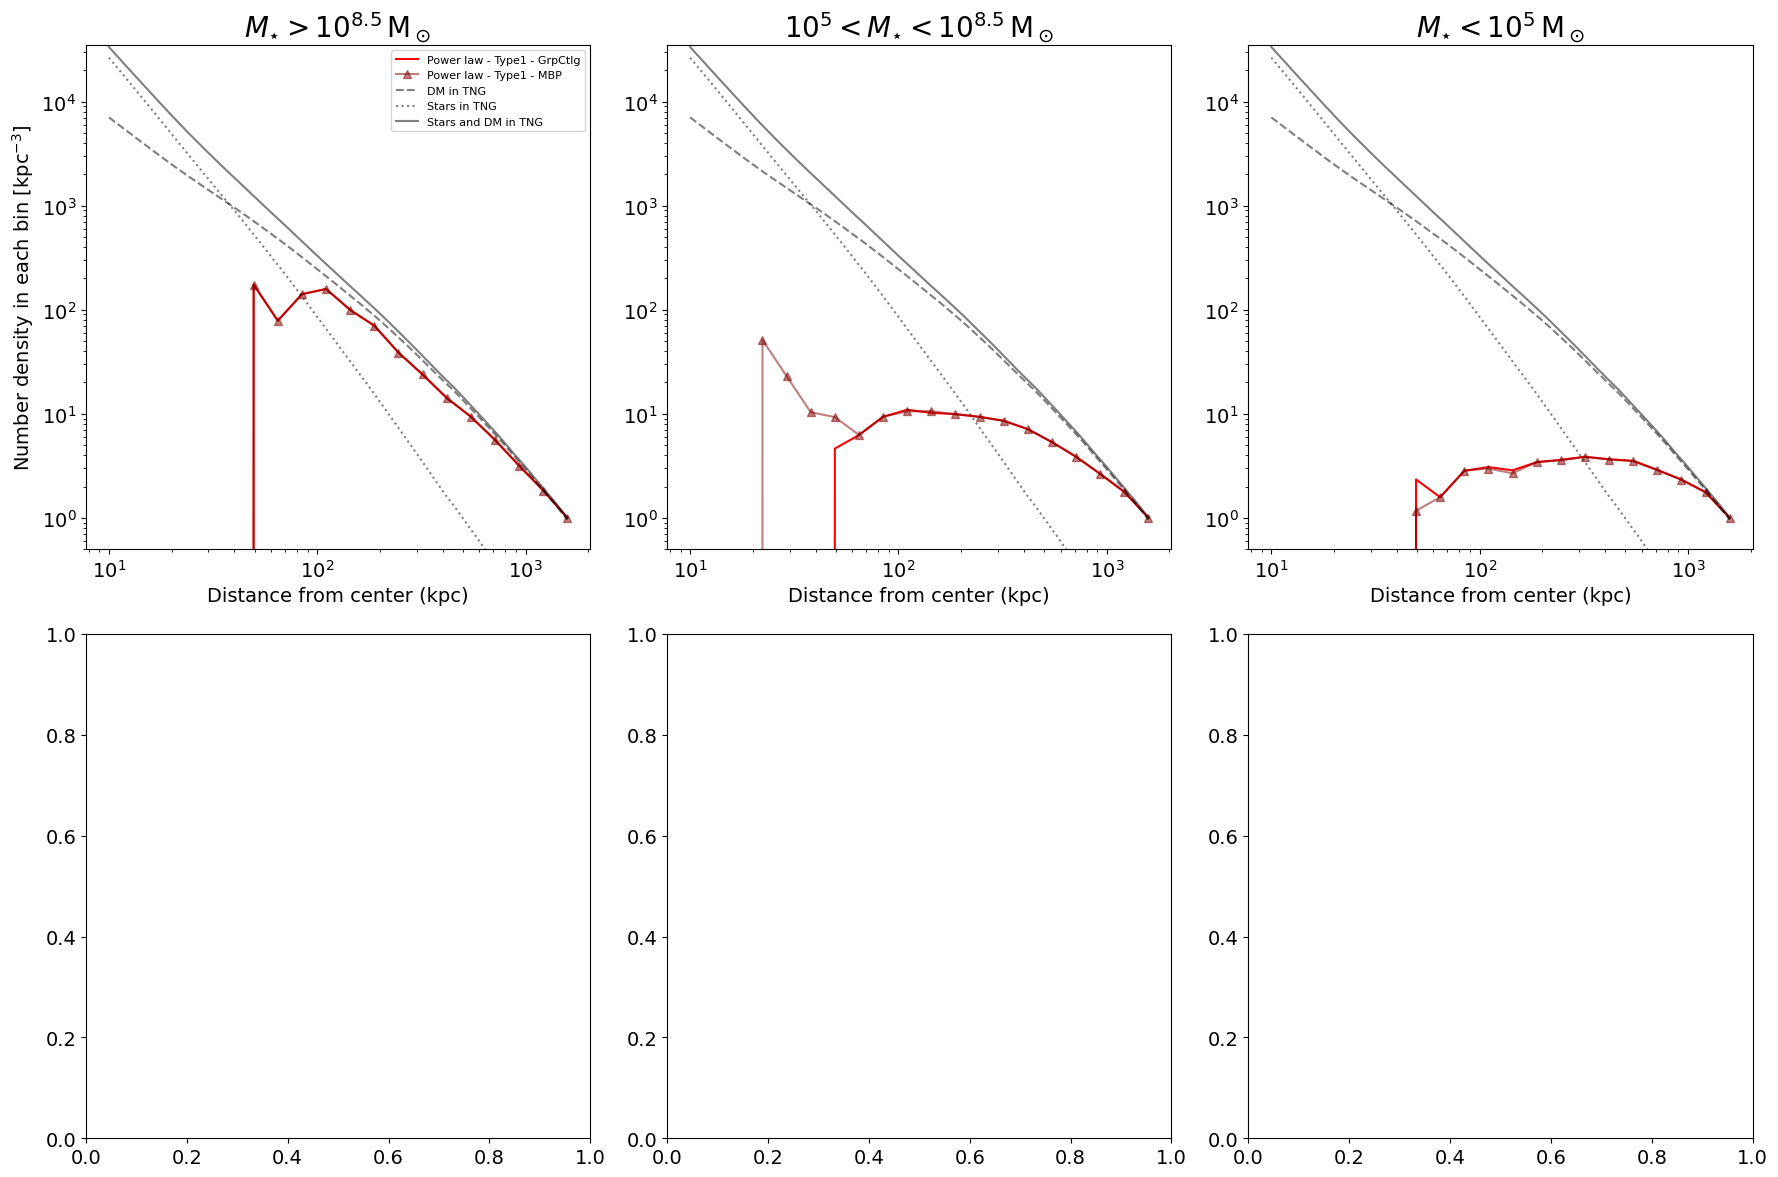

In [23]:

def plot_type1s():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, (axs, ax2) = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        # pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs_ar_mbp = np.zeros(0)

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))
            pNs_ar_mbp = np.append(pNs_ar_mbp, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psmbp_dist_f_ar < rs) & (psfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN1_ar = (pNs_ar ) / (pNs_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        pN1_ar_mbp = (pNs_ar_mbp ) / (pNs_ar_mbp[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # pN2_ar = (pNm_ar ) / (pNm_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # pN_ar = (pNs_ar + pNm_ar ) / (pNs_ar[-1] + pNm_ar[-1] ) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN1_ar, color = 'red', label = r'Power law - Type1 - GrpCtlg', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl2, pN1_ar_mbp, '^-', color = 'maroon', label = r'Power law - Type1 - MBP', lw  = 1.5, alpha = 0.5)
        # axs[jx].plot(rpl2, pN2_ar, color = 'red', label = r'Power law - Type2', lw  = 1.5, ls = '--')
        # axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        # axs[jx].plot(rpl2, cN_ar, color = 'darkgreen', label = r'Cutoff', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')

        #This part is for the 
        # if jx == 0:
        #     mstar_bins = np.linspace(8.5, 11, 5) #These are the bins into which we will bin the subhalos
        # elif jx == 1:
        #     mstar_bins = np.linspace(5, 8.5, 10)
        # elif jx == 2:
        #     mstar_bins = np.linspace(2, 5, 10)
        # mstar_pl = np.zeros(0) #This will be the midpoint of bin edges defined above
        # nsurv_bin = np.zeros(0)
        # nmerg_bin = np.zeros(0)
        # for i in range(len(mstar_bins) - 1):
        #     mstar_pl = np.append(mstar_pl, (mstar_bins[i] + mstar_bins[i + 1]) / 2)
        #     nsurv_bin = np.append(nsurv_bin, len(psmstar_all[(psmstar_all < 10**mstar_bins[i + 1]) & (psmstar_all >= 10**mstar_bins[i])]))
        #     nmerg_bin = np.append(nmerg_bin, len(pmmstar_all[(pmmstar_all < 10**mstar_bins[i + 1]) & (pmmstar_all >= 10**mstar_bins[i])]))
    
        # ax2[jx].plot(mstar_pl, nmerg_bin / (nsurv_bin + nmerg_bin), color = 'red', ls = '--')
        # # ax.plot(mstar_pl, nmerg_bin / nsurv_bin , color = 'gray')
        # ax2[jx].set_xlabel(r'$\log M_{\rm{star}}(M_\odot)$', fontsize = label_font)
        # # ax.set_ylabel(r'$f_{\rm{type2}}/f_{\rm{type1}}$', fontsize = label_font)
        # ax2[jx].set_ylabel(r'$f_{\rm{type2}}/(f_{\rm{type1}} + f_{\rm{type1}})$', fontsize = label_font)
        # ax2[jx].set_yscale('log')
        # ax2[jx].set_ylim(bottom = 0.04, top = 1)
        # ax2[jx].set_yticks([0.05, 0.1, 0.5, 1])
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_type1s()


/tmp/ipykernel_1535001/2997005081.py:22: RuntimeWarning: invalid value encountered in divide
  ax.plot(mstar_pl, (nms_bin) / (nmerg_bin), 'k--', label = 'Type 2')


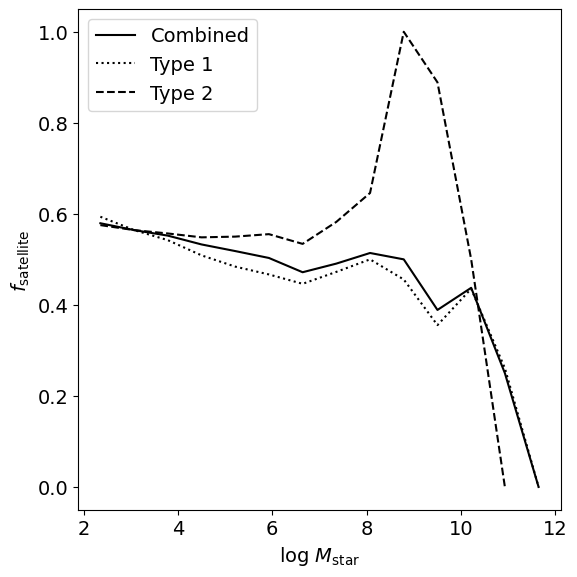

In [142]:
# This cell is to plot the satellite fraction as a function of stellar mass

mstar_bins = np.linspace(2, 12, 15)
mstar_pl = np.zeros(0) #This will be the midpoint of bin edges defined above
nsurv_bin = np.zeros(0)
nmerg_bin = np.zeros(0)
nss_bin = np.zeros(0)
nms_bin = np.zeros(0)

tmin = 0

for i in range(len(mstar_bins) - 1):
    mstar_pl = np.append(mstar_pl, (mstar_bins[i] + mstar_bins[i + 1]) / 2)
    nss_bin = np.append(nss_bin, len(psmstar_all[(psmstar_all < 10**mstar_bins[i + 1]) & (psmstar_all >= 10**mstar_bins[i]) & (psgr_sat == 1) & (pstinf_ar > tmin)]))
    nms_bin = np.append(nms_bin, len(pmmstar_all[(pmmstar_all < 10**mstar_bins[i + 1]) & (pmmstar_all >= 10**mstar_bins[i]) & (pmgr_sat == 1) & (pmtinf_ar > tmin)]) )
    nmerg_bin = np.append(nmerg_bin, len(pmmstar_all[(pmmstar_all < 10**mstar_bins[i + 1]) & (pmmstar_all >= 10**mstar_bins[i]) & (pmtinf_ar > tmin)]))
    nsurv_bin = np.append(nsurv_bin, len(psmstar_all[(psmstar_all < 10**mstar_bins[i + 1]) & (psmstar_all >= 10**mstar_bins[i]) & (pstinf_ar > tmin)]))

fig, ax = plt.subplots(figsize = (6, 6))
ax.plot(mstar_pl, (nss_bin + nms_bin) / (nmerg_bin + nsurv_bin), 'k-', label = 'Combined')
ax.plot(mstar_pl, (nss_bin) / (nsurv_bin), 'k:', label = 'Type 1')
ax.plot(mstar_pl, (nms_bin) / (nmerg_bin), 'k--', label = 'Type 2')
ax.set_xlabel(r'log $M_{\rm{star}}$')
ax.set_ylabel(r'$f_{\rm{satellite}}$')
ax.legend()
# ax.set_title('Infall after z = 2')
# ax.set_yscale('log')
plt.tight_layout()


/tmp/ipykernel_1535001/2530308864.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(mstar_pl, nmerg_bin/(nsurv_bin + nmerg_bin))


Text(0, 0.5, '$f_{type2}$')

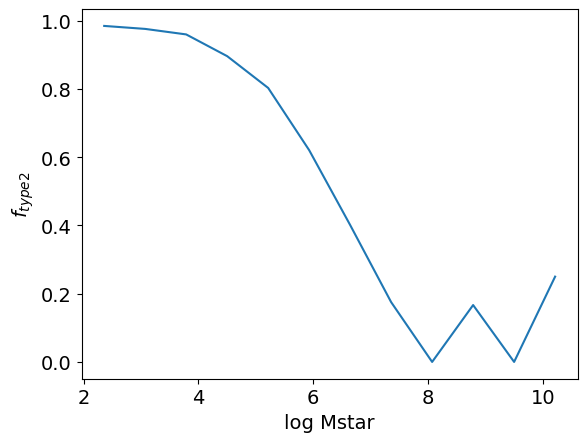

In [141]:
plt.plot(mstar_pl, nmerg_bin/(nsurv_bin + nmerg_bin))
plt.xlabel('log Mstar')
plt.ylabel(r'$f_{type2}$')

In [15]:
len(psmstar_all[(psgr_sat == 1)])/len(psmstar_all), len(pmmstar_all[(pmgr_sat == 1)])/len(pmmstar_all) 

(0.5357417055113792, 0.5633102741480912)

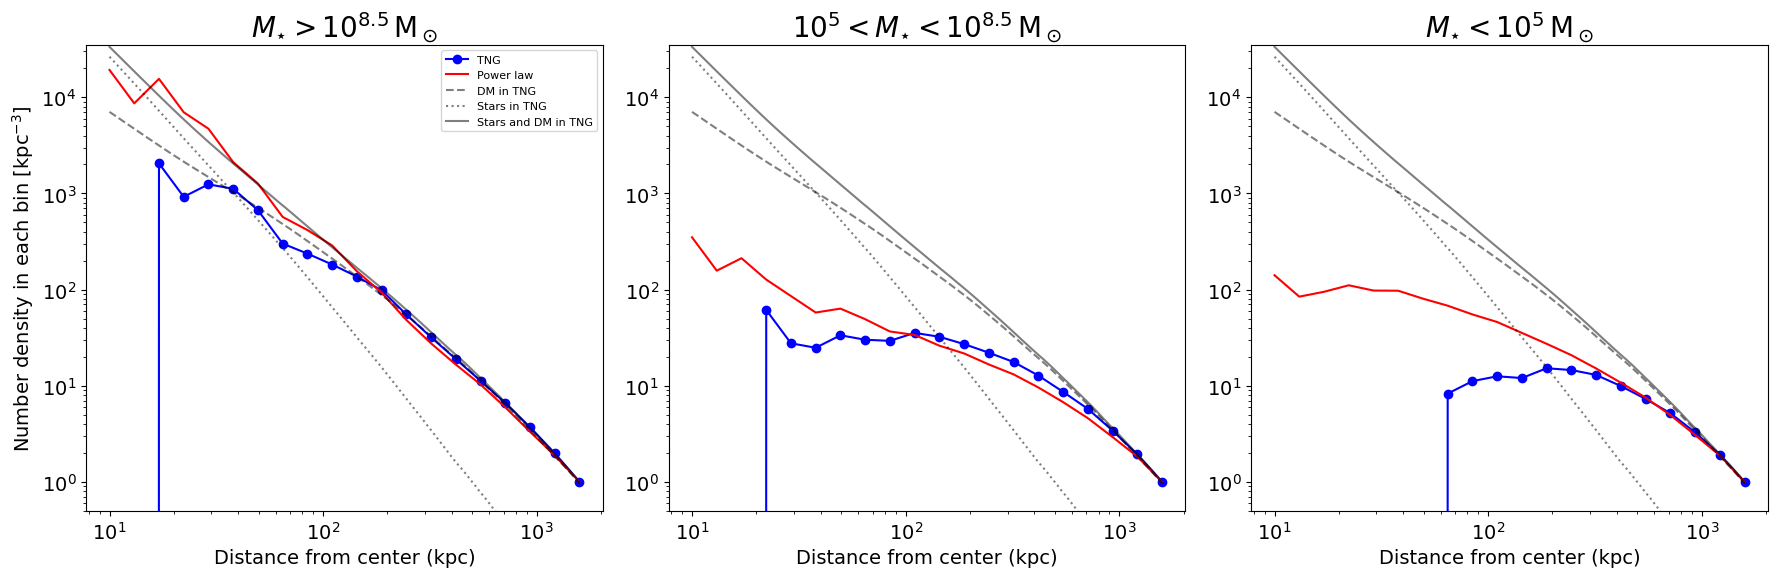

In [30]:
def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psfof == 0)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs)]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        # axs[jx].plot(rpl2, cN_ar, color = 'darkgreen', label = r'Cutoff', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()


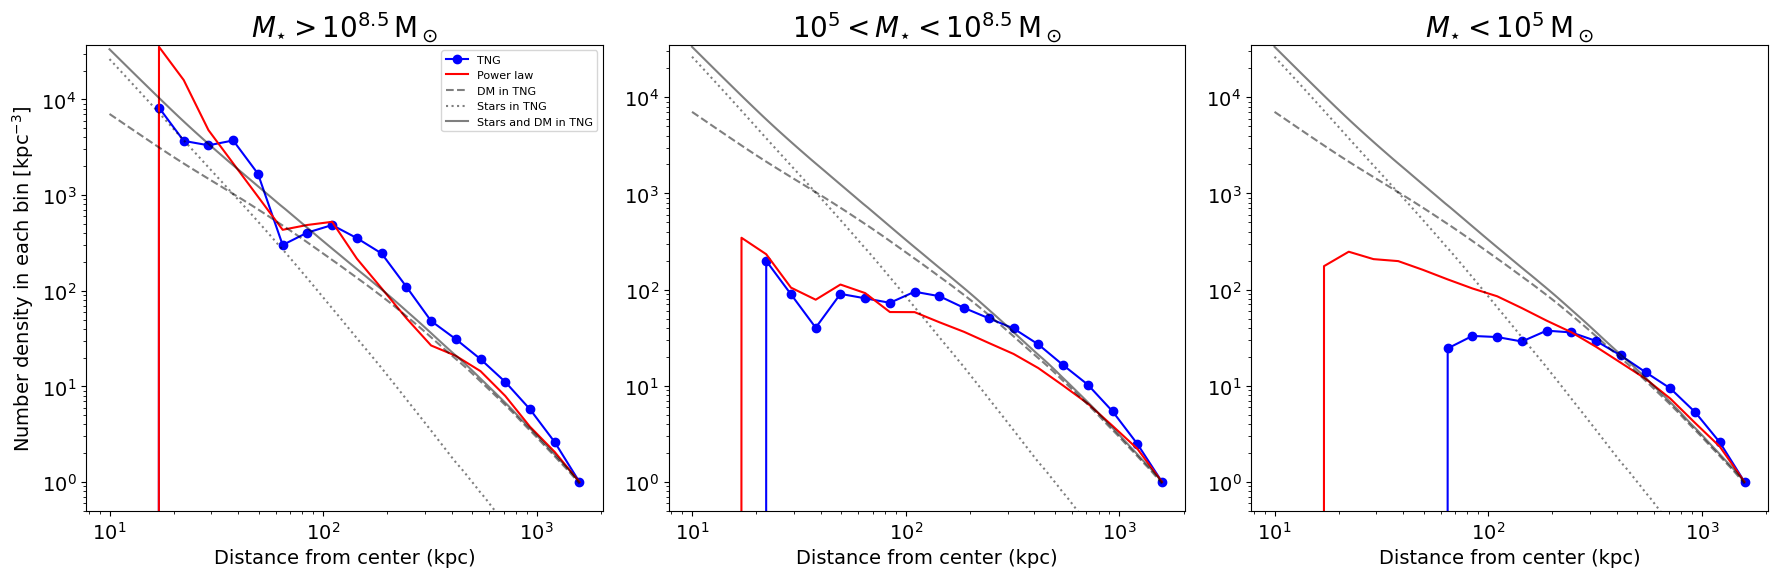

In [28]:
# Starting this cell to check the kinertic energy distribution as a function of radius 


def plot_radial_dens_perbin_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmdist_f_ar > rpl2[ix - 1]) & (pmfof == 0)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psdist_f_ar > rpl2[ix - 1]) & (psfof == 0)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs) & (psdist_f_ar > rpl2[ix - 1])]))

        

        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2[1:]**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2[1:]**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        axs[jx].plot(rpl2[1:], Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2[1:], pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        # axs[jx].plot(rpl2, cN_ar, color = 'darkgreen', label = r'Cutoff', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_dens_perbin_3panel()


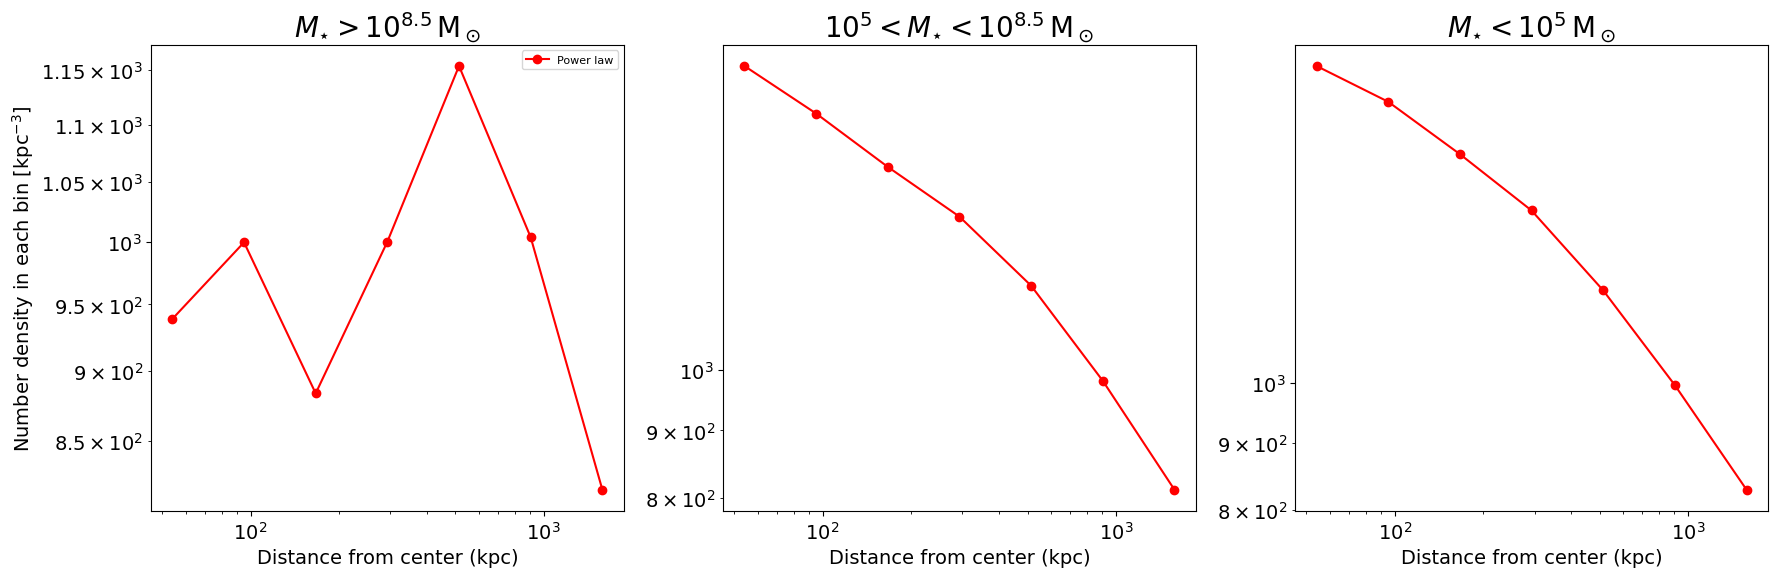

In [43]:
# Starting this cell to check the kinertic energy distribution as a function of radius 


def plot_radial_ke_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 3, figsize = (18, 6))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(3):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        # cNm_ar = np.zeros(0) #shmf for merged subhalos
        # cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 10**8.5
            mmaxcutoff = 10**15
            axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 10**1
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 10)
        for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, np.mean(np.linalg.norm(pmvel_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmdist_f_ar < rs) & (pmdist_f_ar > rpl2[ix - 1]) & (pmfof == 0)], axis = 1)))
            pNs_ar = np.append(pNs_ar, np.mean(np.linalg.norm(psvel_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psdist_f_ar > rpl2[ix - 1]) & (psfof == 0)], axis = 1)))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            # Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psdist_f_ar < rs) & (psdist_f_ar > rpl2[ix - 1])]))

        

        
        # Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2[1:]**3)
        # pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2[1:]**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar)/2

        # axs[jx].plot(rpl2[1:], Ntng_ar, 'bo-', label = r'TNG')
        axs[jx].plot(rpl2[1:], pN_ar, 'ro-', label = r'Power law', lw  = 1.5)
        # axs[jx].plot(rpl2, cN_ar, color = 'darkgreen', label = r'Cutoff', lw = 1.5)

        # axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        # axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0:
            axs[jx].legend(fontsize = 8)
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        # axs[jx].set_ylim(bottom = 0.5)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_ke_3panel()


This is to make the Figure 3 from Wang et al 2012 -- The distribution of Vmx


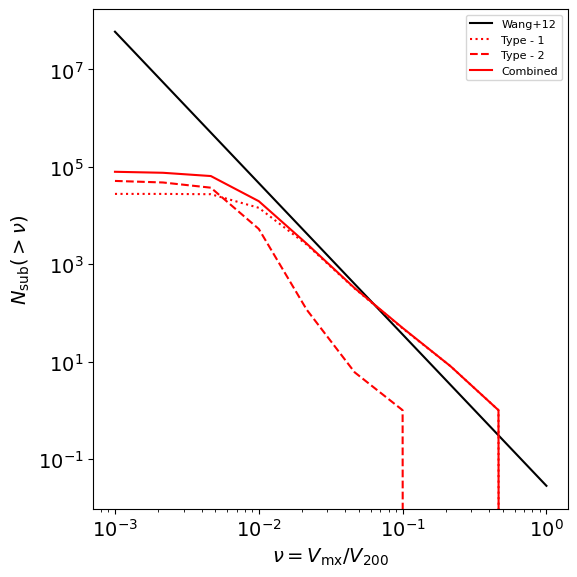

In [40]:
print('This is to make the Figure 3 from Wang et al 2012 -- The distribution of Vmx')
psvrel = psvmx_f_ar / v200
pmvrel = pmvmx_f_ar / v200
Ns_nu_ar = np.zeros(0)
Nm_nu_ar = np.zeros(0)
fig, ax = plt.subplots(figsize = (6, 6))
nu_pl = np.logspace(-3, 0, 10)
fofno = 0
for (ix, nu) in enumerate(nu_pl):
    Ns_nu_ar = np.append(Ns_nu_ar, len(psvmx_f_ar[(psvrel > nu) & (psfof == fofno) & (psdist_f_ar < r200)]))
    Nm_nu_ar = np.append(Nm_nu_ar, len(pmvmx_f_ar[(pmvrel > nu) & (pmfof == fofno) & (pmdist_f_ar < r200)]))
ax.plot(nu_pl, 10.2 * (nu_pl/0.15)**(-3.11), color = 'black', label = 'Wang+12')
ax.plot(nu_pl, Ns_nu_ar, color = 'red', ls = ':', label = 'Type - 1')
ax.plot(nu_pl, Nm_nu_ar, color = 'red', ls = '--', label = 'Type - 2')
ax.plot(nu_pl, Nm_nu_ar + Ns_nu_ar, color = 'red', ls = '-', label = 'Combined')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$N_{\rm{sub}} (> \nu)$')
ax.set_xlabel(r'$ \nu  = V_{\rm{mx}}/V_{\rm{200}} $')
ax.legend(fontsize = 8)
plt.tight_layout()
plt.show()

This is to make the Figure 12 from Gao et al 2021 -- The distribution of Vmx


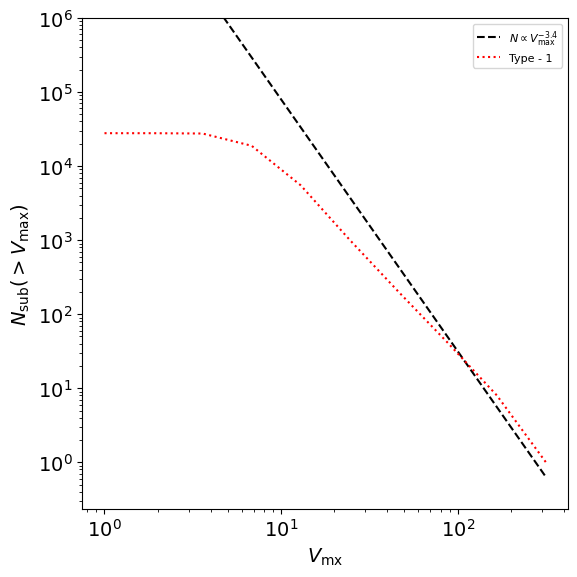

In [7]:
print('This is to make the Figure 12 from Gao et al 2021 -- The distribution of Vmx')
psvrel = psvmx_f_ar 
pmvrel = pmvmx_f_ar 
Ns_nu_ar = np.zeros(0)
Nm_nu_ar = np.zeros(0)
fig, ax = plt.subplots(figsize = (6, 6))
nu_pl = np.logspace(0, 2.5, 10)
fofno = 0
for (ix, nu) in enumerate(nu_pl):
    Ns_nu_ar = np.append(Ns_nu_ar, len(psvmx_f_ar[(psvrel > nu) & (psfof == fofno) & (psdist_f_ar < r200)]))
    Nm_nu_ar = np.append(Nm_nu_ar, len(pmvmx_f_ar[(pmvrel > nu) & (pmfof == fofno) & (pmdist_f_ar < r200)]))
ax.plot(nu_pl, 2e8 * nu_pl ** (-3.4), color = 'black', ls = '--', label = r'$N \propto V_{\rm{max}}^{-3.4}$')
ax.plot(nu_pl, Ns_nu_ar, color = 'red', ls = ':', label = 'Type - 1')
# ax.plot(nu_pl, Nm_nu_ar, color = 'red', ls = '--', label = 'Type - 2')
# ax.plot(nu_pl, Nm_nu_ar + Ns_nu_ar, color = 'red', ls = '-', label = 'Combined')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(top = 1e6)
ax.set_ylabel(r'$N_{\rm{sub}} (> V_{\rm{max}})$')
ax.set_xlabel(r'$ V_{\rm{mx}}$')
ax.legend(fontsize = 8)
plt.tight_layout()
plt.show()

This is to obtain the Mstar vs Vmx plot for z = 0


Text(0.5, 0, 'Vmx')

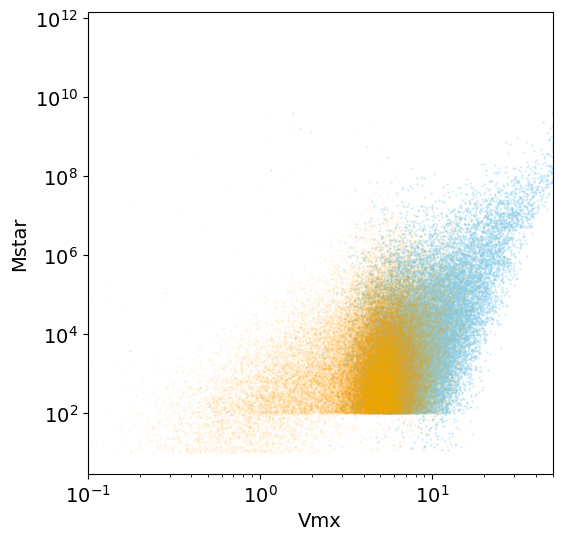

In [53]:
print('This is to obtain the Mstar vs Vmx plot for z = 0')
fig, ax = plt.subplots(figsize = (6, 6))
s = 0.2
alpha = 0.5
pscond = (psfof == fofno) & (psdist_f_ar < r200)
pmcond = (pmfof == fofno) & (pmdist_f_ar < r200)
ax.scatter(psvmx_f_ar[pscond], psmstar_all[pscond], s = s, color = 'skyblue', alpha = alpha, label = 'Type 1s')
ax.scatter(pmvmx_f_ar[pmcond], pmmstar_all[pmcond], s = s, color = 'orange', alpha = alpha/5, label = 'Type 2s')
ax.set_xlim(0.1, 50)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Mstar')
ax.set_xlabel('Vmx')
# print(np.sum(psvmx_f_ar == 0))

This is to make a version that resembles the Figure 16 from Gao12
This is normal


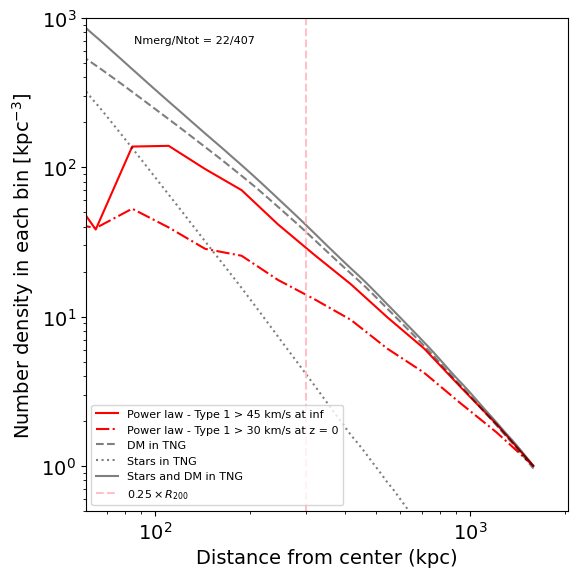

In [87]:
print('This is to make a version that resembles the Figure 16 from Gao12')

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)

central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200 = this_fof['Group_M_Crit200'] * 1e10 / h
r200 = this_fof['Group_R_Crit200'] / h
v200 = np.sqrt(G * m200 / r200)


# print('This is normal')
def plot_radial_density_dist_3panel(fofno = 0):
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 1, figsize = (6, 6))
    axs = [axs]
    if fofno == 0:
        Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
        Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]
    elif fofno == 1:
        # elif fofno == 1:
        Ndm_ar =  [786023, 841839, 902134, 966380, 1035837, 1110113, 1189602, 1274186, 1364366, 1460423, 1562817, 1672316, 1788483, 1913425, 2046885, 2190148, 2343775, 2511901, 2690528, 2878121, 3078467, 3294791, 3528395, 3780942, 4053436, 4350232, 4685298, 5050150, 5416132, 5796879, 6199598, 6623522, 7072307, 7546453, 8050591, 8585909, 9153650, 9756524, 10397233, 11074877, 11795747, 12560524, 13376455, 14255740, 15217979, 16289952, 17349673, 18430107, 19555220, 20756630, 22010268, 23314416, 24673283, 26107659, 27631468, 29312494, 31108073, 32886889, 34739969, 36734573, 38844189, 41049934, 43382025, 45812785, 48395953, 51173751, 54141628, 57270029, 60739449, 64360174, 68074798, 71803090, 75817335, 80041042, 84373691, 89111485, 94087743, 99601105, 104804935, 109994769, 115260983, 121202017, 127487242, 133053679, 138547841, 144456102, 151341815, 158789550, 164815392, 169912646, 174986366, 179518933, 183635753, 187442091, 191210434, 194512610, 197453028, 199783883, 201489573, 202770641]
        Mstar_ar = [735365200000.0, 752437950000.0, 769758000000.0, 786811060000.0, 803612500000.0, 819888000000.0, 835624570000.0, 850837800000.0, 865607700000.0, 879804150000.0, 893492400000.0, 906636800000.0, 919314960000.0, 931422670000.0, 942965800000.0, 953885000000.0, 964442060000.0, 978516050000.0, 990955000000.0, 999915700000.0, 1008391160000.0, 1016919560000.0, 1025774060000.0, 1036594640000.0, 1047105040000.0, 1059257000000.0, 1096440500000.0, 1151949900000.0, 1165945200000.0, 1177803400000.0, 1188600200000.0, 1198653700000.0, 1208132700000.0, 1217186100000.0, 1225809000000.0, 1234269200000.0, 1242689600000.0, 1251252200000.0, 1259951800000.0, 1268457100000.0, 1279594100000.0, 1288064300000.0, 1296732400000.0, 1306350800000.0, 1320749400000.0, 1368368600000.0, 1382908300000.0, 1394449200000.0, 1403701300000.0, 1421870400000.0, 1442400400000.0, 1459726700000.0, 1469102700000.0, 1477989500000.0, 1487951800000.0, 1513011500000.0, 1560199000000.0, 1570833800000.0, 1579861900000.0, 1589710300000.0, 1600094000000.0, 1609801100000.0, 1621373700000.0, 1629216000000.0, 1637721200000.0, 1656113300000.0, 1669808800000.0, 1678819000000.0, 1717836000000.0, 1776533500000.0, 1813434300000.0, 1823228400000.0, 1850019700000.0, 1866819000000.0, 1877642600000.0, 1930809000000.0, 1948741300000.0, 2024119300000.0, 2043187400000.0, 2065576000000.0, 2079388200000.0, 2136806900000.0, 2310955000000.0, 2327082700000.0, 2336245700000.0, 2360786300000.0, 2592580000000.0, 2962172000000.0, 3038592400000.0, 3052858500000.0, 3091299600000.0, 3104512700000.0, 3113781600000.0, 3118984300000.0, 3128386000000.0, 3134713000000.0, 3149529400000.0, 3163836000000.0, 3166528300000.0, 3167405700000.0]
    elif fofno == 2:
        Ndm_ar =  [506233, 543093, 582765, 625491, 671876, 722219, 777025, 836818, 901297, 970418, 1045227, 1126104, 1213949, 1309191, 1412584, 1524440, 1646551, 1777799, 1919728, 2072632, 2238248, 2417271, 2609800, 2817277, 3040510, 3281139, 3539926, 3817121, 4114546, 4432843, 4774753, 5139467, 5529198, 5945510, 6389364, 6861022, 7362273, 7896148, 8464347, 9073994, 9720932, 10401647, 11120919, 11885151, 12702569, 13567823, 14490623, 15490151, 16538923, 17659839, 18860064, 20139640, 21539654, 23004408, 24521251, 26118857, 27830425, 29690401, 31594495, 33583623, 35826373, 38084587, 40355477, 42603051, 44893225, 47240038, 49634641, 52131364, 54785123, 57566214, 60516069, 63630213, 66872280, 70032466, 73281595, 76559042, 79927775, 83271713, 86831349, 90335048, 93936908, 97529383, 101157411, 104732133, 108474590, 112510285, 116254382, 119352925, 122309945, 125330731, 128093855, 130971259, 133082588, 134592107, 135760830, 136423222, 136980286, 137712615, 138772681, 139954151]
        Mstar_ar = [622662400000.0, 639497900000.0, 656542900000.0, 673426200000.0, 690282760000.0, 707070850000.0, 723851700000.0, 741311400000.0, 758308100000.0, 774903000000.0, 791605700000.0, 808453400000.0, 825326700000.0, 842186600000.0, 858899000000.0, 875651200000.0, 892487200000.0, 909312900000.0, 925979840000.0, 942497300000.0, 959143700000.0, 975685350000.0, 992122900000.0, 1008428060000.0, 1024638000000.0, 1040602400000.0, 1056423740000.0, 1072317700000.0, 1088107640000.0, 1103894700000.0, 1119753900000.0, 1135668600000.0, 1151600600000.0, 1167671600000.0, 1184450500000.0, 1200219200000.0, 1215191000000.0, 1229984400000.0, 1244911900000.0, 1262749500000.0, 1279555500000.0, 1293580600000.0, 1306877000000.0, 1320081200000.0, 1332942500000.0, 1345256000000.0, 1357349500000.0, 1396579400000.0, 1409477200000.0, 1421382400000.0, 1434160100000.0, 1447370200000.0, 1486111800000.0, 1535126900000.0, 1546642500000.0, 1557432000000.0, 1571283800000.0, 1603248600000.0, 1616894800000.0, 1629796600000.0, 1693108300000.0, 1717380700000.0, 1780294600000.0, 1798316800000.0, 1806969000000.0, 1815239100000.0, 1824022600000.0, 1831566700000.0, 1840028700000.0, 1857419100000.0, 1873263900000.0, 1902653300000.0, 1939510400000.0, 1945850900000.0, 1952548900000.0, 1957783400000.0, 1971799000000.0, 1977263200000.0, 2014859800000.0, 2021033200000.0, 2033235000000.0, 2037815700000.0, 2059557500000.0, 2070316000000.0, 2093917300000.0, 2134067600000.0, 2198085600000.0, 2203074200000.0, 2214773400000.0, 2232973800000.0, 2254086000000.0, 2357980800000.0, 2370230600000.0, 2373513600000.0, 2384293500000.0, 2384670800000.0, 2385031500000.0, 2385912800000.0, 2392934600000.0, 2395122400000.0]


    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(1):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs2_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 0
            mmaxcutoff = 10**15
            # axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        # fofno = 1
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar > 45) & (pmdist_f_ar < rs) & (pmfof == fofno)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar > 45) & (pmgp_dist_f_ar < rs) & (pmfof == fofno)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_if_ar > 45) & (psfof == fofno)]))
            pNs2_ar = np.append(pNs2_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_f_ar > 30) & (psfof == fofno)]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff) & (psvmx_if_ar > 45)  & (psdist_f_ar < rs) & (psfof == fofno)]))

        
        axs[jx].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(pNm_ar[-1])) + '/' + str(int(pNs_ar[-1] + pNm_ar[-1])), transform=axs[jx].transAxes, fontsize = 8)
        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        # axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2, pNs_ar/pNs_ar[-1] *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 45 km/s at inf', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl2, pNs2_ar/pNs2_ar[-1] *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 30 km/s at z = 0', lw  = 1.5, ls = '-.')
        # axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        axs[jx].axvline(0.25 * r200, color = 'pink', ls = '--', label = r'$0.25 \times R_{\rm{200}}$')
        if jx == 0:
            axs[jx].legend(fontsize = 8, loc = 'lower left')
            axs[jx].set_ylabel(r'Number density in each bin $[\rm{kpc^{-3}}]$')
        axs[jx].set_xlabel('Distance from center (kpc)')
        axs[jx].set_ylim(bottom = 0.5, top = 1e3)
        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
        axs[jx].set_xlim(left = 0.05 * r200)
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel(0)



This is to make a version that is exactly equal to Fig. 16 from Gao12. This includes digitized data


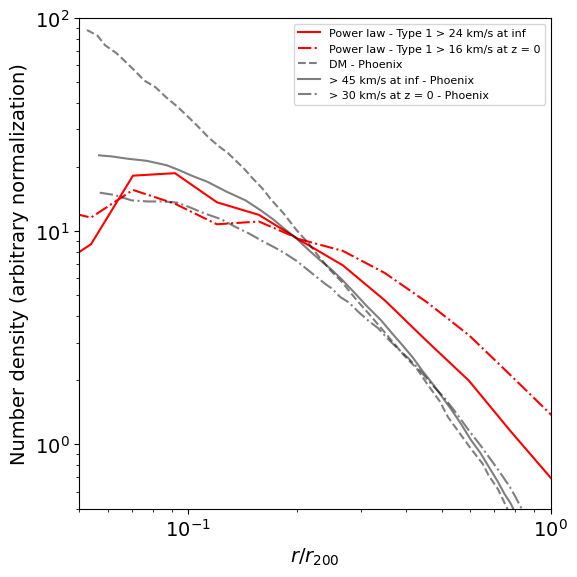

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 2.0000e+00 4.0000e+00 1.7000e+01 3.6000e+01 7.0000e+01 1.6200e+02
 3.1900e+02 6.8000e+02 1.3340e+03 2.4830e+03 4.3010e+03 7.1540e+03
 1.1442e+04 1.4613e+04]
1.0131669196297945


In [24]:
print('This is to make a version that is exactly equal to Fig. 16 from Gao12. This includes digitized data')
h = 0.6774
this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)

central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200 = this_fof['Group_M_Crit200'] * 1e10 / h
r200 = this_fof['Group_R_Crit200'] / h
v200 = np.sqrt(G * m200 / r200)

ph_dm_particles_df = pd.read_csv(misc_path + 'phoenix_dm_particles.csv', header = None)
ph_dm_particles_r = np.array(ph_dm_particles_df[0])
ph_dm_particles_n = np.array(ph_dm_particles_df[1])

ph_max_vmax_at_infall_df = pd.read_csv(misc_path + 'phoenix_max_vmax_at_infall.csv', header = None)
ph_max_vmax_at_infall_r = np.array(ph_max_vmax_at_infall_df[0])
ph_max_vmax_at_infall_n = np.array(ph_max_vmax_at_infall_df[1])

ph_max_vmax_z0_df = pd.read_csv(misc_path + 'phoenix_max_vmax_z0.csv', header = None)
ph_max_vmax_z0_r = np.array(ph_max_vmax_z0_df[0])
ph_max_vmax_z0_n = np.array(ph_max_vmax_z0_df[1])


# print(ph_dm_particles_r)


# print('This is normal')
def plot_radial_density_dist_3panel(fofno = 0):
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 1, figsize = (6, 6))
    axs = [axs]
    if fofno == 0:
        Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
        Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]
    elif fofno == 1:
        # elif fofno == 1:
        Ndm_ar =  [786023, 841839, 902134, 966380, 1035837, 1110113, 1189602, 1274186, 1364366, 1460423, 1562817, 1672316, 1788483, 1913425, 2046885, 2190148, 2343775, 2511901, 2690528, 2878121, 3078467, 3294791, 3528395, 3780942, 4053436, 4350232, 4685298, 5050150, 5416132, 5796879, 6199598, 6623522, 7072307, 7546453, 8050591, 8585909, 9153650, 9756524, 10397233, 11074877, 11795747, 12560524, 13376455, 14255740, 15217979, 16289952, 17349673, 18430107, 19555220, 20756630, 22010268, 23314416, 24673283, 26107659, 27631468, 29312494, 31108073, 32886889, 34739969, 36734573, 38844189, 41049934, 43382025, 45812785, 48395953, 51173751, 54141628, 57270029, 60739449, 64360174, 68074798, 71803090, 75817335, 80041042, 84373691, 89111485, 94087743, 99601105, 104804935, 109994769, 115260983, 121202017, 127487242, 133053679, 138547841, 144456102, 151341815, 158789550, 164815392, 169912646, 174986366, 179518933, 183635753, 187442091, 191210434, 194512610, 197453028, 199783883, 201489573, 202770641]
        Mstar_ar = [735365200000.0, 752437950000.0, 769758000000.0, 786811060000.0, 803612500000.0, 819888000000.0, 835624570000.0, 850837800000.0, 865607700000.0, 879804150000.0, 893492400000.0, 906636800000.0, 919314960000.0, 931422670000.0, 942965800000.0, 953885000000.0, 964442060000.0, 978516050000.0, 990955000000.0, 999915700000.0, 1008391160000.0, 1016919560000.0, 1025774060000.0, 1036594640000.0, 1047105040000.0, 1059257000000.0, 1096440500000.0, 1151949900000.0, 1165945200000.0, 1177803400000.0, 1188600200000.0, 1198653700000.0, 1208132700000.0, 1217186100000.0, 1225809000000.0, 1234269200000.0, 1242689600000.0, 1251252200000.0, 1259951800000.0, 1268457100000.0, 1279594100000.0, 1288064300000.0, 1296732400000.0, 1306350800000.0, 1320749400000.0, 1368368600000.0, 1382908300000.0, 1394449200000.0, 1403701300000.0, 1421870400000.0, 1442400400000.0, 1459726700000.0, 1469102700000.0, 1477989500000.0, 1487951800000.0, 1513011500000.0, 1560199000000.0, 1570833800000.0, 1579861900000.0, 1589710300000.0, 1600094000000.0, 1609801100000.0, 1621373700000.0, 1629216000000.0, 1637721200000.0, 1656113300000.0, 1669808800000.0, 1678819000000.0, 1717836000000.0, 1776533500000.0, 1813434300000.0, 1823228400000.0, 1850019700000.0, 1866819000000.0, 1877642600000.0, 1930809000000.0, 1948741300000.0, 2024119300000.0, 2043187400000.0, 2065576000000.0, 2079388200000.0, 2136806900000.0, 2310955000000.0, 2327082700000.0, 2336245700000.0, 2360786300000.0, 2592580000000.0, 2962172000000.0, 3038592400000.0, 3052858500000.0, 3091299600000.0, 3104512700000.0, 3113781600000.0, 3118984300000.0, 3128386000000.0, 3134713000000.0, 3149529400000.0, 3163836000000.0, 3166528300000.0, 3167405700000.0]
    elif fofno == 2:
        Ndm_ar =  [506233, 543093, 582765, 625491, 671876, 722219, 777025, 836818, 901297, 970418, 1045227, 1126104, 1213949, 1309191, 1412584, 1524440, 1646551, 1777799, 1919728, 2072632, 2238248, 2417271, 2609800, 2817277, 3040510, 3281139, 3539926, 3817121, 4114546, 4432843, 4774753, 5139467, 5529198, 5945510, 6389364, 6861022, 7362273, 7896148, 8464347, 9073994, 9720932, 10401647, 11120919, 11885151, 12702569, 13567823, 14490623, 15490151, 16538923, 17659839, 18860064, 20139640, 21539654, 23004408, 24521251, 26118857, 27830425, 29690401, 31594495, 33583623, 35826373, 38084587, 40355477, 42603051, 44893225, 47240038, 49634641, 52131364, 54785123, 57566214, 60516069, 63630213, 66872280, 70032466, 73281595, 76559042, 79927775, 83271713, 86831349, 90335048, 93936908, 97529383, 101157411, 104732133, 108474590, 112510285, 116254382, 119352925, 122309945, 125330731, 128093855, 130971259, 133082588, 134592107, 135760830, 136423222, 136980286, 137712615, 138772681, 139954151]
        Mstar_ar = [622662400000.0, 639497900000.0, 656542900000.0, 673426200000.0, 690282760000.0, 707070850000.0, 723851700000.0, 741311400000.0, 758308100000.0, 774903000000.0, 791605700000.0, 808453400000.0, 825326700000.0, 842186600000.0, 858899000000.0, 875651200000.0, 892487200000.0, 909312900000.0, 925979840000.0, 942497300000.0, 959143700000.0, 975685350000.0, 992122900000.0, 1008428060000.0, 1024638000000.0, 1040602400000.0, 1056423740000.0, 1072317700000.0, 1088107640000.0, 1103894700000.0, 1119753900000.0, 1135668600000.0, 1151600600000.0, 1167671600000.0, 1184450500000.0, 1200219200000.0, 1215191000000.0, 1229984400000.0, 1244911900000.0, 1262749500000.0, 1279555500000.0, 1293580600000.0, 1306877000000.0, 1320081200000.0, 1332942500000.0, 1345256000000.0, 1357349500000.0, 1396579400000.0, 1409477200000.0, 1421382400000.0, 1434160100000.0, 1447370200000.0, 1486111800000.0, 1535126900000.0, 1546642500000.0, 1557432000000.0, 1571283800000.0, 1603248600000.0, 1616894800000.0, 1629796600000.0, 1693108300000.0, 1717380700000.0, 1780294600000.0, 1798316800000.0, 1806969000000.0, 1815239100000.0, 1824022600000.0, 1831566700000.0, 1840028700000.0, 1857419100000.0, 1873263900000.0, 1902653300000.0, 1939510400000.0, 1945850900000.0, 1952548900000.0, 1957783400000.0, 1971799000000.0, 1977263200000.0, 2014859800000.0, 2021033200000.0, 2033235000000.0, 2037815700000.0, 2059557500000.0, 2070316000000.0, 2093917300000.0, 2134067600000.0, 2198085600000.0, 2203074200000.0, 2214773400000.0, 2232973800000.0, 2254086000000.0, 2357980800000.0, 2370230600000.0, 2373513600000.0, 2384293500000.0, 2384670800000.0, 2385031500000.0, 2385912800000.0, 2392934600000.0, 2395122400000.0]


    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(1):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs2_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs_all_ar = np.zeros(0)
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 0
            mmaxcutoff = 10**15
            # axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, 3.2, 20)
        # fofno = 1
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar/v200 > 45/1500) & (pmdist_f_ar < rs) & (pmfof == fofno)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar/v200 > 45/1500) & (pmgp_dist_f_ar < rs) & (pmfof == fofno)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_if_ar/v200 > 45/1500) & (psfof == fofno)]))
            pNs2_ar = np.append(pNs2_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_f_ar/v200 > 30/1500) & (psfof == fofno)]))
            pNs_all_ar = np.append(pNs_all_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) &  (psfof == fofno) & (psmdm_f_ar/(4.5e5) > 100) ]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff) & (psvmx_if_ar > 45)  & (psdist_f_ar < rs) & (psfof == fofno)]))

        
        # axs[jx].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(pNm_ar[-1])) + '/' + str(int(pNs_ar[-1] + pNm_ar[-1])), transform=axs[jx].transAxes, fontsize = 8)
        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        # axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2/r200, 5 * pNs_ar/pNs_all_ar[-2] *  (rpl2[-2]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 24 km/s at inf', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl2/r200, 5 * pNs2_ar/pNs_all_ar[-2] *  (rpl2[-2]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 16 km/s at z = 0', lw  = 1.5, ls = '-.')
        # axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)
        '''
        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        '''
        # axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        # axs[jx].axvline(0.25 * r200, color = 'pink', ls = '--', label = r'$0.25 \times R_{\rm{200}}$')
        axs[jx].plot(ph_dm_particles_r, ph_dm_particles_n, 'k--', label = 'DM - Phoenix', alpha = 0.5)
        axs[jx].plot(ph_max_vmax_at_infall_r, ph_max_vmax_at_infall_n, 'k-', label = '> 45 km/s at inf - Phoenix', alpha = 0.5)
        axs[jx].plot(ph_max_vmax_z0_r, ph_max_vmax_z0_n, 'k-.', label = '> 30 km/s at z = 0 - Phoenix', alpha = 0.5)

        
        if jx == 0:
            axs[jx].legend(fontsize = 8, loc = 'upper right')
            axs[jx].set_ylabel(r'Number density (arbitrary normalization)')
        axs[jx].set_xlabel(r'$r/r_{200}$')
        axs[jx].set_ylim(bottom = 0.5, top = 1e2)

        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
        axs[jx].set_xlim(left = 0.05, right = 1)
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
    print(pNs_all_ar)
    print(rpl2[-2]/r200)

    return

plot_radial_density_dist_3panel(0)



In [22]:
v200 * 30 / 1500

16.22969779526985

This is to make a version where we have all three FoFs and r_apo < 2e3 kpc


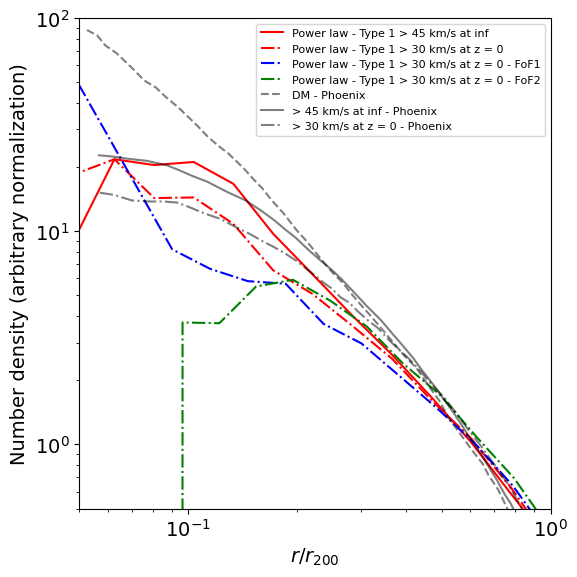

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 2.0000e+00 3.0000e+00 1.1000e+01 2.5000e+01 4.8000e+01 1.0000e+02
 1.9700e+02 3.8800e+02 7.9900e+02 1.4760e+03 2.6620e+03 4.4370e+03
 7.1730e+03 1.1245e+04]
0.7773269217538876


In [15]:
print('This is to make a version where we have all three FoFs and r_apo < 2e3 kpc')
h = 0.6774
this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)

central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200 = this_fof['Group_M_Crit200'] * 1e10 / h
r200 = this_fof['Group_R_Crit200'] / h
v200 = np.sqrt(G * m200 / r200)

ph_dm_particles_df = pd.read_csv(misc_path + 'phoenix_dm_particles.csv', header = None)
ph_dm_particles_r = np.array(ph_dm_particles_df[0])
ph_dm_particles_n = np.array(ph_dm_particles_df[1])

ph_max_vmax_at_infall_df = pd.read_csv(misc_path + 'phoenix_max_vmax_at_infall.csv', header = None)
ph_max_vmax_at_infall_r = np.array(ph_max_vmax_at_infall_df[0])
ph_max_vmax_at_infall_n = np.array(ph_max_vmax_at_infall_df[1])

ph_max_vmax_z0_df = pd.read_csv(misc_path + 'phoenix_max_vmax_z0.csv', header = None)
ph_max_vmax_z0_r = np.array(ph_max_vmax_z0_df[0])
ph_max_vmax_z0_n = np.array(ph_max_vmax_z0_df[1])


# print(ph_dm_particles_r)


# print('This is normal')
def plot_radial_density_dist_3panel(fofno = 0):
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(1, 1, figsize = (6, 6))
    axs = [axs]
    if fofno == 0:
        Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
        Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]
    elif fofno == 1:
        # elif fofno == 1:
        Ndm_ar =  [786023, 841839, 902134, 966380, 1035837, 1110113, 1189602, 1274186, 1364366, 1460423, 1562817, 1672316, 1788483, 1913425, 2046885, 2190148, 2343775, 2511901, 2690528, 2878121, 3078467, 3294791, 3528395, 3780942, 4053436, 4350232, 4685298, 5050150, 5416132, 5796879, 6199598, 6623522, 7072307, 7546453, 8050591, 8585909, 9153650, 9756524, 10397233, 11074877, 11795747, 12560524, 13376455, 14255740, 15217979, 16289952, 17349673, 18430107, 19555220, 20756630, 22010268, 23314416, 24673283, 26107659, 27631468, 29312494, 31108073, 32886889, 34739969, 36734573, 38844189, 41049934, 43382025, 45812785, 48395953, 51173751, 54141628, 57270029, 60739449, 64360174, 68074798, 71803090, 75817335, 80041042, 84373691, 89111485, 94087743, 99601105, 104804935, 109994769, 115260983, 121202017, 127487242, 133053679, 138547841, 144456102, 151341815, 158789550, 164815392, 169912646, 174986366, 179518933, 183635753, 187442091, 191210434, 194512610, 197453028, 199783883, 201489573, 202770641]
        Mstar_ar = [735365200000.0, 752437950000.0, 769758000000.0, 786811060000.0, 803612500000.0, 819888000000.0, 835624570000.0, 850837800000.0, 865607700000.0, 879804150000.0, 893492400000.0, 906636800000.0, 919314960000.0, 931422670000.0, 942965800000.0, 953885000000.0, 964442060000.0, 978516050000.0, 990955000000.0, 999915700000.0, 1008391160000.0, 1016919560000.0, 1025774060000.0, 1036594640000.0, 1047105040000.0, 1059257000000.0, 1096440500000.0, 1151949900000.0, 1165945200000.0, 1177803400000.0, 1188600200000.0, 1198653700000.0, 1208132700000.0, 1217186100000.0, 1225809000000.0, 1234269200000.0, 1242689600000.0, 1251252200000.0, 1259951800000.0, 1268457100000.0, 1279594100000.0, 1288064300000.0, 1296732400000.0, 1306350800000.0, 1320749400000.0, 1368368600000.0, 1382908300000.0, 1394449200000.0, 1403701300000.0, 1421870400000.0, 1442400400000.0, 1459726700000.0, 1469102700000.0, 1477989500000.0, 1487951800000.0, 1513011500000.0, 1560199000000.0, 1570833800000.0, 1579861900000.0, 1589710300000.0, 1600094000000.0, 1609801100000.0, 1621373700000.0, 1629216000000.0, 1637721200000.0, 1656113300000.0, 1669808800000.0, 1678819000000.0, 1717836000000.0, 1776533500000.0, 1813434300000.0, 1823228400000.0, 1850019700000.0, 1866819000000.0, 1877642600000.0, 1930809000000.0, 1948741300000.0, 2024119300000.0, 2043187400000.0, 2065576000000.0, 2079388200000.0, 2136806900000.0, 2310955000000.0, 2327082700000.0, 2336245700000.0, 2360786300000.0, 2592580000000.0, 2962172000000.0, 3038592400000.0, 3052858500000.0, 3091299600000.0, 3104512700000.0, 3113781600000.0, 3118984300000.0, 3128386000000.0, 3134713000000.0, 3149529400000.0, 3163836000000.0, 3166528300000.0, 3167405700000.0]
    elif fofno == 2:
        Ndm_ar =  [506233, 543093, 582765, 625491, 671876, 722219, 777025, 836818, 901297, 970418, 1045227, 1126104, 1213949, 1309191, 1412584, 1524440, 1646551, 1777799, 1919728, 2072632, 2238248, 2417271, 2609800, 2817277, 3040510, 3281139, 3539926, 3817121, 4114546, 4432843, 4774753, 5139467, 5529198, 5945510, 6389364, 6861022, 7362273, 7896148, 8464347, 9073994, 9720932, 10401647, 11120919, 11885151, 12702569, 13567823, 14490623, 15490151, 16538923, 17659839, 18860064, 20139640, 21539654, 23004408, 24521251, 26118857, 27830425, 29690401, 31594495, 33583623, 35826373, 38084587, 40355477, 42603051, 44893225, 47240038, 49634641, 52131364, 54785123, 57566214, 60516069, 63630213, 66872280, 70032466, 73281595, 76559042, 79927775, 83271713, 86831349, 90335048, 93936908, 97529383, 101157411, 104732133, 108474590, 112510285, 116254382, 119352925, 122309945, 125330731, 128093855, 130971259, 133082588, 134592107, 135760830, 136423222, 136980286, 137712615, 138772681, 139954151]
        Mstar_ar = [622662400000.0, 639497900000.0, 656542900000.0, 673426200000.0, 690282760000.0, 707070850000.0, 723851700000.0, 741311400000.0, 758308100000.0, 774903000000.0, 791605700000.0, 808453400000.0, 825326700000.0, 842186600000.0, 858899000000.0, 875651200000.0, 892487200000.0, 909312900000.0, 925979840000.0, 942497300000.0, 959143700000.0, 975685350000.0, 992122900000.0, 1008428060000.0, 1024638000000.0, 1040602400000.0, 1056423740000.0, 1072317700000.0, 1088107640000.0, 1103894700000.0, 1119753900000.0, 1135668600000.0, 1151600600000.0, 1167671600000.0, 1184450500000.0, 1200219200000.0, 1215191000000.0, 1229984400000.0, 1244911900000.0, 1262749500000.0, 1279555500000.0, 1293580600000.0, 1306877000000.0, 1320081200000.0, 1332942500000.0, 1345256000000.0, 1357349500000.0, 1396579400000.0, 1409477200000.0, 1421382400000.0, 1434160100000.0, 1447370200000.0, 1486111800000.0, 1535126900000.0, 1546642500000.0, 1557432000000.0, 1571283800000.0, 1603248600000.0, 1616894800000.0, 1629796600000.0, 1693108300000.0, 1717380700000.0, 1780294600000.0, 1798316800000.0, 1806969000000.0, 1815239100000.0, 1824022600000.0, 1831566700000.0, 1840028700000.0, 1857419100000.0, 1873263900000.0, 1902653300000.0, 1939510400000.0, 1945850900000.0, 1952548900000.0, 1957783400000.0, 1971799000000.0, 1977263200000.0, 2014859800000.0, 2021033200000.0, 2033235000000.0, 2037815700000.0, 2059557500000.0, 2070316000000.0, 2093917300000.0, 2134067600000.0, 2198085600000.0, 2203074200000.0, 2214773400000.0, 2232973800000.0, 2254086000000.0, 2357980800000.0, 2370230600000.0, 2373513600000.0, 2384293500000.0, 2384670800000.0, 2385031500000.0, 2385912800000.0, 2392934600000.0, 2395122400000.0]


    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    



    for jx in range(1):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs2_ar = np.zeros(0) #shmf for surviving subhalos 
        pNs_all_ar = np.zeros(0)
        
        pNs_ar1 = np.zeros(0) #shmf for surviving subhalos 
        pNs2_ar1 = np.zeros(0) #shmf for surviving subhalos 
        pNs_all_ar1 = np.zeros(0)

        
        pNs_ar2 = np.zeros(0) #shmf for surviving subhalos 
        pNs2_ar2 = np.zeros(0) #shmf for surviving subhalos 
        pNs_all_ar2 = np.zeros(0)
        
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              


        if jx == 0:
            mplcutoff = 0
            mmaxcutoff = 10**15
            # axs[jx].set_title(r'$M_{\star} > 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx == 1:
            mplcutoff = 10**5
            mmaxcutoff = 10**8.5
            axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{8.5}\,\rm{M_\odot}$', fontsize = label_font)
        elif jx ==2:
            mplcutoff = 0
            mmaxcutoff = 10**5
            axs[jx].set_title(r'$M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(1, np.log10(r200), 20)
        rpl21 = np.logspace(1, np.log10(r2001), 20)
        rpl22 = np.logspace(1, np.log10(r2002), 20)
        # fofno = 1
        for (ix, rs) in enumerate(rpl2): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar > 45) & (pmdist_f_ar < rs) & (pmfof == fofno)]))
            pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmvmx_if_ar > 45) & (pmgp_dist_f_ar < rs) & (pmfof == fofno)]))
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_if_ar > 45) & (psfof == fofno) & (psmdm_f_ar/(4.5e5) > 100)]))
            pNs2_ar = np.append(pNs2_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) & (psvmx_f_ar > 30) & (psfof == fofno) & (psmdm_f_ar/(4.5e5) > 100) & (psrapo_ar < r200) ]))
            pNs_all_ar = np.append(pNs_all_ar, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rs) &  (psfof == fofno) & (psmdm_f_ar/(4.5e5) > 100) ]))
            
            pNs_ar1 = np.append(pNs_ar1, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl21[ix]) & (psvmx_if_ar > 45) & (psfof == 1)& (psmdm_f_ar/(4.5e5) > 100)]))
            pNs2_ar1 = np.append(pNs2_ar1, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl21[ix]) & (psvmx_f_ar > 30) & (psfof == 1) & (psmdm_f_ar/(4.5e5) > 100)& (psrapo_ar < r2001)]))
            pNs_all_ar1 = np.append(pNs_all_ar1, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl21[ix]) &  (psfof == 1) & (psmdm_f_ar/(4.5e5) > 100) ]))
            
            pNs_ar2 = np.append(pNs_ar2, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl22[ix]) & (psvmx_if_ar > 45) & (psfof == 2)& (psmdm_f_ar/(4.5e5) > 100)]))
            pNs2_ar2 = np.append(pNs2_ar2, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl22[ix]) & (psvmx_f_ar > 30) & (psfof == 2)& (psmdm_f_ar/(4.5e5) > 100)& (psrapo_ar < r2002)]))
            pNs_all_ar2 = np.append(pNs_all_ar2, len(psmstar_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psdist_f_ar < rpl22[ix]) &  (psfof == 2) & (psmdm_f_ar/(4.5e5) > 100) ]))
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff) & (psvmx_if_ar > 45)  & (psdist_f_ar < rs) & (psfof == fofno)]))

        
        # axs[jx].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(pNm_ar[-1])) + '/' + str(int(pNs_ar[-1] + pNm_ar[-1])), transform=axs[jx].transAxes, fontsize = 8)
        
        Ntng_ar = Ntng_ar/Ntng_ar[-1] * (rpl2[-1]**3 / rpl2**3)
        pN_ar = (pNs_ar + pNm_ar) / (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        pN_ar_gp = (pNs_ar + pNm_ar_gp) / (pNs_ar[-1] + pNm_ar_gp[-1]) *  (rpl2[-1]**3 / rpl2**3)
        # cN_ar = (cNs_ar + cNm_ar) / (cNs_ar[-1] + cNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3)
        

        # axs[jx].plot(rpl2, Ntng_ar, 'bo-', label = r'TNG')
        # axs[jx].plot(rpl2, pN_ar, color = 'red', label = r'Power law', lw  = 1.5)
        axs[jx].plot(rpl2/r200,  12 * pNs_ar/pNs_all_ar[-1] *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 45 km/s at inf', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl2/r200,  12 * pNs2_ar/pNs_all_ar[-1] *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 30 km/s at z = 0', lw  = 1.5, ls = '-.')
        
        # axs[jx].plot(rpl21/r2001,  pNs_ar1/pNs_all_ar1[-2] *  (rpl2[-2]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 45 km/s at inf', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl21/r2001,  13 * pNs2_ar1/pNs_all_ar1[-1] *  (rpl21[-1]**3 / rpl21**3), color = 'blue', label = r'Power law - Type 1 > 30 km/s at z = 0 - FoF1', lw  = 1.5, ls = '-.')
        
        # axs[jx].plot(rpl22/r2002,  pNs_ar2/pNs_all_ar2[-2] *  (rpl2[-2]**3 / rpl2**3), color = 'red', label = r'Power law - Type 1 > 45 km/s at inf', lw  = 1.5, ls = '-')
        axs[jx].plot(rpl22/r2002,  13 * pNs2_ar2/pNs_all_ar2[-1] *  (rpl22[-1]**3 / rpl22**3), color = 'green', label = r'Power law - Type 1 > 30 km/s at z = 0 - FoF2', lw  = 1.5, ls = '-.')
        
        # axs[jx].plot(rpl2, pNm_ar/ (pNs_ar[-1] + pNm_ar[-1]) *  (rpl2[-1]**3 / rpl2**3), color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)
        '''
        axs[jx].plot(rpl, Ndm_ar, color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[jx].plot(rpl, Nstar_and_dm, color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        '''
        # axs[jx].plot(rpl, Mstar_ar, color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        # axs[jx].axvline(0.25 * r200, color = 'pink', ls = '--', label = r'$0.25 \times R_{\rm{200}}$')
        axs[jx].plot(ph_dm_particles_r, ph_dm_particles_n, 'k--', label = 'DM - Phoenix', alpha = 0.5)
        axs[jx].plot(ph_max_vmax_at_infall_r, ph_max_vmax_at_infall_n, 'k-', label = '> 45 km/s at inf - Phoenix', alpha = 0.5)
        axs[jx].plot(ph_max_vmax_z0_r, ph_max_vmax_z0_n, 'k-.', label = '> 30 km/s at z = 0 - Phoenix', alpha = 0.5)

        
        if jx == 0:
            axs[jx].legend(fontsize = 8, loc = 'upper right')
            axs[jx].set_ylabel(r'Number density (arbitrary normalization)')
        axs[jx].set_xlabel(r'$r/r_{200}$')
        axs[jx].set_ylim(bottom = 0.5, top = 1e2)

        
        axs[jx].set_xscale('log')
        axs[jx].set_yscale('log')
        axs[jx].set_xlim(left = 0.05, right = 1)
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
    print(pNs_all_ar)
    print(rpl2[-2]/r200)

    return

plot_radial_density_dist_3panel(0)



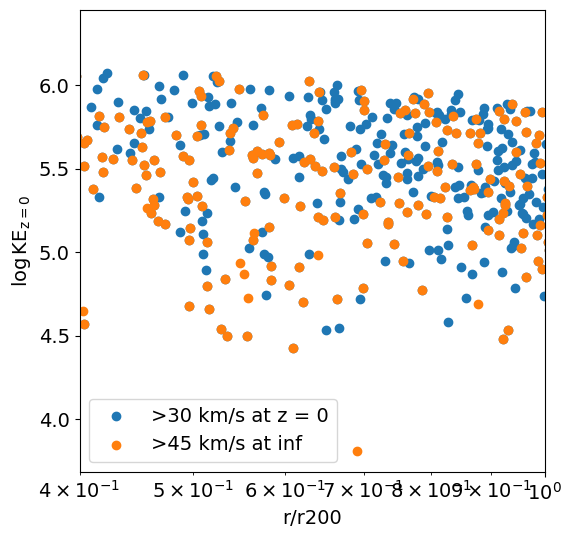

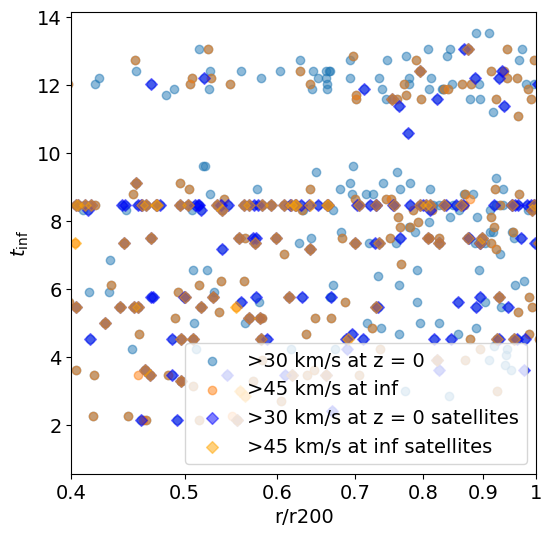

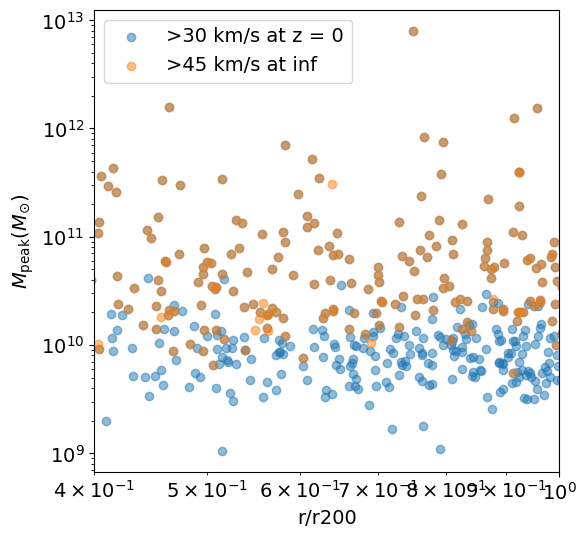

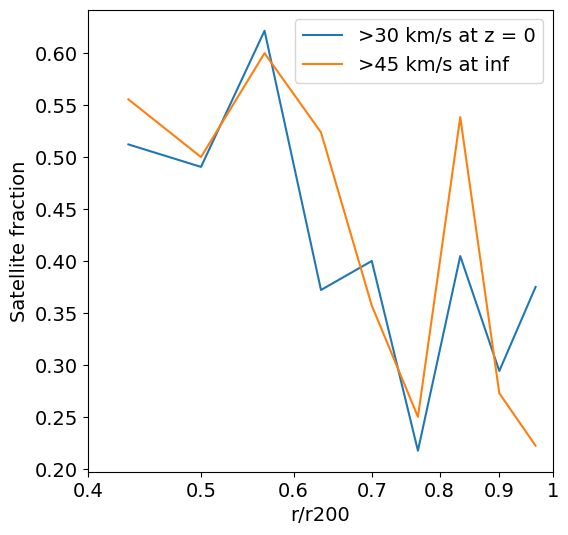

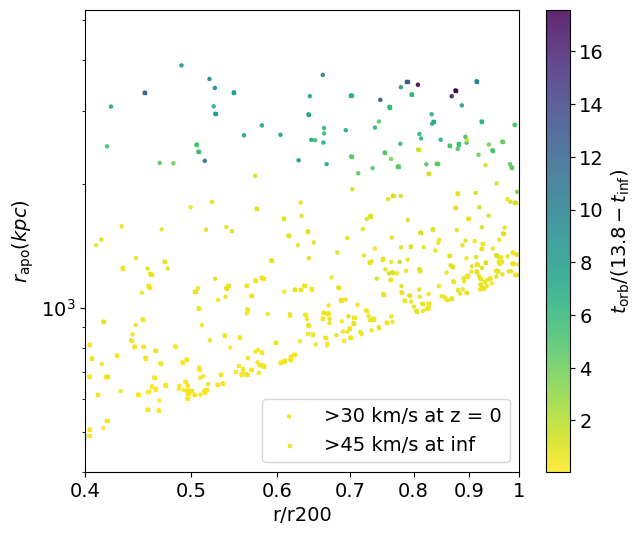

In [10]:
fig, (ax) = plt.subplots(figsize = (6, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 0)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 0)
ax.scatter(psdist_f_ar[pscond_fun]/r200, np.log10(pske_f_ar[pscond_fun]), label = '>30 km/s at z = 0')
ax.scatter(psdist_f_ar[pscond_comp]/r200, np.log10(pske_f_ar[pscond_comp]), label = '>45 km/s at inf')
ax.set_xlabel('r/r200')
ax.set_ylabel(r'$\log \rm{KE_{z = 0}}$')
ax.legend()
ax.set_xscale('log')
ax.set_xlim(left = 0.4, right = 1)
plt.show()
plt.close()

fig, (ax) = plt.subplots(figsize = (6, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 0)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 0)
ax.scatter(psdist_f_ar[pscond_fun]/r200, pstinf_ar[pscond_fun], label = '>30 km/s at z = 0', alpha = 0.5)
ax.scatter(psdist_f_ar[pscond_comp]/r200, pstinf_ar[pscond_comp], label = '>45 km/s at inf', alpha = 0.5)
ax.scatter(psdist_f_ar[pscond_fun & (psgr_sat == 1)]/r200, pstinf_ar[pscond_fun & (psgr_sat == 1)], label = '>30 km/s at z = 0 satellites', alpha = 0.5, marker = 'D', color = 'blue')
ax.scatter(psdist_f_ar[pscond_comp & (psgr_sat == 1)]/r200, pstinf_ar[pscond_comp & (psgr_sat == 1)], label = '>45 km/s at inf satellites', alpha = 0.5, marker = 'D', color = 'orange')
ax.set_xlabel('r/r200')
ax.set_ylabel(r'$t_{\rm{inf}}$')
ax.legend()
ax.set_xscale('log')
ax.set_xlim(left = 0.4, right = 1)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.show()
plt.close()

fig, (ax) = plt.subplots(figsize = (6, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 0)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 0)
ax.scatter(psdist_f_ar[pscond_fun]/r200, psmpeak_ar[pscond_fun], label = '>30 km/s at z = 0', alpha = 0.5)
ax.scatter(psdist_f_ar[pscond_comp]/r200, psmpeak_ar[pscond_comp], label = '>45 km/s at inf', alpha = 0.5)
ax.set_xlabel('r/r200')
ax.set_ylabel(r'$M_{\rm{peak}} (M_{\odot})$')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(left = 0.4, right = 1)
plt.show()
plt.close()

fig, (ax) = plt.subplots(figsize = (6, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 0)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 0)
rpl_bins = np.linspace(0.4, 1, 10)
sat_frac_fun = np.zeros(0)
sat_frac_comp = np.zeros(0)
rfrac_pl = np.zeros(0)
for ix in range(len(rpl_bins) - 1):
    rfrac_pl = np.append(rfrac_pl, (rpl_bins[ix + 1] + rpl_bins[ix])/2. )
    pscond_fun1 = pscond_fun & (psdist_f_ar/r200 > rpl_bins[ix]) & (psdist_f_ar/r200 < rpl_bins[ix + 1]) 
    pscond_comp1 = pscond_comp & (psdist_f_ar/r200 > rpl_bins[ix]) & (psdist_f_ar/r200 < rpl_bins[ix + 1]) 
    sat_frac_fun = np.append(sat_frac_fun, np.sum(psgr_sat[pscond_fun1])/len(psgr_sat[pscond_fun1]))
    sat_frac_comp = np.append(sat_frac_comp, np.sum(psgr_sat[pscond_comp1])/len(psgr_sat[pscond_comp1]))
# ax.scatter(psdist_f_ar[pscond_fun]/r200, psgr_sat[pscond_fun], label = '>30 km/s at z = 0', alpha = 0.2)
# ax.scatter(psdist_f_ar[pscond_comp]/r200, psgr_sat[pscond_comp], label = '>45 km/s at inf', alpha = 0.2)
ax.plot(rfrac_pl, sat_frac_fun, label = '>30 km/s at z = 0')
ax.plot(rfrac_pl, sat_frac_comp, label = '>45 km/s at inf')
ax.set_xlabel('r/r200')
ax.set_ylabel('Satellite fraction')
ax.legend()
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(left = 0.4, right = 1)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.show()
plt.close()



fig, (ax) = plt.subplots(figsize = (7, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 0)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 0)
s1 = plt.scatter(psdist_f_ar[pscond_fun]/r200, psrapo_ar[pscond_fun], label = '>30 km/s at z = 0', alpha = 0.85, s = 5, c = pstorb_ar[pscond_fun]/(13.8 - pstinf_ar[pscond_fun]),cmap='viridis_r')
s2 = plt.scatter(psdist_f_ar[pscond_comp]/r200, psrapo_ar[pscond_comp], label = '>45 km/s at inf', alpha = 0.85, s= 5, marker = 's', c = pstorb_ar[pscond_comp]/(13.8 - pstinf_ar[pscond_comp]),cmap='viridis_r')
cbar = fig.colorbar(s1)
cbar.set_label(r'$t_{\rm{orb}} / (13.8 - t_{\rm{inf}})$')
# plt.clim(0, 13.8)
# plt.colorbar().set_label(r't_{\rm{inf}}')
ax.set_xlabel('r/r200')
ax.set_ylabel(r'$r_{\rm{apo}} (kpc)$')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(left = 0.4, right = 1)
ax.set_ylim(bottom = 4e2)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.show()
plt.close()

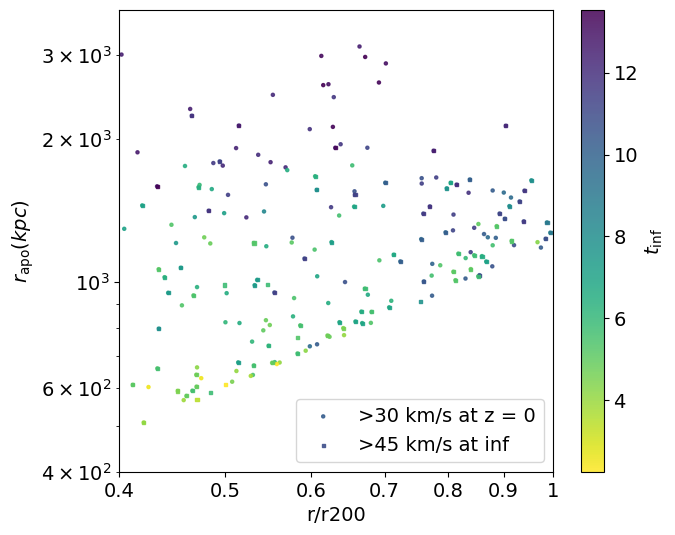

In [14]:
fig, (ax) = plt.subplots(figsize = (7, 6))
pscond_fun = (psvmx_f_ar > 30) & (psfof == 2)
pscond_comp = (psvmx_if_ar > 45) & (psfof == 2)
s1 = plt.scatter(psdist_f_ar[pscond_fun]/r200, psrapo_ar[pscond_fun], label = '>30 km/s at z = 0', alpha = 0.85, s = 5, c = pstinf_ar[pscond_fun],cmap='viridis_r')
s2 = plt.scatter(psdist_f_ar[pscond_comp]/r200, psrapo_ar[pscond_comp], label = '>45 km/s at inf', alpha = 0.85, s= 5, marker = 's', c = pstinf_ar[pscond_comp],cmap='viridis_r')
cbar = fig.colorbar(s1)
cbar.set_label(r'$t_{\rm{inf}}$')
# plt.clim(0, 13.8)
# plt.colorbar().set_label(r't_{\rm{inf}}')
ax.set_xlabel('r/r200')
ax.set_ylabel(r'$r_{\rm{apo}} (kpc)$')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(left = 0.4, right = 1)
ax.set_ylim(bottom = 4e2)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.show()
plt.close()

/bigdata/saleslab/psadh003/tng50/dwarf_formation/errani_plus_tng_subhalo.py:1446: RuntimeWarning: divide by zero encountered in log10
  ax_sub2.plot(np.flip(subh_ages), np.flip(np.log10(totMstar)), 'b--', label = r'Stars in total')



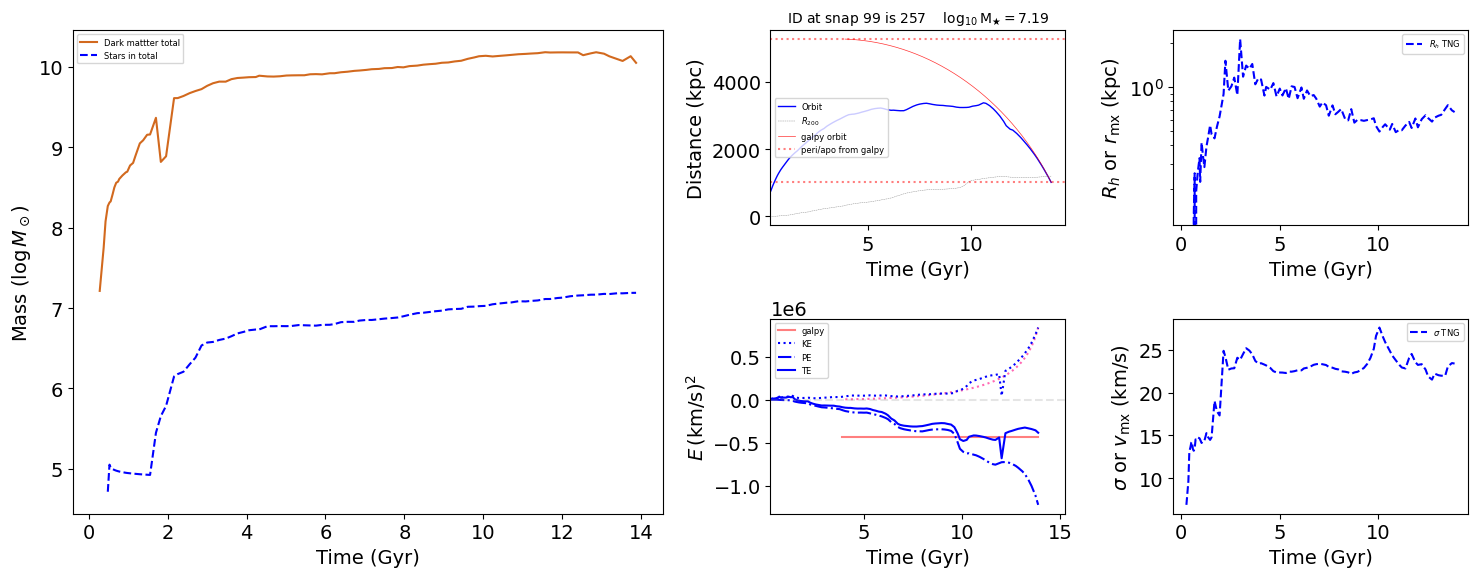

In [19]:
pscond_fun1 = (psvmx_f_ar > 30) & (psfof == 0) & (psrapo_ar > 2000) & (psdist_f_ar/r200 > 0.8) & (psdist_f_ar/r200 < 0.9)

ix = 5
sh = Subhalo(snap = pssnap_if_ar[pscond_fun1][ix], sfid = pssf_id_if_ar[pscond_fun1][ix], last_snap = 99, central_sfid_99 = 0)
sh.plot_orbit_comprehensive(show = True)

In [43]:
len(psfof[(psfof == 0) & (psmstar_max_ar > 10**8) & (psmstar_max_ar < 10**9.5)])

269

In [12]:



if True: #This is a section for getting cutoff values of survived subhalos
    cdfs = pd.read_csv(outpath + fof_str + '_surviving_evolved_everything.csv', delimiter = ',', low_memory=False)
    cdfs = cdfs.applymap(convert_to_float)


    # cdfs = cdfs[cdfs['dist_f_ar']<rvir_fof]
    # subset1 = cdfs[(cdfs['dist_f_ar']<rvir_fof0) & (cdfs['fof'] == 0)]
    # subset2 = cdfs[(cdfs['dist_f_ar']<rvir_fof1) & (cdfs['fof'] == 1)]
    # subset3 = cdfs[(cdfs['dist_f_ar']<rvir_fof2) & (cdfs['fof'] == 2)]

    # cdfs = pd.concat([subset1, subset2, subset3], axis=0)
    cdfs1 = cdfs

    # elif porc == 'c':
    columns_to_max = ['mstar_max_ar', 'mstar_max_co_ar']
    max_values = cdfs[columns_to_max].max(axis=1)
    cdfs = cdfs[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar_tng', 'mstar_f_co_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = cdfs[columns_to_max].max(axis=1)

    cutoff = 10
    # print(max_values > cutoff)

    cdfs = cdfs[(max_values > cutoff)]

    csdist_f_ar = cdfs['dist_f_ar'].values
    cspos_f_ar = np.stack(np.array(cdfs['pos_f_ar'].values))
    csvel_f_ar = np.stack(np.array(cdfs['vel_f_ar'].values))

    csxydist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, :2]), axis = 1))
    csyzdist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, 1:]), axis = 1))
    csxzdist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, [0, 2]]), axis = 1))

    csvd_f_ar_tng = cdfs['vd_f_ar_tng'].values
    csrh_f_ar_tng = cdfs['rh_f_ar_tng'].values
    csmstar_f_ar_tng = cdfs['mstar_f_ar_tng'].values
    csmmx_f_ar_tng = cdfs['mmx_f_ar_tng'].values
    csrmx_f_ar_tng = cdfs['rmx_f_ar_tng'].values
    csvmx_f_ar_tng = cdfs['vmx_f_ar_tng'].values

    cstinf_ar = cdfs['tinf_ar'].values
    cstorb_ar = cdfs['torb_ar'].values
    csrapo_ar = cdfs['rapo_ar'].values
    csrperi_ar = cdfs['rperi_ar'].values

    csvd_f_ar = cdfs['vd_f_ar'].values
    csrh_f_ar = cdfs['rh_f_ar'].values
    csmstar_f_ar = cdfs['mstar_f_ar'].values

    csvd_max_ar = cdfs['vd_max_ar'].values
    csrh_max_ar = cdfs['rh_max_ar'].values
    csmstar_max_ar = cdfs['mstar_max_ar'].values

    cssnap_if_ar = cdfs['snap_if_ar'].values
    cssf_id_if_ar = cdfs['sfid_if_ar'].values

    csmmx_f_ar = cdfs['mmx_f_ar'].values
    csrmx_f_ar = cdfs['rmx_f_ar'].values
    csvmx_f_ar = cdfs['vmx_f_ar'].values

    csmmx_if_ar = cdfs['mmx_if_ar'].values
    csrmx_if_ar = cdfs['rmx_if_ar'].values
    csvmx_if_ar = cdfs['vmx_if_ar'].values

    csvd_f_pl_ar = cdfs['vd_f_pl_ar'].values
    csrh_f_pl_ar = cdfs['rh_f_pl_ar'].values
    csmstar_f_pl_ar = cdfs['mstar_f_pl_ar'].values
    csvd_f_co_ar = cdfs['vd_f_co_ar'].values
    csrh_f_co_ar = cdfs['rh_f_co_ar'].values
    csmstar_f_co_ar = cdfs['mstar_f_co_ar'].values
    csrh_max_pl_ar = cdfs['rh_max_pl_ar'].values
    csrh_max_co_ar = cdfs['rh_max_co_ar'].values
    csmstar_max_pl_ar = cdfs['mstar_max_pl_ar'].values
    csmstar_max_co_ar = cdfs['mstar_max_co_ar'].values
    csfof = cdfs['fof'].values

    csmbp_pos_f_ar = cdfs['mbp_pos_f_ar'].values
    csmbp_vel_f_ar = cdfs['mbp_vel_f_ar'].values
    csmbp_dist_f_ar = cdfs['mbp_dist_f_ar'].values

    csmstar_all = np.zeros(len(csmmx_f_ar))
    csrh_all = np.zeros(len(csmmx_f_ar))
    csvd_all = np.zeros(len(csmmx_f_ar))
    res_ixs = np.where(csmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(csmstar_max_ar < 5e6)[0] #These are the unresolved indices

    csmstar_max_all = np.zeros(len(csmmx_f_ar))
    csrh_max_all = np.zeros(len(csmmx_f_ar))

    csmstar_max_all[res_ixs] = csmstar_max_ar[res_ixs]
    csmstar_max_all[unres_ixs] = csmstar_max_co_ar[unres_ixs]

    csrh_max_all[res_ixs] = csrh_max_ar[res_ixs]
    csrh_max_all[unres_ixs] = csrh_max_co_ar[unres_ixs]

    csmstar_all[res_ixs] = csmstar_f_ar[res_ixs]
    csmstar_all[unres_ixs] = csmstar_f_co_ar[unres_ixs]
    csrh_all[res_ixs] = csrh_f_ar[res_ixs]
    csrh_all[unres_ixs] = csrh_f_co_ar[unres_ixs]
    csvd_all[res_ixs] = csvd_f_ar[res_ixs]
    csvd_all[unres_ixs] = csvd_f_co_ar[unres_ixs]

    cssigma_all = 4.83 +21.57 -2.5 * np.log10(csmstar_all / (np.pi * (csrh_all*1e3) ** 2)) #This will be in mag/arcsec^2


if True: #This is a section for getting cutoff values of merged subhalos
    cdfm = pd.read_csv(outpath + fof_str + '_merged_evolved_wmbp_everything.csv', delimiter = ',')
    cdfm = cdfm.dropna(subset = ['dist_f_ar'])
    cdfm = cdfm.applymap(convert_to_float)


    # cdfm = cdfm[cdfm['dist_f_ar']<rvir_fof]
    
    # subset1 = cdfm[(cdfm['dist_f_ar']<rvir_fof0) & (cdfm['fof'] == 0)]
    # subset2 = cdfm[(cdfm['dist_f_ar']<rvir_fof1) & (cdfm['fof'] == 1)]
    # subset3 = cdfm[(cdfm['dist_f_ar']<rvir_fof2) & (cdfm['fof'] == 2)]

    # cdfm = pd.concat([subset1, subset2, subset3], axis=0)

    cdfm1 = cdfm 

    columns_to_max = ['mstar_max_ar', 'mstar_max_co_ar']
    max_values = cdfm[columns_to_max].max(axis=1)
    cdfm = cdfm[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar', 'mstar_f_co_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = cdfm[columns_to_max].max(axis=1)

    # Sample cutoff value
    cutoff = 10
    cdfm = cdfm[max_values > cutoff]
    # print(len(cdfm))
    cmdist_f_ar = cdfm['dist_f_ar'].values
    cmpos_ar = np.stack(np.array(cdfm['pos_f_ar'].values))
    cmvel_f_ar = np.stack(np.array(cdfm['vel_f_ar'].values))


    cmxydist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, :2]), axis = 1))
    cmyzdist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, 1:]), axis = 1))
    cmxzdist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, [0, 2]]), axis = 1))


    cmmbpid_ar = cdfm['mbpid_ar'].values

    cmtinf_ar = cdfm['tinf_ar'].values
    cmtorb_ar = cdfm['torb_ar'].values
    cmrapo_ar = cdfm['rapo_ar'].values
    cmrperi_ar = cdfm['rperi_ar'].values

    cmvd_f_ar = cdfm['vd_f_ar'].values
    cmrh_f_ar = cdfm['rh_f_ar'].values
    cmmstar_f_ar = cdfm['mstar_f_ar'].values

    cmvd_max_ar = cdfm['vd_max_ar'].values
    cmrh_max_ar = cdfm['rh_max_ar'].values
    cmmstar_max_ar = cdfm['mstar_max_ar'].values

    cmsnap_if_ar = cdfm['snap_if_ar'].values
    cmsfid_if_ar = cdfm['sfid_if_ar'].values

    cmmmx_f_ar = cdfm['mmx_f_ar'].values
    cmrmx_f_ar = cdfm['rmx_f_ar'].values
    cmvmx_f_ar = cdfm['vmx_f_ar'].values

    cmmmx_if_ar = cdfm['mmx_if_ar'].values
    cmrmx_if_ar = cdfm['rmx_if_ar'].values
    cmvmx_if_ar = cdfm['vmx_if_ar'].values

    cmvd_f_pl_ar = cdfm['vd_f_pl_ar'].values
    cmrh_f_pl_ar = cdfm['rh_f_pl_ar'].values
    cmmstar_f_pl_ar = cdfm['mstar_f_pl_ar'].values
    cmvd_f_co_ar = cdfm['vd_f_co_ar'].values
    cmrh_f_co_ar = cdfm['rh_f_co_ar'].values
    cmmstar_f_co_ar = cdfm['mstar_f_co_ar'].values
    cmrh_max_pl_ar = cdfm['rh_max_pl_ar'].values
    cmrh_max_co_ar = cdfm['rh_max_co_ar'].values
    cmmstar_max_pl_ar = cdfm['mstar_max_pl_ar'].values
    cmmstar_max_co_ar = cdfm['mstar_max_co_ar'].values
    cmfof = cdfm['fof'].values

    cmmstar_max_all = np.zeros(len(cmmmx_f_ar))
    cmrh_max_all = np.zeros(len(cmmmx_f_ar))

    cmmstar_all = np.zeros(len(cmmmx_f_ar))
    cmrh_all = np.zeros(len(cmmmx_f_ar))
    cmvd_all = np.zeros(len(cmmmx_f_ar))
    res_ixs = np.where(cmmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(cmmstar_max_ar < 5e6)[0] #These are the unresolved indices
    cmmstar_all[res_ixs] = cmmstar_f_ar[res_ixs]
    cmmstar_all[unres_ixs] = cmmstar_f_co_ar[unres_ixs]

    cmmstar_max_all[res_ixs] = cmmstar_max_ar[res_ixs]
    cmmstar_max_all[unres_ixs] = cmmstar_max_co_ar[unres_ixs]

    cmrh_max_all[res_ixs] = cmrh_max_ar[res_ixs]
    cmrh_max_all[unres_ixs] = cmrh_max_co_ar[unres_ixs]

    cmrh_all[res_ixs] = cmrh_f_ar[res_ixs]
    cmrh_all[unres_ixs] = cmrh_f_co_ar[unres_ixs]
    cmvd_all[res_ixs] = cmvd_f_ar[res_ixs]
    cmvd_all[unres_ixs] = cmvd_f_co_ar[unres_ixs]

    
    cmsigma_all = 4.83 +21.57 -2.5 * np.log10(cmmstar_all / (np.pi * (cmrh_all*1e3) ** 2)) #This will be in mag/arcsec^2


[50.24111607, 86.7979754, -297.79104684]
